## **Data Gathering**

In [1]:
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup

In [2]:
#load the HTML content from a local file
with open('smartprix.html', 'r', encoding='utf-8') as file:
    html_content = file.read()

In [ ]:
#parse the HTML content using BeautifulSoup
soup = BeautifulSoup(html_content, "html.parser")
#find all product containers
print(soup.prettify())


In [4]:
#extract data from each product container
continours = soup.find_all('div', {"class":'sm-product has-tag has-features has-actions'})
#lists to store extracted data
mobile_name = []
mobile_price = []
rank =[]
sim = []
processor = []
ram = []
battery = []
display = []
camera = []
card = []
os = []

#loop through each product container and extract data
for continour in continours:

    '''extract mobile name, price, rank, and specifications, handling missing data with try-except blocks by appending np.nan'''
    try:
        mobile_name.append(continour.find('h2').text)
    except:
        mobile_name.append(np.nan)
    try:
        mobile_price.append(continour.find('span',{"class": "price"}).text)
    except:
        mobile_price.append(np.nan)
    try:
        rank.append(continour.find('div', {'class':'score rank-1-bg' }).find('b').text)
    except:
        rank.append(np.nan)

#extract specifications
    x = continour.find("ul", {"class": "sm-feat specs"}).find_all('li')
    try:
        sim.append(x[0].text)
    except:
        sim.append(np.nan)
    try:
        processor.append(x[1].text)
    except:
        processor.append(np.nan)
    try:
        ram.append(x[2].text)
    except:
        ram.append(np.nan)
    try:
        battery.append(x[3].text)
    except:
        battery.append(np.nan)
    try:
        display.append(x[4].text)
    except:
        display.append(np.nan)
    try:
        camera.append(x[5].text)
    except:
        camera.append(np.nan)
    try:
        card.append(x[6].text)
    except:
        card.append(np.nan)
    try:
        os.append(x[7].text)
    except:
        os.append(np.nan)


In [5]:
os

['Android v14',
 'Android v15',
 'iOS v17',
 'Android v15',
 'Android v15',
 'No FM Radio',
 'Android v15',
 'No FM Radio',
 'Android v15',
 'Android v14',
 'Android v15',
 'No FM Radio',
 'No FM Radio',
 'Android v15',
 'Android v15',
 'No FM Radio',
 'Android v14',
 'No FM Radio',
 'Android v15',
 'Android v15',
 'No FM Radio',
 'Android v14',
 'No FM Radio',
 'No FM Radio',
 'No FM Radio',
 'iOS v18',
 'No FM Radio',
 'Android v15',
 'Android v14',
 'No FM Radio',
 'Android v15',
 'Android v15',
 'Android v15',
 'Android v14',
 'Android v14',
 'Android v15',
 'iOS v26',
 'Android v15',
 'Android v15',
 'No FM Radio',
 'Android v15',
 'Android v15',
 'No FM Radio',
 'No FM Radio',
 'Android v15',
 'Android v14',
 'Android v14',
 'Android v15',
 'No FM Radio',
 'No FM Radio',
 'Android v14',
 'Android v15',
 'No FM Radio',
 'Android v15',
 'No FM Radio',
 'No FM Radio',
 'Android v15',
 'No FM Radio',
 'Android v15',
 'Android v16',
 'No FM Radio',
 'Android v15',
 'Android v15',
 'An

In [6]:
#Create a DataFrame from the extracted data
df  = pd.DataFrame({
    "mobile_name" : mobile_name,
    "mobile_price" : mobile_price,
    "mobile_rank" : rank,
    "sim" : sim,
    "processor" : processor,
    "ram" : ram,
    "battery" : battery,
    "display" : display,
    "camera" : camera,
    "card" : card,
    "os" : os
})

#save as spreadsheet for manual data assessing
df.to_excel('smartpix_mobile_data.xlsx', index=False)

df.shape


(1014, 11)

In [7]:
df.head()

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
0,Samsung Galaxy S24 Ultra,"₹79,999",92,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"6.8 inches, 1440 x 3120 px, 120 Hz Display wit...",200 MP Quad Rear & 12 MP Front Camera,Memory Card Not Supported,Android v14
1,OnePlus Nord CE 5 5G,"₹23,999",83,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v15
2,Apple iPhone 15,"₹49,999",81,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A16, Hexa Core, 3.46 GHz Processor","6 GB RAM, 128 GB inbuilt",3349 mAh Battery with Fast Charging,"6.1 inches, 1179 x 2556 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v17
3,Vivo V60e,"₹29,999",85,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 7360 Turbo, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",200 MP + 8 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported,Android v15
4,Realme P3 Ultra (8GB RAM + 256GB),"₹19,999",81,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Ultra, Octa Core, 3.35 GHz Proc...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v15


## **Data cleaning**

### **Data Assessing**
#### **Quality Issues**
1. model - some brands are written diiferently like OPPO in model column "consistency"
2. price - has unneccesary "validity"
3. price has - , between numbers "validity"
4. ratings - missing values "completeness"
5. processor - has some incorrect values "validity"
6. memory - incorrect values "validity"
7. battery - incorrect values "validity"
8. display - incorrect values "validity"
10. camera - problem "validity"
11. card - sometimes contains info about os or camera "validity"
12. os - sometimes contains info about bluetooth and fm radio   "completeness"
13. os - issue with rows "validity"
14.  missing values in mobile_rank(444), camera(2), card(9) and os(20) "completeness"
15. have 8 duplicate rows in the dataset "consistency"

#### **Tidiness Issues**

1. sim - can be split into 3 cols has_5g, has_NFC, has_IR_Blaster
2. ram - can be split into 2 cols RAM and ROM
3. processor - can be split into processor name, cores and cpu speed.
4. battery - can be split into battery capacity, fast_charging_available
5. display - can be split into size, resolution_width, resolution_height and frequency
6. camera - can be split into front and rear camera
7. card - can be split into supported, extended_upto

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   mobile_name   1014 non-null   object
 1   mobile_price  1014 non-null   object
 2   mobile_rank   570 non-null    object
 3   sim           1014 non-null   object
 4   processor     1014 non-null   object
 5   ram           1014 non-null   object
 6   battery       1014 non-null   object
 7   display       1014 non-null   object
 8   camera        1012 non-null   object
 9   card          1005 non-null   object
 10  os            994 non-null    object
dtypes: object(11)
memory usage: 87.3+ KB


In [9]:
df.isnull().sum()

mobile_name       0
mobile_price      0
mobile_rank     444
sim               0
processor         0
ram               0
battery           0
display           0
camera            2
card              9
os               20
dtype: int64

Based on above output we find that we have missing values in mobile_rank(444), camera(2), card(9) and os(20)
also price and rating data type is incorrect

In [10]:
#detect the duplicates from the dataset
print(df.duplicated().sum())
df[df.duplicated()] 

8


,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
497,Realme 14T 5G,"₹15,999",80,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 6300, Octa Core, 2.4 GHz Processor","8 GB RAM, 128 GB inbuilt",6000 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,"Memory Card (Hybrid), upto 2 TB",Android v15
498,Samsung Galaxy A16 5G (6GB RAM + 128GB),"₹14,078",NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 6300, Octa Core, 2.4 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2340 px, 90 Hz Display with...",50 MP + 5 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card (Hybrid), upto 1.5 TB",Android v14
537,Nothing Phone 2a Plus (12GB RAM + 256GB),"₹23,999",85,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 7350 Pro 5G, Octa Core, 3 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 50W Fast Charging,"6.7 inches, 1084 x 2412 px, 120 Hz Display wit...",50 MP + 50 MP Dual Rear & 50 MP Front Camera,Android v14,No FM Radio
677,Motorola Moto G84 5G,"₹18,999",83,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 695, Octa Core, 2.2 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 30W Fast Charging,"6.55 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Memory Card (Hybrid),Android v13
715,Alcatel V3 Ultra (8GB RAM + 128GB),"₹16,999",85,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 6300, Octa Core, 2.4 GHz Processor","8 GB RAM, 128 GB inbuilt",5010 mAh Battery with 33W Fast Charging,"6.78 inches, 1080 x 2460 px, 120 Hz Display wi...",108 MP + 8 MP + 2 MP Triple Rear & 32 MP Front...,"Memory Card Supported, upto 2 TB",Android v14
716,Alcatel V3 Pro,"₹13,999",80,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 6300, Octa Core, 2.4 GHz Processor","8 GB RAM, 256 GB inbuilt",5200 mAh Battery with 18W Fast Charging,"6.67 inches, 720 x 1600 px, 120 Hz Display wit...",50 MP + 5 MP Dual Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 2 TB",Android v15
935,Samsung Galaxy Z Fold 5 (12GB RAM + 512GB),"₹96,689",91,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen 2, Octa Core, 3.36 GHz Processor","12 GB RAM, 512 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"7.6 inches, 1812 x 2176 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 ...,Android v13
994,OPPO F19s,"₹16,999",NaN,"Dual Sim, 3G, 4G, VoLTE, Wi-Fi","Snapdragon 662 , Octa Core, 2 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 33W Fast Charging,"6.43 inches, 1080 x 2400 px Display with Punch...",48 MP + 2 MP + 2 MP Triple Rear & 16 MP Front ...,"Memory Card Supported, upto 256 GB",Android v11


we have 8 duplicate rows in the dataset

In [11]:
df1 = df.copy()

## **start with validity issue**

In [12]:
df1['mobile_price'] = df1["mobile_price"].str.replace('₹','').str.replace(',','').astype(int)
df1['mobile_rank'] = df1['mobile_rank'].astype("float")

In [13]:
df1[df1['mobile_price'] < 3400]['mobile_name']

367             Jio Bharat J1 4G
405           Motorola Moto A300
433      Nokia 105 Dual Sim 2023
456            HMD 105 4G (2024)
483       itel Super Guru 4G Max
500             Jio Bharat V4 4G
502      Jio JioPhone Prima 2 4G
525                  iKall I7 4G
530               Lava Action 4G
572                  iKall I4 4G
577           Motorola Moto A200
586            HMD 110 4G (2024)
633               Foneme F24 Pro
634         HMD 150 Music (2025)
652          Nokia 220 4G (2024)
671       Nokia 105 Classic 2023
720                    MTR Power
726                   Amaq Q1 4G
741                Jio Bharat B2
760           Micromax X1i Smart
771              Snexian Bold 4G
775         Nokia 130 Music 2023
779        Jio Bharat K1 Karbonn
781                Jio Bharat V2
784                 Nokia 106 4G
814            Motorola Moto A70
833               Philips E2101C
835                Karbonn K103i
836                Peace Pura 20
837       Snexian Rock Power Pro
838       

In [14]:
# filter the dataframe  by analysing the data manually below mobile price 3400  then is no any smartphone available with valid entries
df1[df1['mobile_price'] < 3400]
# hence we can remove all the rows below 3400 as they are invalid entries for smartphone analysis
df1 = df1[df1['mobile_price'] >= 3400].reset_index(drop=True)
df1.shape

(964, 11)

In [15]:
#filter the procesor column to extract the wrong data entries which were not having the word 'Processor' in the string and also Unisoc and Tensor processors which are valid processors 
wrong_enitity_processor = df1[~df1['processor'].str.contains('Processor', na=False) & ~df1['processor'].str.contains('Unisoc', na=False) & ~df1['processor'].str.contains('Tensor', na=False)]
wrong_enitity_processor

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [16]:
# filter the wrong entries from ram column using 'RAM' and 'GB' as a filter
wrong_enitity_ram = df1[~df1['ram'].str.contains('GB', na=False) & ~df1['ram'].str.contains('RAM', na=False)]
wrong_enitity_ram

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [17]:
# filter the wrong entries from battery column using ''battery' as a filter
wrong_enitity_battery = df1[~df1['battery'].str.contains('Battery', na=False)]
wrong_enitity_battery

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
690,Apple iPhone 12 (128GB),54900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","4 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v14,No FM Radio
802,Apple iPhone 12 Pro,109900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0,No FM Radio
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [18]:
#filtering display column for wrong entries using 'Display' as a filter
wrong_enitity_display = df1[~df1['display'].str.contains('Display', na=False)]
wrong_enitity_display

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
690,Apple iPhone 12 (128GB),54900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","4 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v14,No FM Radio
802,Apple iPhone 12 Pro,109900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0,No FM Radio
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [19]:
# filter the camera column for wrong entries using 'Camera' as a filter
wrong_enitity_camera = df1[~df1['camera'].str.contains('Camera', na=False)]
wrong_enitity_camera

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
165,Samsung Galaxy Z Fold 7 (16GB RAM + 1TB),216999,97.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","16 GB RAM, 1 TB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
249,Samsung Galaxy Z Fold 7,174999,95.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
260,Motorola Razr 60 5G,44999,89.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 7400X, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",4500 mAh Battery with 30W Fast Charging,"6.9 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 13 MP Dual Rear & 32 MP Front Camera,Memory Card Not Supported
372,Lava Agni 3 5G,16999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi","Dimensity 7300X, Octa Core, 2.5 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 66W Fast Charging,"6.78 inches, 1200 x 2652 px, 120 Hz Display wi...",Dual Display,50 MP + 8 MP + 8 MP Triple Rear & 16 MP Front ...,Memory Card Not Supported
376,Samsung Galaxy Z Flip 4 (8GB RAM + 256GB),41370,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8+ Gen1, Octa Core, 3.2 GHz Processor","8 GB RAM, 256 GB inbuilt",3700 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",12 MP + 12 MP Dual Rear & 10 MP Front Camera,Memory Card Not Supported
379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
396,Vivo X Fold 3 Pro,159999,96.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","16 GB RAM, 512 GB inbuilt",5700 mAh Battery with 100W Fast Charging,"8.03 inches, 2200 x 2480 px, 120 Hz Display wi...","Foldable Display, Dual Display",64 MP + 50 MP + 50 MP Triple Rear & 32 MP + 32...,Memory Card Not Supported
397,Samsung Galaxy Z Fold 6,109999,90.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen 3, Octa Core, 3.39 GHz Processor","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"7.6 inches, 1856 x 2160 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 ...,Android v14
416,Motorola Razr 60 Ultra,79999,93.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8 Elite, Octa Core, 4.32 GHz Processor","16 GB RAM, 512 GB inbuilt",4700 mAh Battery with 68W Fast Charging,"6.96 inches, 1224 x 2992 px, 165 Hz Display wi...","Foldable Display, Dual Display",50 MP + 50 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported


In [20]:
# filter the memory card column for wrong entries using 'Memory' as a filter
wrong_enitity_card = df1[~df1['card'].str.contains('Memory', na=False)]
wrong_enitity_card

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
5,OPPO Reno 13 5G,23999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 8350, Octa Core, 3.35 GHz Processor","8 GB RAM, 128 GB inbuilt",5600 mAh Battery with 80W Fast Charging,"6.59 inches, 1256 x 2760 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 50 MP Front ...,Android v15,No FM Radio
7,Samsung Galaxy S24 5G (Snapdragon),41900,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","8 GB RAM, 256 GB inbuilt",4000 mAh Battery with 25W Fast Charging,"6.2 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 10 MP Triple Rear & 12 MP Fron...,Android v15,No FM Radio
11,Vivo T4 Pro 5G,27499,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, IR B...","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Android v15,No FM Radio
12,Motorola Edge 60 Pro,27475,80.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Dimensity 8350 Extreme, Octa Core, 3.35 GHz Pr...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 90W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 50 MP + 10 MP Triple Rear & 50 MP Fron...,Android v15,No FM Radio
15,Poco X7 5G,14999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC,...","Dimensity 7300 Ultra, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",5500 mAh Battery with 45W Fast Charging,"6.67 inches, 1220 x 2712 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android v14,No FM Radio
...,...,...,...,...,...,...,...,...,...,...,...
953,Xiaomi Mi 11X 5G (8GB RAM + 128GB),18999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 870, Octa Core, 3.2 GHz Processor","8 GB RAM, 128 GB inbuilt",4520 mAh Battery with 33W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",48 MP + 8 MP + 5 MP Triple Rear & 20 MP Front ...,Android v11,No FM Radio
955,Microsoft Surface Duo 2,79990,85.0,"Single Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 888 , Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",4449 mAh Battery with 23W Fast Charging,"8.3 inches, 1892 x 2688 px, 90 Hz Display","Foldable Display, Dual Display",16 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Android v11
957,iQOO 9 5G,42990,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 888+, Octa Core, 2.9 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 120W Fast Charging,"6.56 inches, 1080 x 2376 px, 120 Hz Display wi...",48 MP + 13 MP + 13 MP Triple Rear & 16 MP Fron...,Android v12,No FM Radio
958,Oppo Reno 5 Pro 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 1000+, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 65W Fast Charging,"6.53 inches, 1080 x 2400 px, 90 Hz Display wit...",64 MP Quad Rear & 32 MP Front Camera,Android v11,Bluetooth


In [21]:
df1['os'].unique()

array(['Android v14', 'Android v15', 'iOS v17', 'No FM Radio', 'iOS v18',
       'iOS v26', 'Android v16', 'Bluetooth', 'iOS v15', 'iOS v16',
       'RTOS Touch', 'Android v11', 'Android v13',
       'Memory Card Not Supported', 'Android v12', 'Android v10.0',
       'Android v10', '0.3 MP Rear Camera', 'Android v9.0 (Pie)',
       'iOS v13', 'Android v10.1', 'Memory Card Supported, upto 32 GB',
       'Memory Card Supported', 'Android v8.1 (Oreo)'], dtype=object)

In [22]:
# filtering os column for wrong entries using 'Android' or 'iOS' or 'RTOS' or 'Symbian', or 'Nucleus' or 'S30' as a filter
wrong_enitity_os = df1[~df1['os'].str.contains('Android', na=False) & ~df1['os'].str.contains('iOS', na=False) & ~df1['os'].str.contains('RTOS', na=False) & ~df1['os'].str.contains('Symbian', na=False) & ~df1['os'].str.contains('Nucleus', na=False) & ~df1['os'].str.contains('S30', na=False)]
wrong_enitity_os

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
5,OPPO Reno 13 5G,23999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 8350, Octa Core, 3.35 GHz Processor","8 GB RAM, 128 GB inbuilt",5600 mAh Battery with 80W Fast Charging,"6.59 inches, 1256 x 2760 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 50 MP Front ...,Android v15,No FM Radio
7,Samsung Galaxy S24 5G (Snapdragon),41900,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","8 GB RAM, 256 GB inbuilt",4000 mAh Battery with 25W Fast Charging,"6.2 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 10 MP Triple Rear & 12 MP Fron...,Android v15,No FM Radio
11,Vivo T4 Pro 5G,27499,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, IR B...","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Android v15,No FM Radio
12,Motorola Edge 60 Pro,27475,80.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Dimensity 8350 Extreme, Octa Core, 3.35 GHz Pr...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 90W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 50 MP + 10 MP Triple Rear & 50 MP Fron...,Android v15,No FM Radio
15,Poco X7 5G,14999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC,...","Dimensity 7300 Ultra, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",5500 mAh Battery with 45W Fast Charging,"6.67 inches, 1220 x 2712 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android v14,No FM Radio
...,...,...,...,...,...,...,...,...,...,...,...
950,Realme GT 2 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 888 , Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 65W Fast Charging,"6.62 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,Android v12,No FM Radio
953,Xiaomi Mi 11X 5G (8GB RAM + 128GB),18999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 870, Octa Core, 3.2 GHz Processor","8 GB RAM, 128 GB inbuilt",4520 mAh Battery with 33W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",48 MP + 8 MP + 5 MP Triple Rear & 20 MP Front ...,Android v11,No FM Radio
957,iQOO 9 5G,42990,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 888+, Octa Core, 2.9 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 120W Fast Charging,"6.56 inches, 1080 x 2376 px, 120 Hz Display wi...",48 MP + 13 MP + 13 MP Triple Rear & 16 MP Fron...,Android v12,No FM Radio
958,Oppo Reno 5 Pro 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 1000+, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 65W Fast Charging,"6.53 inches, 1080 x 2400 px, 90 Hz Display wit...",64 MP Quad Rear & 32 MP Front Camera,Android v11,Bluetooth


In [23]:
# combine all the filtered dataframes to get the wrong entries in the dataset without duplicates
wrong_entries = pd.concat([wrong_enitity_processor, wrong_enitity_ram, wrong_enitity_battery, wrong_enitity_display, wrong_enitity_camera, wrong_enitity_card, wrong_enitity_os]).drop_duplicates()
wrong_entries

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
...,...,...,...,...,...,...,...,...,...,...,...
950,Realme GT 2 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 888 , Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 65W Fast Charging,"6.62 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 16 MP Front ...,Android v12,No FM Radio
953,Xiaomi Mi 11X 5G (8GB RAM + 128GB),18999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 870, Octa Core, 3.2 GHz Processor","8 GB RAM, 128 GB inbuilt",4520 mAh Battery with 33W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",48 MP + 8 MP + 5 MP Triple Rear & 20 MP Front ...,Android v11,No FM Radio
957,iQOO 9 5G,42990,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 888+, Octa Core, 2.9 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 120W Fast Charging,"6.56 inches, 1080 x 2376 px, 120 Hz Display wi...",48 MP + 13 MP + 13 MP Triple Rear & 16 MP Fron...,Android v12,No FM Radio
958,Oppo Reno 5 Pro 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 1000+, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 65W Fast Charging,"6.53 inches, 1080 x 2400 px, 90 Hz Display wit...",64 MP Quad Rear & 32 MP Front Camera,Android v11,Bluetooth


#### **Now start the cleaning column by column based on remaining wrong entries found**


In [24]:
df1.reset_index(inplace=True)

In [25]:
#cleaning the processor column
df1[df1['index'].isin(wrong_enitity_processor.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
545,545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
839,839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [26]:
# Based on web analysis none of the above reaming phone are smartphones so we can remove them from the dataset
df1.drop(wrong_enitity_processor.index, inplace=True)
#from this primary cleaning for processor column is done 

In [27]:
 # claining the ram column
wrong_enitity_ram

,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
545,Nokia 2660 Flip,4499,NaN,"Dual Sim, 3G, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
586,Nokia 3210 4G (2024),3949,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
644,Nokia 235 4G 2024,3649,NaN,"Dual Sim, 3G, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
839,HMD Barbie Flip,7999,NaN,"Dual Sim, 3G, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera


In [28]:
#cleaning the ram column
df1[df1['index'].isin(wrong_enitity_ram.index)]

#There is no wrong entries in the ram column

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os


In [29]:
#cleaning the battery column
df1[df1['index'].isin(wrong_enitity_battery.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
379,379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt","6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26,No FM Radio
690,690,Apple iPhone 12 (128GB),54900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","4 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v14,No FM Radio
802,802,Apple iPhone 12 Pro,109900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt","6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0,No FM Radio


In [30]:
# based on the above data we need to right shift from the battery column upto card column meaning the next os column is needs to filed by present card data and present os column data needs to delete and we need to fill na to battery column
temp_df1 = df1[df1['index'].isin(wrong_enitity_battery.index)]
temp_df1
x = temp_df1.iloc[:, 7:].shift(1, axis=1).values

df1.loc[temp_df1.index, temp_df1.columns[7:]] = x

In [31]:

df1[df1['index'].isin(wrong_enitity_battery.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
379,379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
690,690,Apple iPhone 12 (128GB),54900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","4 GB RAM, 128 GB inbuilt",None,"6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v14
802,802,Apple iPhone 12 Pro,109900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt",None,"6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0


In [32]:
# next cleaning the display column 
df1[df1['index'].isin(wrong_enitity_display.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
379,379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
690,690,Apple iPhone 12 (128GB),54900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","4 GB RAM, 128 GB inbuilt",None,"6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v14
802,802,Apple iPhone 12 Pro,109900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A14, Hexa Core, 3.1 GHz Processor","6 GB RAM, 128 GB inbuilt",None,"6.1 inches, 1170 x 2532 px Display with Large ...",12 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Memory Card Not Supported,iOS v14.0


In [33]:
# there is no primary cleaning required in the display column
# now needs to clean the camera column
df1[df1['index'].isin(wrong_enitity_camera.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
165,165,Samsung Galaxy Z Fold 7 (16GB RAM + 1TB),216999,97.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","16 GB RAM, 1 TB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
249,249,Samsung Galaxy Z Fold 7,174999,95.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
260,260,Motorola Razr 60 5G,44999,89.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 7400X, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",4500 mAh Battery with 30W Fast Charging,"6.9 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 13 MP Dual Rear & 32 MP Front Camera,Memory Card Not Supported
372,372,Lava Agni 3 5G,16999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi","Dimensity 7300X, Octa Core, 2.5 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 66W Fast Charging,"6.78 inches, 1200 x 2652 px, 120 Hz Display wi...",Dual Display,50 MP + 8 MP + 8 MP Triple Rear & 16 MP Front ...,Memory Card Not Supported
376,376,Samsung Galaxy Z Flip 4 (8GB RAM + 256GB),41370,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8+ Gen1, Octa Core, 3.2 GHz Processor","8 GB RAM, 256 GB inbuilt",3700 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",12 MP + 12 MP Dual Rear & 10 MP Front Camera,Memory Card Not Supported
379,379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
396,396,Vivo X Fold 3 Pro,159999,96.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","16 GB RAM, 512 GB inbuilt",5700 mAh Battery with 100W Fast Charging,"8.03 inches, 2200 x 2480 px, 120 Hz Display wi...","Foldable Display, Dual Display",64 MP + 50 MP + 50 MP Triple Rear & 32 MP + 32...,Memory Card Not Supported
397,397,Samsung Galaxy Z Fold 6,109999,90.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen 3, Octa Core, 3.39 GHz Processor","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"7.6 inches, 1856 x 2160 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 ...,Android v14
416,416,Motorola Razr 60 Ultra,79999,93.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8 Elite, Octa Core, 4.32 GHz Processor","16 GB RAM, 512 GB inbuilt",4700 mAh Battery with 68W Fast Charging,"6.96 inches, 1224 x 2992 px, 165 Hz Display wi...","Foldable Display, Dual Display",50 MP + 50 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported


In [34]:
# by the above data we get that the camera column as only foldable display info it was invalid so we need to convert these info as np.nan
df1.loc[df1['index'].isin(wrong_enitity_camera.index), 'camera'] = np.nan


In [35]:
df1[df1['index'].isin(wrong_enitity_camera.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
42,42,Apple iPhone 17,82900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",NaN,Memory Card Not Supported,iOS v26
165,165,Samsung Galaxy Z Fold 7 (16GB RAM + 1TB),216999,97.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","16 GB RAM, 1 TB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...",NaN,200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
249,249,Samsung Galaxy Z Fold 7,174999,95.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Elite for Galaxy, Octa Core, 4.47...","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"8 inches, 1968 x 2184 px, 120 Hz Display with ...",NaN,200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 1...,Android v16
260,260,Motorola Razr 60 5G,44999,89.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Dimensity 7400X, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",4500 mAh Battery with 30W Fast Charging,"6.9 inches, 1080 x 2640 px, 120 Hz Display wit...",NaN,50 MP + 13 MP Dual Rear & 32 MP Front Camera,Memory Card Not Supported
372,372,Lava Agni 3 5G,16999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi","Dimensity 7300X, Octa Core, 2.5 GHz Processor","8 GB RAM, 128 GB inbuilt",5000 mAh Battery with 66W Fast Charging,"6.78 inches, 1200 x 2652 px, 120 Hz Display wi...",NaN,50 MP + 8 MP + 8 MP Triple Rear & 16 MP Front ...,Memory Card Not Supported
376,376,Samsung Galaxy Z Flip 4 (8GB RAM + 256GB),41370,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8+ Gen1, Octa Core, 3.2 GHz Processor","8 GB RAM, 256 GB inbuilt",3700 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2640 px, 120 Hz Display wit...",NaN,12 MP + 12 MP Dual Rear & 10 MP Front Camera,Memory Card Not Supported
379,379,Apple iPhone 17 (512GB),102900,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Apple A19, Hexa Core Processor","8 GB RAM, 512 GB inbuilt",None,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",NaN,Memory Card Not Supported,iOS v26
396,396,Vivo X Fold 3 Pro,159999,96.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","16 GB RAM, 512 GB inbuilt",5700 mAh Battery with 100W Fast Charging,"8.03 inches, 2200 x 2480 px, 120 Hz Display wi...",NaN,64 MP + 50 MP + 50 MP Triple Rear & 32 MP + 32...,Memory Card Not Supported
397,397,Samsung Galaxy Z Fold 6,109999,90.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen 3, Octa Core, 3.39 GHz Processor","12 GB RAM, 256 GB inbuilt",4400 mAh Battery with 25W Fast Charging,"7.6 inches, 1856 x 2160 px, 120 Hz Display wit...",NaN,50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 ...,Android v14
416,416,Motorola Razr 60 Ultra,79999,93.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 8 Elite, Octa Core, 4.32 GHz Processor","16 GB RAM, 512 GB inbuilt",4700 mAh Battery with 68W Fast Charging,"6.96 inches, 1224 x 2992 px, 165 Hz Display wi...",NaN,50 MP + 50 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported


In [36]:
 # now we need to clean the memory card column
df1[df1['index'].isin(wrong_enitity_card.index)]

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
5,5,OPPO Reno 13 5G,23999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 8350, Octa Core, 3.35 GHz Processor","8 GB RAM, 128 GB inbuilt",5600 mAh Battery with 80W Fast Charging,"6.59 inches, 1256 x 2760 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 50 MP Front ...,Android v15,No FM Radio
7,7,Samsung Galaxy S24 5G (Snapdragon),41900,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","8 GB RAM, 256 GB inbuilt",4000 mAh Battery with 25W Fast Charging,"6.2 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 10 MP Triple Rear & 12 MP Fron...,Android v15,No FM Radio
11,11,Vivo T4 Pro 5G,27499,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, IR B...","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 50 MP + 2 MP Triple Rear & 32 MP Front...,Android v15,No FM Radio
12,12,Motorola Edge 60 Pro,27475,80.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Dimensity 8350 Extreme, Octa Core, 3.35 GHz Pr...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 90W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 50 MP + 10 MP Triple Rear & 50 MP Fron...,Android v15,No FM Radio
15,15,Poco X7 5G,14999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC,...","Dimensity 7300 Ultra, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",5500 mAh Battery with 45W Fast Charging,"6.67 inches, 1220 x 2712 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 20 MP Front ...,Android v14,No FM Radio
...,...,...,...,...,...,...,...,...,...,...,...,...
953,953,Xiaomi Mi 11X 5G (8GB RAM + 128GB),18999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Snapdragon 870, Octa Core, 3.2 GHz Processor","8 GB RAM, 128 GB inbuilt",4520 mAh Battery with 33W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",48 MP + 8 MP + 5 MP Triple Rear & 20 MP Front ...,Android v11,No FM Radio
955,955,Microsoft Surface Duo 2,79990,85.0,"Single Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Snapdragon 888 , Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",4449 mAh Battery with 23W Fast Charging,"8.3 inches, 1892 x 2688 px, 90 Hz Display",NaN,16 MP + 12 MP + 12 MP Triple Rear & 12 MP Fron...,Android v11
957,957,iQOO 9 5G,42990,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Snapdragon 888+, Octa Core, 2.9 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 120W Fast Charging,"6.56 inches, 1080 x 2376 px, 120 Hz Display wi...",48 MP + 13 MP + 13 MP Triple Rear & 16 MP Fron...,Android v12,No FM Radio
958,958,Oppo Reno 5 Pro 5G,24999,82.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi","Dimensity 1000+, Octa Core, 2.6 GHz Processor","8 GB RAM, 128 GB inbuilt",4350 mAh Battery with 65W Fast Charging,"6.53 inches, 1080 x 2400 px, 90 Hz Display wit...",64 MP Quad Rear & 32 MP Front Camera,Android v11,Bluetooth


In [37]:
# viewing of complete value counts of the card column which are there in df1 with index matcjing with wrong_enitity_card in the card column using pandas max row option 

df1[df1['index'].isin(wrong_enitity_card.index)]['card'].value_counts()

card
Android v15                                                                126
Android v14                                                                 73
Android v12                                                                 30
Android v13                                                                 27
Android v11                                                                  7
50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 MP Dual Front Camera           7
Memory Card Not Supported                                                    4
50 MP + 12 MP Dual Rear & 10 MP Front Camera                                 4
50 MP + 13 MP Dual Rear & 32 MP Front Camera                                 3
Android v16                                                                  3
200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 10 MP Dual Front Camera         3
12 MP + 12 MP Dual Rear & 10 MP Front Camera                                 3
Android v10                                    

In [38]:
df1.head(20)

,index,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
0,0,Samsung Galaxy S24 Ultra,79999,92.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"6.8 inches, 1440 x 3120 px, 120 Hz Display wit...",200 MP Quad Rear & 12 MP Front Camera,Memory Card Not Supported,Android v14
1,1,OnePlus Nord CE 5 5G,23999,83.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v15
2,2,Apple iPhone 15,49999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A16, Hexa Core, 3.46 GHz Processor","6 GB RAM, 128 GB inbuilt",3349 mAh Battery with Fast Charging,"6.1 inches, 1179 x 2556 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v17
3,3,Vivo V60e,29999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 7360 Turbo, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",200 MP + 8 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported,Android v15
4,4,Realme P3 Ultra (8GB RAM + 256GB),19999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Ultra, Octa Core, 3.35 GHz Proc...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v15
5,5,OPPO Reno 13 5G,23999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 8350, Octa Core, 3.35 GHz Processor","8 GB RAM, 128 GB inbuilt",5600 mAh Battery with 80W Fast Charging,"6.59 inches, 1256 x 2760 px, 120 Hz Display wi...",50 MP + 8 MP + 2 MP Triple Rear & 50 MP Front ...,Android v15,No FM Radio
6,6,Motorola Edge 60 Fusion,20829,84.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi","Dimensity 7400, Octa Core, 2.5 GHz Processor","8 GB RAM, 256 GB inbuilt",5500 mAh Battery with 68W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 13 MP Dual Rear & 32 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v15
7,7,Samsung Galaxy S24 5G (Snapdragon),41900,86.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","8 GB RAM, 256 GB inbuilt",4000 mAh Battery with 25W Fast Charging,"6.2 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 10 MP Triple Rear & 12 MP Fron...,Android v15,No FM Radio
8,8,Vivo T4x 5G,13499,NaN,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 7300, Octa Core, 2.5 GHz Processor","6 GB RAM, 128 GB inbuilt",6500 mAh Battery with 44W Fast Charging,"6.72 inches, 1080 x 2408 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Memory Card Not Supported,Android v15
9,9,Samsung Galaxy S24 FE 5G,34790,84.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Exynos 2400e, Deca Core, 3.11 GHz Processor","8 GB RAM, 128 GB inbuilt",4700 mAh Battery with 25W Fast Charging,"6.7 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 12 MP + 8 MP Triple Rear & 10 MP Front...,Memory Card Not Supported,Android v14


In [39]:
# based on the above value counts we have more then 200 anroid data is there in the card column has we need to shift the card column which cantain anroid name with any varients (Android v15 , Android v14 etc) if this  data is there in card column we need to shift that card cell to os cell to the same index and the that shifted cell of the card fill with na
# hence we can do the right shift for the card column only for the rows which contain android in the card column and that shifted cell of the card fill with na
# hence we just need to do shift the card column having andriod name to the same index in os column and fill np.nan in the card column to the particuler index
# temp_df3 = df1[df1['card'].str.contains('Android', na=False)]
# x3 = temp_df3.iloc[:, 10:].shift(1, axis=1).values
# df1.loc[temp_df3.index, temp_df3.columns[10:]] = x3
# df1[df1['index'].isin(wrong_enitity_card.index)] = df1[df1['index'].isin(wrong_enitity_card.index)].fillna(np.nan)

df1.loc[df1['card'].str.contains('Android', na=False), 'os'] = df1.loc[df1['card'].str.contains('Android', na=False), 'card']
df1.loc[df1['card'].str.contains('Android', na=False), 'card'] = np.nan


In [40]:
df1[df1['index'].isin(wrong_enitity_card.index)]['card'].value_counts()

card
50 MP + 12 MP + 10 MP Triple Rear & 10 MP + 4 MP Dual Front Camera         7
Memory Card Not Supported                                                  4
50 MP + 12 MP Dual Rear & 10 MP Front Camera                               4
12 MP + 12 MP Dual Rear & 10 MP Front Camera                               3
200 MP + 12 MP + 10 MP Triple Rear & 10 MP + 10 MP Dual Front Camera       3
50 MP + 13 MP Dual Rear & 32 MP Front Camera                               3
50 MP + 8 MP + 8 MP Triple Rear & 16 MP Front Camera                       2
48 MP + 10.8 MP + 10.5 MP Triple Rear & 10 MP + 10 MP Dual Front Camera    2
50 MP + 50 MP Dual Rear & 50 MP Front Camera                               2
64 MP + 2 MP Dual Rear & 16 MP Front Camera                                2
50 MP + 50 MP Dual Rear & 32 MP Front Camera                               2
64 MP + 50 MP + 50 MP Triple Rear & 32 MP + 32 MP Dual Front Camera        1
50 MP + 50 MP + 50 MP Triple Rear & 32 MP + 32 MP Dual Front Camera    

In [41]:
# in a same way we have more then 30 camera information in the card column hence  if the data in the card cell having 'MP' name we need to shift that particuler column to left meaning cemara column and needs to fill that cells in the card column as np.nan other then this don't do any other operation which affects the other column 
df1.loc[df1['card'].str.contains('MP', na=False), 'camera'] = df1.loc[df1['card'].str.contains('MP', na=False), 'card']
df1.loc[df1['card'].str.contains('MP', na=False), 'card'] = np.nan

In [42]:
df1[df1['index'].isin(wrong_enitity_card.index)]['card'].value_counts()

card
Memory Card Not Supported    4
Name: count, dtype: int64

In [43]:
# need to clean the os column
df1[df1['index'].isin(wrong_enitity_os.index)]['os'].value_counts()

os
Android v15                  126
Android v14                   73
Android v12                   30
Android v13                   27
Memory Card Not Supported     22
Android v11                    7
Android v16                    3
Android v10                    2
iOS v26                        2
Android                        1
iOS v14                        1
iOS v14.0                      1
Android v12.0                  1
Name: count, dtype: int64

In [44]:
# based on the above value counts we have some Memory Card Not Supported info in the os column hence if the data in the card cell having 'Memory' name we need to shift that particuler column to left meaning card column and needs to fill that cells in the os column as np.nan other then this don't do any other operation which affects the other column
df1.loc[df1['os'].str.contains('Memory', na=False), 'card'] = df1.loc[df1['os'].str.contains('Memory', na=False), 'os']
df1.loc[df1['os'].str.contains('Memory', na=False), 'os'] = np.nan

In [45]:
# need to clean the os column
df1[df1['index'].isin(wrong_enitity_os.index)]['os'].value_counts()

os
Android v15      126
Android v14       73
Android v12       30
Android v13       27
Android v11        7
Android v16        3
iOS v26            2
Android v10        2
Android            1
iOS v14            1
iOS v14.0          1
Android v12.0      1
Name: count, dtype: int64

In [46]:
df1.isnull().sum()

index             0
mobile_name       0
mobile_price      0
mobile_rank     390
sim               0
processor         0
ram               0
battery           4
display           0
camera            4
card            284
os               22
dtype: int64

In [47]:
df1['processor'].value_counts()

processor
Dimensity 6300, Octa Core, 2.4 GHz Processor         106
Snapdragon 4 Gen2, Octa Core, 2.2 GHz Processor       24
Dimensity 7300, Octa Core, 2.5 GHz Processor          23
Snapdragon 7 Gen3, Octa Core, 2.63 GHz Processor      21
Dimensity 6100 Plus, Octa Core, 2.2 GHz Processor     19
                                                    ... 
Snapdragon  720G, Octa Core, 2.3 GHz Processor         1
Dimensity 1000+, Octa Core, 2.6 GHz Processor          1
Snapdragon 765G , Octa Core, 2.4 GHz Processor         1
Helio G85 , Octa Core, 2 GHz Processor                 1
Snapdragon 460, Octa Core, 1.8 GHz Processor           1
Name: count, Length: 224, dtype: int64

In [48]:
df1['ram'].value_counts()

ram
8 GB RAM, 128 GB inbuilt     242
8 GB RAM, 256 GB inbuilt     191
6 GB RAM, 128 GB inbuilt     127
12 GB RAM, 256 GB inbuilt    119
4 GB RAM, 128 GB inbuilt      72
4 GB RAM, 64 GB inbuilt       69
12 GB RAM, 512 GB inbuilt     49
16 GB RAM, 512 GB inbuilt     20
8 GB RAM, 512 GB inbuilt      11
16 GB RAM, 256 GB inbuilt     10
3 GB RAM, 64 GB inbuilt        7
3 GB RAM, 32 GB inbuilt        5
6 GB RAM, 64 GB inbuilt        5
12 GB RAM, 1 TB inbuilt        5
12 GB RAM, 128 GB inbuilt      4
8 GB RAM, 1 TB inbuilt         4
6 GB RAM, 256 GB inbuilt       3
2 GB RAM, 32 GB inbuilt        2
16 GB RAM, 1 TB inbuilt        2
32 GB RAM, 3 GB inbuilt        1
128 GB inbuilt                 1
128 MB RAM, 64 MB inbuilt      1
24 GB RAM, 1 TB inbuilt        1
12 GB RAM, 2 TB inbuilt        1
3 GB RAM, 16 GB inbuilt        1
256 GB inbuilt                 1
6 GB RAM, 512 GB inbuilt       1
2 GB RAM, 64 GB inbuilt        1
1 GB RAM, 8 GB inbuilt         1
512 GB inbuilt                 1
4 GB R

In [49]:
df1['battery'].value_counts()

battery
5000 mAh Battery with 18W Fast Charging     60
5000 mAh Battery with 33W Fast Charging     60
5000 mAh Battery with 25W Fast Charging     57
5000 mAh Battery with 45W Fast Charging     50
6000 mAh Battery with 45W Fast Charging     33
                                            ..
5000 mAh Battery with 65W Fast Charging      1
4449 mAh Battery with 23W Fast Charging      1
4350 mAh Battery with 120W Fast Charging     1
4350 mAh Battery with 65W Fast Charging      1
4000 mAh Battery with 33W Fast Charging      1
Name: count, Length: 186, dtype: int64

In [50]:
df1['display'].value_counts()

display
6.67 inches, 1080 x 2400 px, 120 Hz Display with Punch Hole       76
6.77 inches, 1080 x 2392 px, 120 Hz Display with Punch Hole       49
6.7 inches, 1080 x 2412 px, 120 Hz Display with Punch Hole        44
6.67 inches, 720 x 1604 px, 120 Hz Display with Punch Hole        29
6.67 inches, 1220 x 2712 px, 120 Hz Display with Punch Hole       20
                                                                  ..
6.7 inches, 1080 x 2460 px, 144 Hz Display with Punch Hole         1
8.3 inches, 1892 x 2688 px, 90 Hz Display                          1
6.53 inches, 1080 x 2400 px, 90 Hz Display with Punch Hole         1
6.5 inches, 720 x 1600 px, 90 Hz Display with Water Drop Notch     1
6.44 inches, 1080 x 2400 px Display with Small Notch               1
Name: count, Length: 217, dtype: int64

In [51]:
df1['camera'].value_counts()

camera
50 MP + 2 MP Dual Rear & 8 MP Front Camera                          72
50 MP + 2 MP Dual Rear & 16 MP Front Camera                         54
50 MP + 8 MP Dual Rear & 16 MP Front Camera                         31
50 MP + 2 MP Dual Rear & 32 MP Front Camera                         25
50 MP + 5 MP + 2 MP Triple Rear & 13 MP Front Camera                24
                                                                    ..
64 MP + 13 MP + 5 MP Triple Rear & 24 MP Front Camera                1
16 MP + 12 MP + 12 MP Triple Rear & 12 MP Front Camera               1
48 MP + 13 MP + 13 MP Triple Rear & 16 MP Front Camera               1
64 MP + 8 MP + 2 MP Triple Rear & 44 MP + 8 MP Dual Front Camera     1
48 MP + 8 MP + 2 MP Triple Rear & 8 MP Front Camera                  1
Name: count, Length: 198, dtype: int64

In [52]:
df1['card'].value_counts()

card
Memory Card Not Supported             222
Memory Card (Hybrid), upto 1 TB       146
Memory Card Supported, upto 1 TB       99
Memory Card (Hybrid), upto 2 TB        69
Memory Card (Hybrid)                   41
Memory Card Supported                  27
Memory Card Supported, upto 2 TB       24
Memory Card Supported, upto 512 GB     20
Memory Card (Hybrid), upto 1.5 TB      12
Memory Card Supported, upto 256 GB      9
Memory Card (Hybrid), upto 256 GB       4
Memory Card Supported, upto 128 MB      1
Memory Card (Hybrid), upto 128 GB       1
Memory Card Supported, upto 128 GB      1
Name: count, dtype: int64

In [53]:
df1['os'].value_counts()

os
Android v15            326
Android v14            298
Android v13            117
Android v12             73
Android v11             50
iOS v18                 16
iOS v26                 12
Android v16             10
iOS v17                  9
Android v10              7
Android v9.0 (Pie)       5
iOS v16                  3
Android v10.0            2
iOS v15                  2
RTOS Touch               1
Android                  1
iOS v13                  1
Android v10.1            1
iOS v14                  1
iOS v14.0                1
Android v8.1 (Oreo)      1
Android v12.0            1
Name: count, dtype: int64

In [54]:
df1.to_excel('smartpix_mobile_data_cleaned.xlsx', index=False)


## **Resolving tidiness problem**

In [55]:
brand_names = df1['mobile_name'].str.split(' ').str.get(0)
df1.insert(1, 'brand_name', brand_names)

In [56]:
# lower the case of brand_names  
df1['brand_name'] = df1['brand_name'].str.lower()

In [57]:
df1.head()

,index,brand_name,mobile_name,mobile_price,mobile_rank,sim,processor,ram,battery,display,camera,card,os
0,0,samsung,Samsung Galaxy S24 Ultra,79999,92.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC","Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"6.8 inches, 1440 x 3120 px, 120 Hz Display wit...",200 MP Quad Rear & 12 MP Front Camera,Memory Card Not Supported,Android v14
1,1,oneplus,OnePlus Nord CE 5 5G,23999,83.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...","8 GB RAM, 128 GB inbuilt",7100 mAh Battery with 80W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,"Memory Card (Hybrid), upto 1 TB",Android v15
2,2,apple,Apple iPhone 15,49999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC","Bionic A16, Hexa Core, 3.46 GHz Processor","6 GB RAM, 128 GB inbuilt",3349 mAh Battery with Fast Charging,"6.1 inches, 1179 x 2556 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v17
3,3,vivo,Vivo V60e,29999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...","Dimensity 7360 Turbo, Octa Core, 2.5 GHz Proce...","8 GB RAM, 128 GB inbuilt",6500 mAh Battery with 90W Fast Charging,"6.77 inches, 1080 x 2392 px, 120 Hz Display wi...",200 MP + 8 MP Dual Rear & 50 MP Front Camera,Memory Card Not Supported,Android v15
4,4,realme,Realme P3 Ultra (8GB RAM + 256GB),19999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 8350 Ultra, Octa Core, 3.35 GHz Proc...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Memory Card Not Supported,Android v15


In [58]:
# from sim column we can extract unique and imp info of the mobile mainly 5G or not , NFC include or not, IR blutooth version present or not
has_5g = df1['sim'].str.contains('5G')
has_nfc = df1['sim'].str.contains('NFC')
has_ir = df1['sim'].str.contains('IR')

df1.insert(6, 'has_5g', has_5g)
df1.insert(7, 'has_nfc', has_nfc)
df1.insert(8, 'has_ir', has_ir)

In [59]:
# in processor we have  name of the processor,  brand of the processor, no of core, and speed of the processor
processor_name = df1['processor'].str.split(',').str.get(0)

# but the core deatils in the column as octa hexa etc and also some of the processor cells not having the core deatils if some of them are had not in a similer sequesqnce throwout the column by considering this we needs to extract this info carefully
processor_cores = df1['processor'].str.split(',').str.get(1)

processor_speed = df1['processor'].str.split(',').str.get(2)


df1.insert(10, 'processor_name', processor_name)
df1.insert(11, 'processor_cores', processor_cores)
df1.insert(12, 'processor_speed', processor_speed)

In [60]:
df1['processor_name'] = df1['processor_name'].str.strip()
df1['processor_cores'] = df1['processor_cores'].str.strip()
df1['processor_speed'] = df1['processor_speed'].str.strip()

In [61]:
df1.loc[df1['processor_name'].str.contains('Core', na=False), 'processor_cores'] = df1.loc[df1['processor_name'].str.contains('Core', na=False), 'processor_name']
df1.loc[df1['processor_name'].str.contains('Core', na=False), 'processor_name'] = np.nan

In [62]:
precessor_brand  = df1['processor_name'].str.split().str.get(0).str.lower()
df1.insert(12, 'processor_brand', precessor_brand)

In [63]:
df1['processor_cores'].value_counts()

processor_cores
Octa Core              867
Hexa Core               33
Octa Core Processor     21
Hexa Core Processor     12
Deca Core               10
Single Core              5
Nine-Cores               2
Nine Cores               2
Quad Core                2
Nine Core                1
Name: count, dtype: int64

In [64]:
""" above data are the cores info pressent in the processor_cores column 
now we need to convert info info in numarical columan 
meaning oct core to 8 like that with considering the above info """
core_mapping = {
    'Single Core': 1,
    'Dual Core': 2,
    'Triple Core': 3,
    'Quad Core': 4,
    'Penta Core': 5,
    'Hexa Core': 6,
    'Hepta Core': 7,
    'Octa Core': 8,
    'Nine Core': 9,
    'Nine-Cores': 9,
    'Deca Core': 10
}

df1['processor_cores'] = df1['processor_cores'].str.replace(' Processor', '', regex=False)
df1['processor_cores'] = df1['processor_cores'].map(core_mapping)

In [65]:
df1['processor_cores'] = df1['processor_cores'].astype('Int64')

In [66]:
df1['processor_cores'].isna().sum()

np.int64(7)

In [67]:
""" in the same way we have the processer_speed column with these data here
we can observe that we have similer data but with two different units GHz and MHz 
we need to convert all the data into GHz and also need to remove the 'Processor' word from the cells 
to make it clean numeric column with processser speed value in GHz only """
def convert_to_ghz(process_speed):
    if pd.isna(process_speed):
        return np.nan
    process_speed = process_speed.replace(' Processor', '').strip()
    value, unit = process_speed.split()
    value = float(value)
    if unit == 'MHz':
        value = value / 1000  # Convert MHz to GHz
    return value

df1['processor_speed'] = df1['processor_speed'].apply(convert_to_ghz)

In [68]:
# in the same way we can make 2 column from ram column one is ram_size and other is rom(storage size)
ram_storage = df1['ram'].str.strip().str.split(',')
df1['ram_size'] = ram_storage.str[0]
df1['rom_size'] = ram_storage.str[1]

In [69]:
df1['ram_size'].value_counts()

ram_size
8 GB RAM          448
12 GB RAM         178
4 GB RAM          142
6 GB RAM          136
16 GB RAM          32
3 GB RAM           13
2 GB RAM            3
128 MB RAM          1
32 GB RAM           1
24 GB RAM           1
128 GB inbuilt      1
256 GB inbuilt      1
1 GB RAM            1
512 GB inbuilt      1
18 GB RAM           1
Name: count, dtype: int64

In [70]:
""" while observing the ram_size column we can see that some entries are rom information which not having ram in there cell example 128 GB inbuilt etc 
first we need transerfer cells data as it is to rom_size column to the same index and fill np.nan to the ram_size column to the same index
then as we can see above all the ram size are in GB except few entries which are in MB here we need to clean the ram data to one unit GB 
and extract the numaric value then we need to convert the ram_size column to numeric and fill any missing values with np.nan
"""
df1.loc[df1['ram_size'].str.contains('inbuilt', na=False), 'rom_size'] = df1.loc[df1['ram_size'].str.contains('inbuilt', na=False), 'ram_size']
df1.loc[df1['ram_size'].str.contains('inbuilt', na=False), 'ram_size'] = np.nan

def convert_ram_to_gb(ram_size):
    if pd.isna(ram_size):
        return np.nan
    ram_size = ram_size.replace('RAM', '').strip()
    value, unit = ram_size.split()
    value = float(value)
    if unit == 'MB':
        value = value / 1024  # Convert MB to GB
    return value

df1['ram_size'] = df1['ram_size'].apply(convert_ram_to_gb)
df1['ram_size'] = df1['ram_size'].astype('Float64')


In [71]:
df1['ram_size'] = df1['ram_size'].astype('Int64')
df1['ram_size'].value_counts()

ram_size
8     448
12    178
4     142
6     136
16     32
3      13
2       3
32      1
0       1
24      1
1       1
18      1
Name: count, dtype: Int64

In [72]:
df1["rom_size"].value_counts()

rom_size
 128 GB inbuilt    445
 256 GB inbuilt    323
 512 GB inbuilt     83
 64 GB inbuilt      82
 1 TB inbuilt       12
 32 GB inbuilt       7
 3 GB inbuilt        1
 64 MB inbuilt       1
128 GB inbuilt       1
 2 TB inbuilt        1
256 GB inbuilt       1
 16 GB inbuilt       1
 8 GB inbuilt        1
512 GB inbuilt       1
Name: count, dtype: int64

In [73]:
# here we also need to convert TB to GB and if we have MB we need change that to np.nan because in smart phone we dont have storage in MB (less)
def convert_rom_to_gb(rom_size):
    if pd.isna(rom_size):
        return np.nan
    rom_size = rom_size.replace('inbuilt', '').strip()
    value, unit = rom_size.split()
    value = float(value)
    if unit == 'MB':
        return np.nan  # Convert MB to NaN
    elif unit == 'TB':
        value = value * 1024  # Convert TB to GB
    return value
df1['rom_size'] = df1['rom_size'].apply(convert_rom_to_gb)
df1['rom_size'] = df1['rom_size'].astype('Float64')

In [74]:
df1['rom_size'] = df1['rom_size'].astype('Int64')
df1['rom_size'].value_counts()

df1[df1['rom_size'] ==3] # 32 GB RAM, 3 GB inbuilt this shows that these mobiles have 32 GB RAM and 3 GB storage which is not possible based on the web analysis it has 3 GB Ram and 32 GB storage hence we need to swap these values to make it correct
df1.loc[df1['rom_size'] == 3, ['ram_size', 'rom_size']] = df1.loc[df1['rom_size'] == 3, ['rom_size', 'ram_size']].values


In [75]:
"""as the same way we can extract two column from battery column one is battery_capacity, and charger_wattage
here the pattern is we have battery capacity with the number followed by space then mah example 5000 mAh , and wattage with number with W example 33W """
df1['battery_capacity'] = df1['battery'].str.strip().str.split(' ').str.get(0).astype('Int64')

df1['battery'].str.strip().str.split('with').str.get(1)

def extract_charger_wattage(charger_info):
    if pd.isna(charger_info):
        return np.nan
    charger_info = charger_info.strip()
    parts = charger_info.split(' ')
    for part in parts:
        if part.endswith('W'):
            try:
                return int(part.replace('W', ''))
            except ValueError:
                return np.nan
    return np.nan
df1['charger_wattage'] = df1['battery'].str.strip().str.split('with').str.get(1).apply(extract_charger_wattage).astype('Int64')


In [76]:
# in the same way we can extract 3  features from display column one is display_size , display_resolution, Hz of the display
df1['screen_size'] = df1['display'].str.strip().str.split(',').str.get(0).str.strip().str.split(' ').str.get(0).astype('float64')

df1['display_resolution_width'] = df1['display'].str.strip().str.split(',').str.get(1).str.strip().str.split('px').str.get(0).str.strip().str.split(" x ").str.get(0).astype('Int64')
df1['display_resolution_height'] = df1['display'].str.strip().str.split(',').str.get(1).str.strip().str.split('px').str.get(0).str.strip().str.split(" x ").str.get(1).astype('Int64')

df1['display_refresh_rate'] = df1['display'].str.strip().str.split(',').str.get(2).str.strip().str.split(' ').str.get(0).astype('Int64')


In [77]:
df1.head()

,index,brand_name,mobile_name,mobile_price,mobile_rank,sim,has_5g,has_nfc,has_ir,processor,...,card,os,ram_size,rom_size,battery_capacity,charger_wattage,screen_size,display_resolution_width,display_resolution_height,display_refresh_rate
0,0,samsung,Samsung Galaxy S24 Ultra,79999,92.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Vo5G, Wi-Fi, NFC",True,True,False,"Snapdragon 8 Gen3, Octa Core, 3.3 GHz Processor",...,Memory Card Not Supported,Android v14,12,256,5000,45,6.80,1440,3120,120
1,1,oneplus,OnePlus Nord CE 5 5G,23999,83.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster",True,False,True,"Dimensity 8350 Apex, Octa Core, 3.35 GHz Proce...",...,"Memory Card (Hybrid), upto 1 TB",Android v15,8,128,7100,80,6.77,1080,2392,120
2,2,apple,Apple iPhone 15,49999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC",True,True,False,"Bionic A16, Hexa Core, 3.46 GHz Processor",...,Memory Card Not Supported,iOS v17,6,128,3349,<NA>,6.10,1179,2556,<NA>
3,3,vivo,Vivo V60e,29999,85.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC, IR Bl...",True,True,True,"Dimensity 7360 Turbo, Octa Core, 2.5 GHz Proce...",...,Memory Card Not Supported,Android v15,8,128,6500,90,6.77,1080,2392,120
4,4,realme,Realme P3 Ultra (8GB RAM + 256GB),19999,81.0,"Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, IR Blaster",True,False,True,"Dimensity 8350 Ultra, Octa Core, 3.35 GHz Proc...",...,Memory Card Not Supported,Android v15,8,256,6000,80,6.83,1272,2800,120


In [78]:
"""now we  can move to camera
we can extract the number of cameras by mapping the words like single, dual, triple, quad 
and we convert them to numeric values 1,2,3,4
"""

camera_split = df1['camera'].str.strip().str.split('&')
df1['num_rear_cameras'] = camera_split.str.get(0).str.strip()
df1['num_front_cameras'] = camera_split.str.get(1).str.strip()

def extract_camera_mp(camera_info):
    if pd.isna(camera_info):
        return np.nan
    camera_info = camera_info.strip()
    if 'Single' in camera_info:
        return 1
    elif 'Dual' in camera_info:
        return 2
    elif 'Triple' in camera_info:
        return 3
    elif 'Quad' in camera_info:
        return 4
    elif 'MP' in camera_info:
        return camera_info.count('MP')
    else:
        return np.nan

df1['num_rear_cameras'] = df1['num_rear_cameras'].apply(extract_camera_mp).astype('Int64')
df1['num_front_cameras'] = df1['num_front_cameras'].apply(extract_camera_mp).astype('Int64')

In [79]:
# also we can extract 2 more feature from camera column like primary rare camera and primpary fornt camera by the pattern of first as above we need to split the cameras by '&' for rear and front and then in each split we need to split based on the MP then the 0th index is the primary camera value convert that as int
df1['primary_rear_camera'] = df1['camera'].str.strip().str.split('&').str.get(0).str.strip().str.split('MP').str.get(0).astype('Float64')
df1['primary_front_camera'] = df1['camera'].str.strip().str.split('&').str.get(1).str.strip().str.split('MP').str.get(0)
df1['primary_front_camera'].value_counts()

primary_front_camera
16                   189
32                   172
8                    171
50                   104
13                    92
5                     72
12                    68
20                    27
10                    27
18                    10
10.5                   5
42                     5
10.8                   2
44                     2
11.1                   1
40                     1
0.3                    1
Main Front Camera      1
24                     1
Name: count, dtype: int64

In [80]:
df1[df1['primary_front_camera'] == 'Main Front Camera']
df1.loc[df1['primary_front_camera'] == 'Main Front Camera', 'primary_front_camera'] = 8

In [81]:
df1['primary_front_camera'] = df1['primary_front_camera'].astype('float64')

In [82]:
df1['card'].value_counts()

card
Memory Card Not Supported             222
Memory Card (Hybrid), upto 1 TB       146
Memory Card Supported, upto 1 TB       99
Memory Card (Hybrid), upto 2 TB        69
Memory Card (Hybrid)                   41
Memory Card Supported                  27
Memory Card Supported, upto 2 TB       24
Memory Card Supported, upto 512 GB     20
Memory Card (Hybrid), upto 1.5 TB      12
Memory Card Supported, upto 256 GB      9
Memory Card (Hybrid), upto 256 GB       4
Memory Card Supported, upto 128 MB      1
Memory Card (Hybrid), upto 128 GB       1
Memory Card Supported, upto 128 GB      1
Name: count, dtype: int64

In [83]:
"""
in the card columan we have these unique values based on the above data we can extract one column 
from this card column one is memory_card_support with boolean values True or False based on the card support info present in the cell. 
and have not consider the memory card capacity info bcz any values are missing in that column.
"""
df1['memory_card_support'] = ~df1['card'].str.contains('Not Supported', na=False)
df1['memory_card_support'] = df1['memory_card_support'].astype('bool')

In [84]:
df1['os'].value_counts()

os
Android v15            326
Android v14            298
Android v13            117
Android v12             73
Android v11             50
iOS v18                 16
iOS v26                 12
Android v16             10
iOS v17                  9
Android v10              7
Android v9.0 (Pie)       5
iOS v16                  3
Android v10.0            2
iOS v15                  2
RTOS Touch               1
Android                  1
iOS v13                  1
Android v10.1            1
iOS v14                  1
iOS v14.0                1
Android v8.1 (Oreo)      1
Android v12.0            1
Name: count, dtype: int64

In [85]:
# based on above value counts we can extract one columns from os column in that we are catogarize the column into 3 parts anroid and Ios and others and converted as a cotogorical encoded column
def categorize_os(os_info):
    if pd.isna(os_info):
        return 'Other'
    os_info = os_info.strip().lower()
    if 'android' in os_info:
        return 'Android'
    elif 'ios' in os_info:
        return 'iOS'
    else:
        return 'Other'
df1['os_category'] = df1['os'].apply(categorize_os).astype('category')

In [86]:
df1['os_category']

0      Android
1      Android
2          iOS
3      Android
4      Android
        ...   
959    Android
960    Android
961    Android
962    Android
963    Android
Name: os_category, Length: 960, dtype: category
Categories (3, object): ['Android', 'Other', 'iOS']

In [87]:
# rearrange the columns for better readability and drop the original columns which are no more needed
columns_order = ['brand_name', 'mobile_name', 'mobile_price', 'mobile_rank', 'has_5g', 'has_nfc', 'has_ir', 'processor_brand', 'processor_cores', 'processor_speed', 'ram_size', 'rom_size', 'battery_capacity', 'charger_wattage', 'screen_size', 'display_resolution_width', 'display_resolution_height', 'display_refresh_rate', 'num_rear_cameras', 'num_front_cameras', 'primary_rear_camera', 'primary_front_camera', 'memory_card_support', 'os_category']
df1 = df1[columns_order]

## **Data Overview**

In [88]:
df1.head()

,brand_name,mobile_name,mobile_price,mobile_rank,has_5g,has_nfc,has_ir,processor_brand,processor_cores,processor_speed,...,screen_size,display_resolution_width,display_resolution_height,display_refresh_rate,num_rear_cameras,num_front_cameras,primary_rear_camera,primary_front_camera,memory_card_support,os_category
0,samsung,Samsung Galaxy S24 Ultra,79999,92.0,True,True,False,snapdragon,8,3.30,...,6.80,1440,3120,120,4,1,200.0,12.0,False,Android
1,oneplus,OnePlus Nord CE 5 5G,23999,83.0,True,False,True,dimensity,8,3.35,...,6.77,1080,2392,120,2,1,50.0,16.0,True,Android
2,apple,Apple iPhone 15,49999,81.0,True,True,False,bionic,6,3.46,...,6.10,1179,2556,<NA>,2,1,48.0,12.0,False,iOS
3,vivo,Vivo V60e,29999,85.0,True,True,True,dimensity,8,2.50,...,6.77,1080,2392,120,2,1,200.0,50.0,False,Android
4,realme,Realme P3 Ultra (8GB RAM + 256GB),19999,81.0,True,False,True,dimensity,8,3.35,...,6.83,1272,2800,120,2,1,50.0,16.0,False,Android


In [89]:
df1.shape

(960, 24)

In [90]:
df1 = df1.drop_duplicates()

In [91]:
df1.isna().sum()

brand_name                     0
mobile_name                    0
mobile_price                   0
mobile_rank                  388
has_5g                         0
has_nfc                        0
has_ir                         0
processor_brand                1
processor_cores                7
processor_speed               38
ram_size                       3
rom_size                       1
battery_capacity               4
charger_wattage               76
screen_size                    0
display_resolution_width       0
display_resolution_height      0
display_refresh_rate          96
num_rear_cameras               4
num_front_cameras             10
primary_rear_camera            4
primary_front_camera           9
memory_card_support            0
os_category                    0
dtype: int64

In [92]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 963
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   brand_name                 952 non-null    object  
 1   mobile_name                952 non-null    object  
 2   mobile_price               952 non-null    int64   
 3   mobile_rank                564 non-null    float64 
 4   has_5g                     952 non-null    bool    
 5   has_nfc                    952 non-null    bool    
 6   has_ir                     952 non-null    bool    
 7   processor_brand            951 non-null    object  
 8   processor_cores            945 non-null    Int64   
 9   processor_speed            914 non-null    float64 
 10  ram_size                   949 non-null    Int64   
 11  rom_size                   951 non-null    Int64   
 12  battery_capacity           948 non-null    Int64   
 13  charger_wattage            876 non-null 

In [93]:
# Identify numerical columns
numerical_cols = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identify categorical columns (bools are often treated as categorical)
categorical_cols = df1.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Numerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")

Numerical Columns: ['mobile_price', 'mobile_rank', 'processor_cores', 'processor_speed', 'ram_size', 'rom_size', 'battery_capacity', 'charger_wattage', 'screen_size', 'display_resolution_width', 'display_resolution_height', 'display_refresh_rate', 'num_rear_cameras', 'num_front_cameras', 'primary_rear_camera', 'primary_front_camera']
Categorical Columns: ['brand_name', 'mobile_name', 'has_5g', 'has_nfc', 'has_ir', 'processor_brand', 'memory_card_support', 'os_category']


In [94]:
print("Unique value counts for categorical columns:")
for col in categorical_cols:
    print(f"{col}: {df1[col].nunique()} unique values")

Unique value counts for categorical columns:
brand_name: 26 unique values
mobile_name: 952 unique values
has_5g: 2 unique values
has_nfc: 2 unique values
has_ir: 2 unique values
processor_brand: 13 unique values
memory_card_support: 2 unique values
os_category: 3 unique values


#### **Note :** 

**High Cardinality:** Based on this we get that A column like os_category might show 3 unique values, which is great. A column like model_name show 952, which means it's likely an identifier and not a useful category for modeling (this is high cardinality).

**Zero Variance:** No columns with only a single unique value were found.

## **Missing Value Analysis.**

In [95]:
missing_counts = df1.isnull().sum()
missing_percentages = (missing_counts / len(df1)) * 100

missing_df1 = pd.DataFrame({ 'missing_count': missing_counts, 'missing_percentage': missing_percentages})
missing_df1 = missing_df1[missing_df1['missing_count'] > 0].sort_values(by='missing_percentage', ascending=False)
missing_df1

,missing_count,missing_percentage
mobile_rank,388,40.756303
display_refresh_rate,96,10.084034
charger_wattage,76,7.983193
processor_speed,38,3.991597
num_front_cameras,10,1.050420
primary_front_camera,9,0.945378
processor_cores,7,0.735294
num_rear_cameras,4,0.420168
battery_capacity,4,0.420168
primary_rear_camera,4,0.420168


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\3191591831.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df1.index,  y=missing_df1['missing_percentage'], palette='viridis')


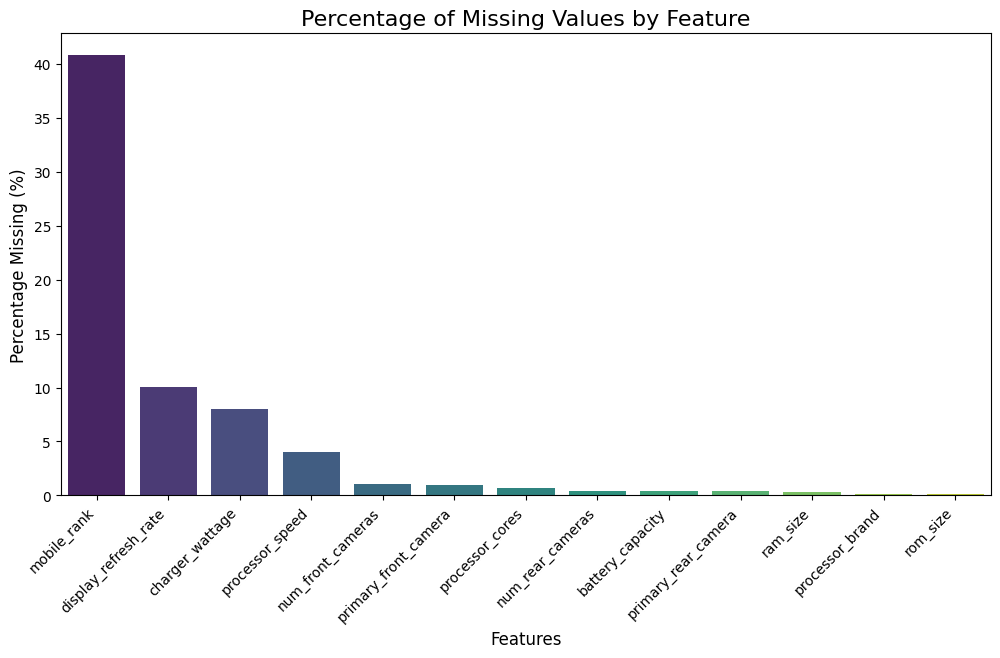

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df1.index,  y=missing_df1['missing_percentage'], palette='viridis')
plt.title('Percentage of Missing Values by Feature', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Percentage Missing (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

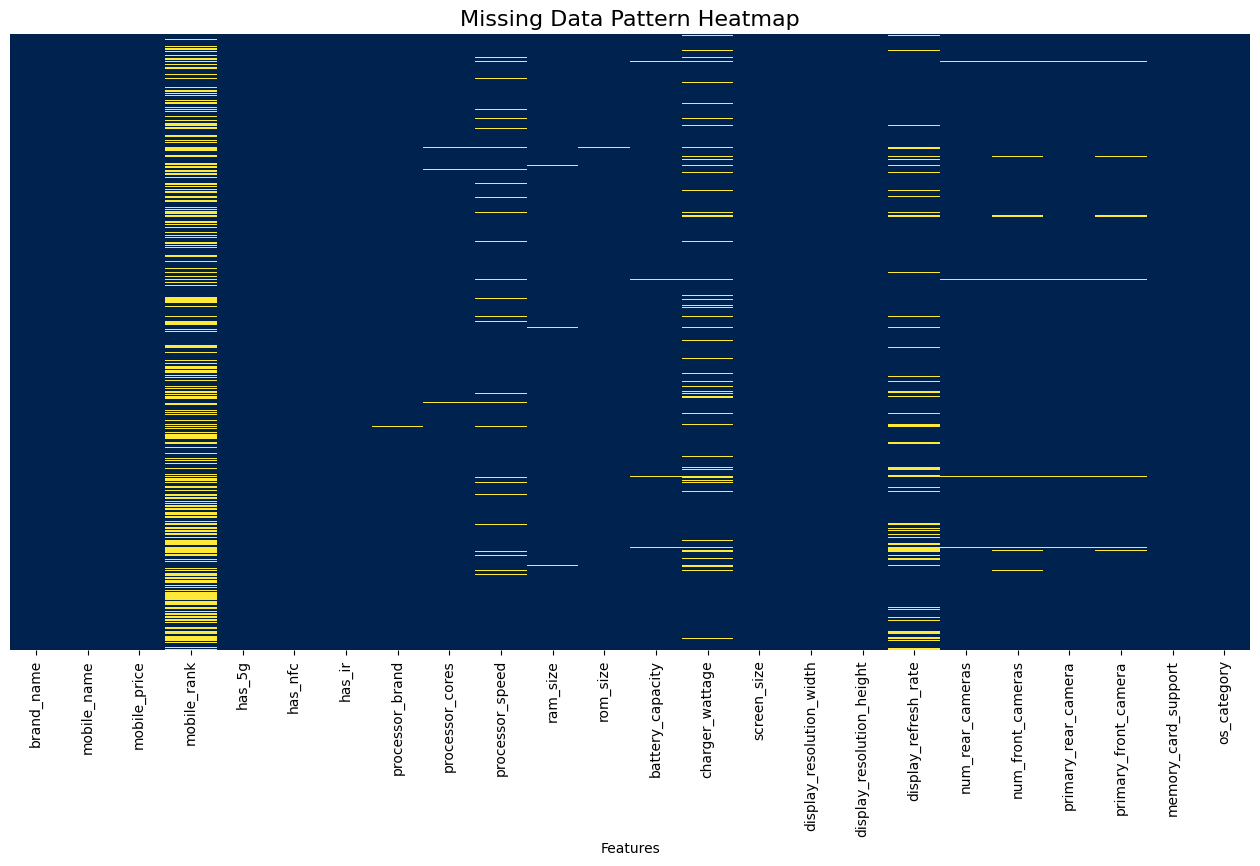

In [97]:
# Create a heatmap of missing values
plt.figure(figsize=(16, 8))
sns.heatmap(df1.isnull(),  cbar=False, yticklabels=False, cmap='cividis')
plt.title('Missing Data Pattern Heatmap', fontsize=16)
plt.xlabel('Features')
plt.show()

**The missing value heatmap did not show strong correlations between missingness in different columns, suggesting the data was missing somewhat at random (MAR) rather than in a structured block.**

Actually expect the first4 columns we can impute the missing values manually but **Reproducibility** This is the biggest issue. If you manually change the data, your entire analysis is **no longer "reproducible.**" No one else (or even you, six months from now) can just re-run your notebook from start to finish and get the same result. The goal is to have a single script that can do everything automatically.

**Imputation Strategy:**

The target variable, price, was excluded from the imputation process to prevent data leakage.

Numerical Features: KNNImputer (with k=5) was selected to fill missing values for numerical_cols_to_impute

**We are not Imputing the mobile_rank column.**

**Here’s why:**

**It's an Outcome, Not a Feature:** Like price, a phone's ranking is not a physical attribute (like RAM or battery). It's an outcome assigned by the website, likely based on all the other features and the price.

**High Risk of Data Leakage:** Using features like ram_size and battery to "predict" (impute) a missing rank is circular and leaks information.

In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

numerical_cols_to_impute = [col for col in numerical_cols if col != 'mobile_price' and col != 'mobile_rank']

df1_to_impute = df1[numerical_cols_to_impute]
# Keep categorical columns plus mobile_price and mobile_rank as a DataFrame (don't use '+' between DataFrames/Series)
df1_to_keep = df1[categorical_cols + ['mobile_price', 'mobile_rank']]


scaler = StandardScaler()
df1_scaled = scaler.fit_transform(df1_to_impute)
knn_imputer = KNNImputer(n_neighbors=5)
df1_imputed_scaled = knn_imputer.fit_transform(df1_scaled)
df1_imputed = scaler.inverse_transform(df1_imputed_scaled)
df1_imputed = pd.DataFrame(df1_imputed, columns=numerical_cols_to_impute)


int_cols = df1[numerical_cols_to_impute].select_dtypes(include=['Int64', 'int64']).columns
for col in int_cols:
    df1_imputed[col] = df1_imputed[col].round().astype('Int64')
df1_imputed.index = df1_to_keep.index
df1_clean = pd.concat([df1_to_keep, df1_imputed], axis=1)
df1_clean = df1_clean[df1.columns]
df1_clean.isna().sum()

brand_name                     0
mobile_name                    0
mobile_price                   0
mobile_rank                  388
has_5g                         0
has_nfc                        0
has_ir                         0
processor_brand                1
processor_cores                0
processor_speed                0
ram_size                       0
rom_size                       0
battery_capacity               0
charger_wattage                0
screen_size                    0
display_resolution_width       0
display_resolution_height      0
display_refresh_rate           0
num_rear_cameras               0
num_front_cameras              0
primary_rear_camera            0
primary_front_camera           0
memory_card_support            0
os_category                    0
dtype: int64

In [99]:
df1_clean.head()

,brand_name,mobile_name,mobile_price,mobile_rank,has_5g,has_nfc,has_ir,processor_brand,processor_cores,processor_speed,...,screen_size,display_resolution_width,display_resolution_height,display_refresh_rate,num_rear_cameras,num_front_cameras,primary_rear_camera,primary_front_camera,memory_card_support,os_category
0,samsung,Samsung Galaxy S24 Ultra,79999,92.0,True,True,False,snapdragon,8,3.30,...,6.80,1440,3120,120,4,1,200.0,12.0,False,Android
1,oneplus,OnePlus Nord CE 5 5G,23999,83.0,True,False,True,dimensity,8,3.35,...,6.77,1080,2392,120,2,1,50.0,16.0,True,Android
2,apple,Apple iPhone 15,49999,81.0,True,True,False,bionic,6,3.46,...,6.10,1179,2556,120,2,1,48.0,12.0,False,iOS
3,vivo,Vivo V60e,29999,85.0,True,True,True,dimensity,8,2.50,...,6.77,1080,2392,120,2,1,200.0,50.0,False,Android
4,realme,Realme P3 Ultra (8GB RAM + 256GB),19999,81.0,True,False,True,dimensity,8,3.35,...,6.83,1272,2800,120,2,1,50.0,16.0,False,Android


In [100]:
# Get the main descriptive statistics
df1_clean[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mobile_price,952.0,30802.579832,32054.775857,3999.0,13036.5,20499.0,32767.25,229900.0
mobile_rank,564.0,84.280142,3.446041,80.0,82.0,84.0,86.0,97.0
processor_cores,952.0,7.878151,0.74078,1.0,8.0,8.0,8.0,10.0
processor_speed,952.0,2.642729,0.583581,0.0013,2.35,2.5,3.0,4.47
ram_size,952.0,8.045168,3.003863,0.0,6.0,8.0,8.0,24.0
rom_size,952.0,211.282563,161.035003,8.0,128.0,128.0,256.0,2048.0
battery_capacity,952.0,5227.269958,825.241798,1950.0,5000.0,5000.0,5630.0,7550.0
charger_wattage,952.0,47.970588,28.421663,10.0,25.0,44.0,68.0,150.0
screen_size,952.0,6.654233,0.367512,2.95,6.6,6.7,6.77,8.3
display_resolution_width,952.0,1077.065126,250.510822,240.0,1080.0,1080.0,1208.5,2408.0


In [101]:
# Get skewness and kurtosis
print("Skewness and Kurtosis for Numerical Features:")
skew_kurt_stats = pd.DataFrame({
    'skewness': df1_clean[numerical_cols].skew(),
    'kurtosis': df1_clean[numerical_cols].kurtosis()
})
skew_kurt_stats

Skewness and Kurtosis for Numerical Features:


,skewness,kurtosis
mobile_price,2.892662,9.424746
mobile_rank,0.957797,0.589145
processor_cores,-5.556375,44.797121
processor_speed,0.570977,2.697767
ram_size,0.703834,0.963177
rom_size,3.618042,24.320428
battery_capacity,0.001149,1.720648
charger_wattage,0.808621,-0.151948
screen_size,-5.203807,52.769872
display_resolution_width,0.984679,5.27595


Analysis for mobile_price


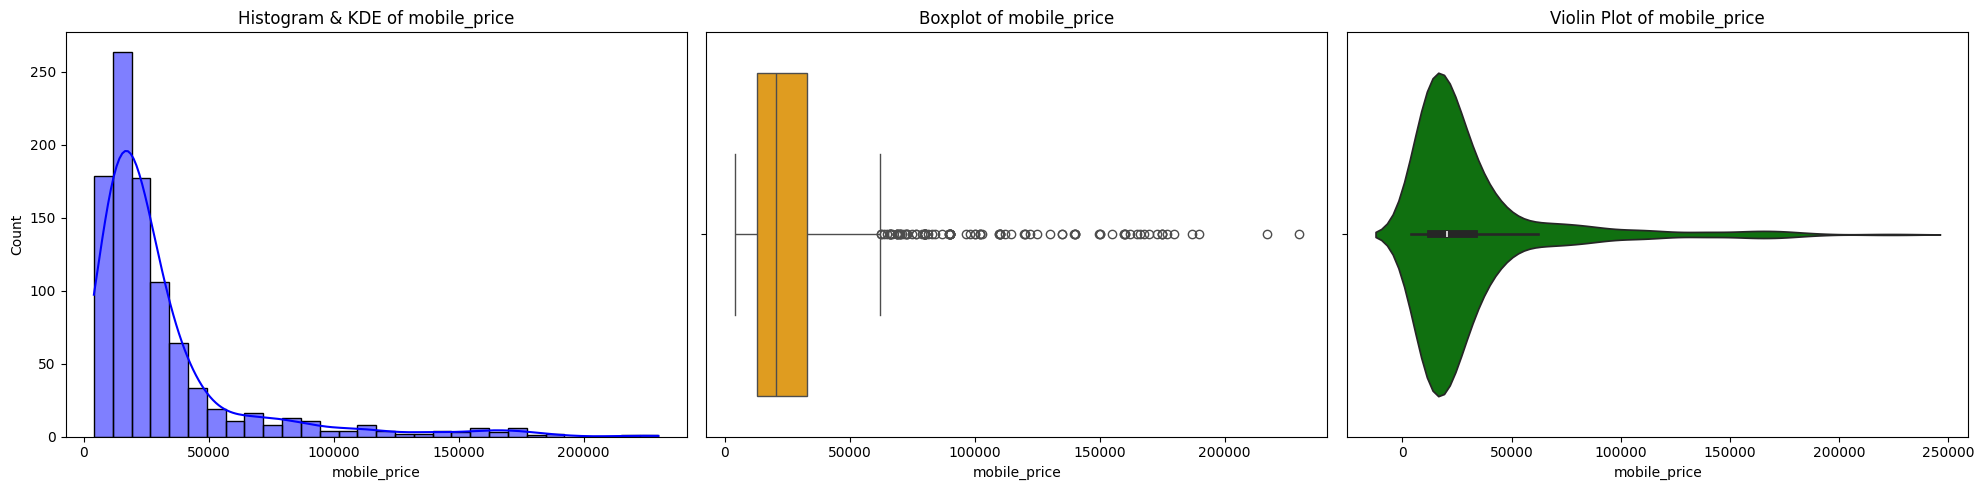

Analysis for mobile_rank


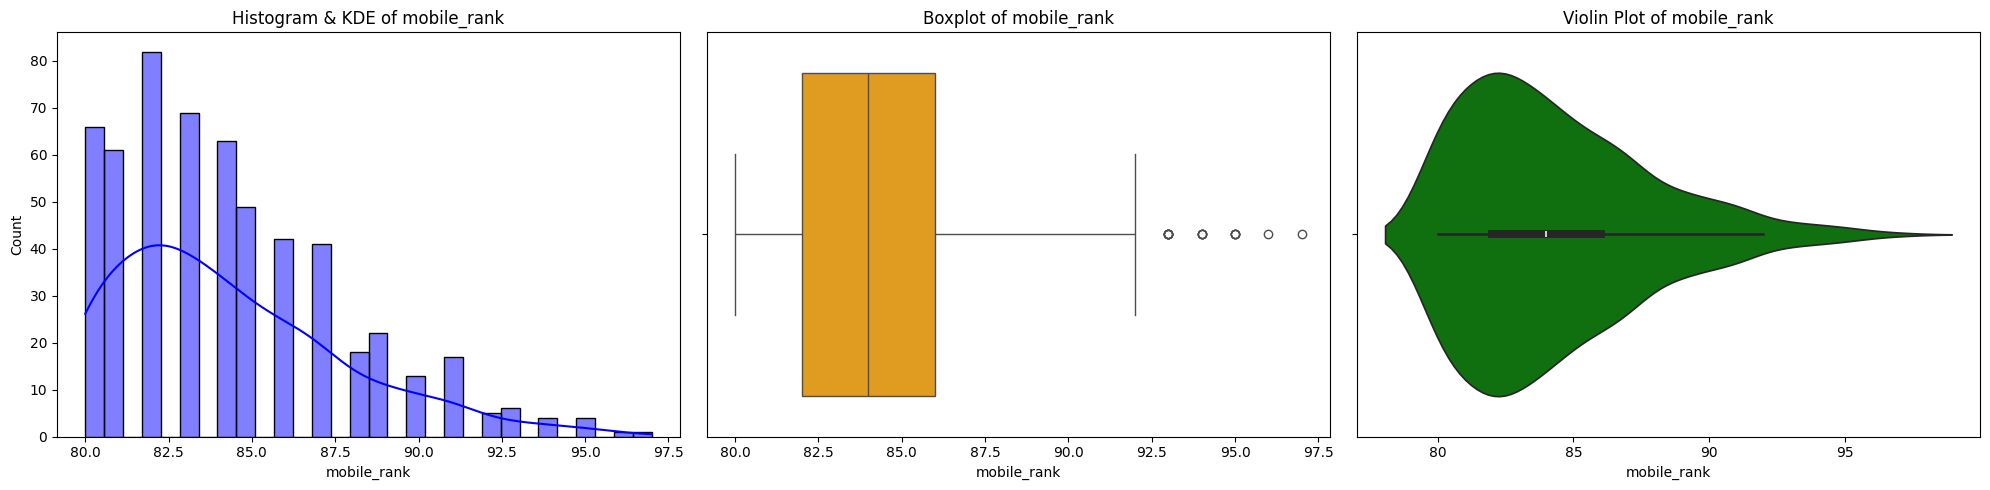

Analysis for processor_cores


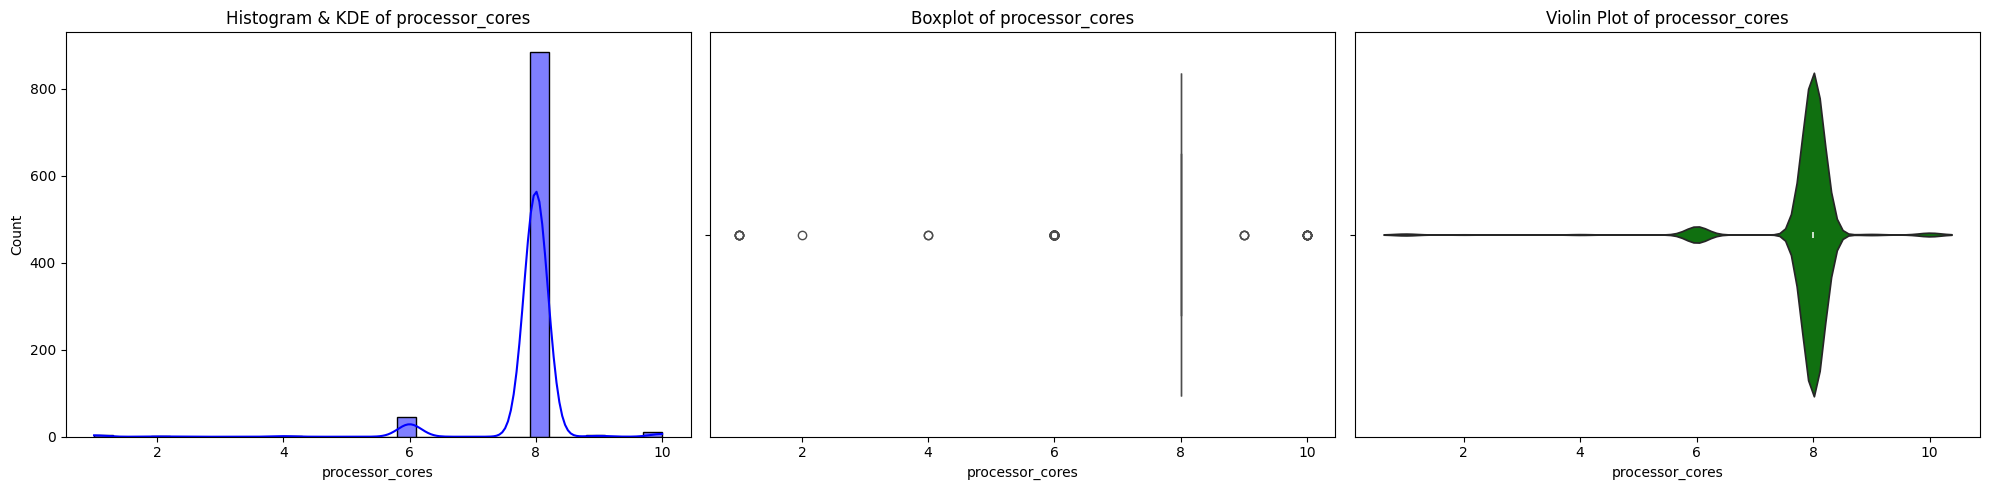

Analysis for processor_speed


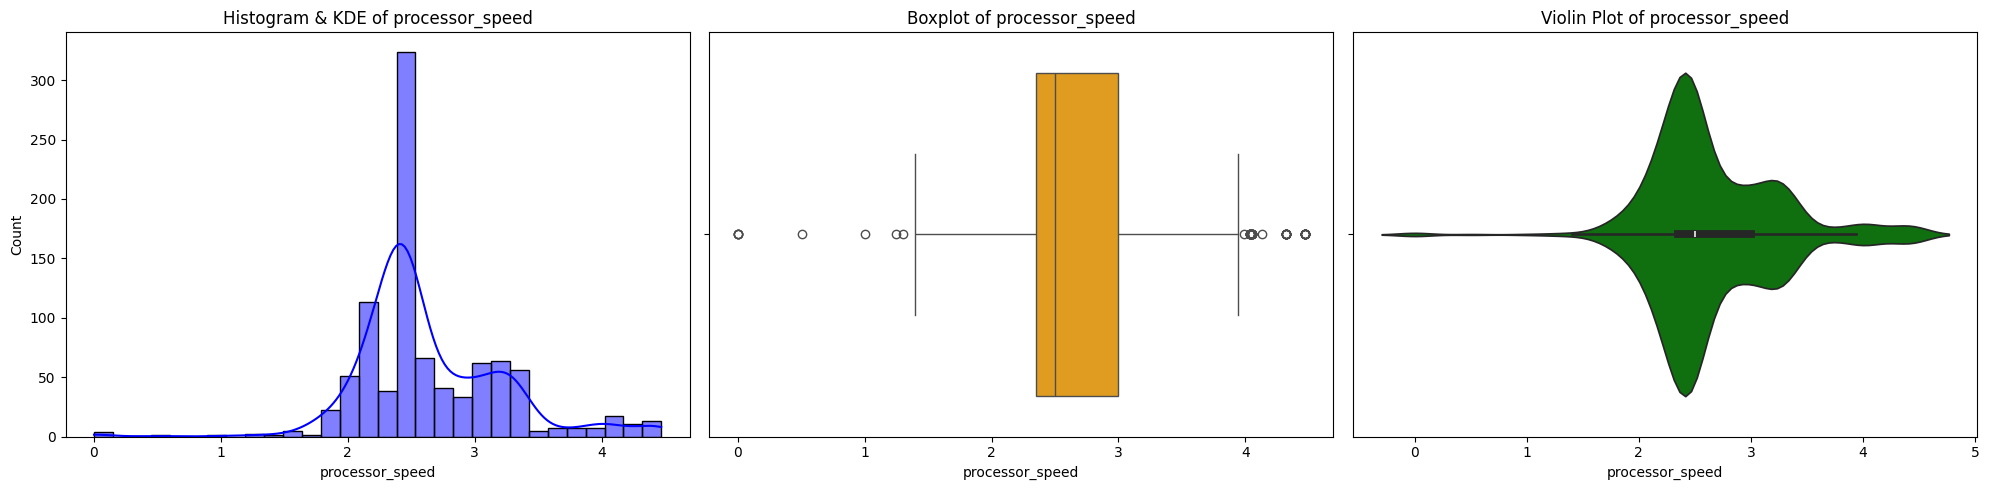

Analysis for ram_size


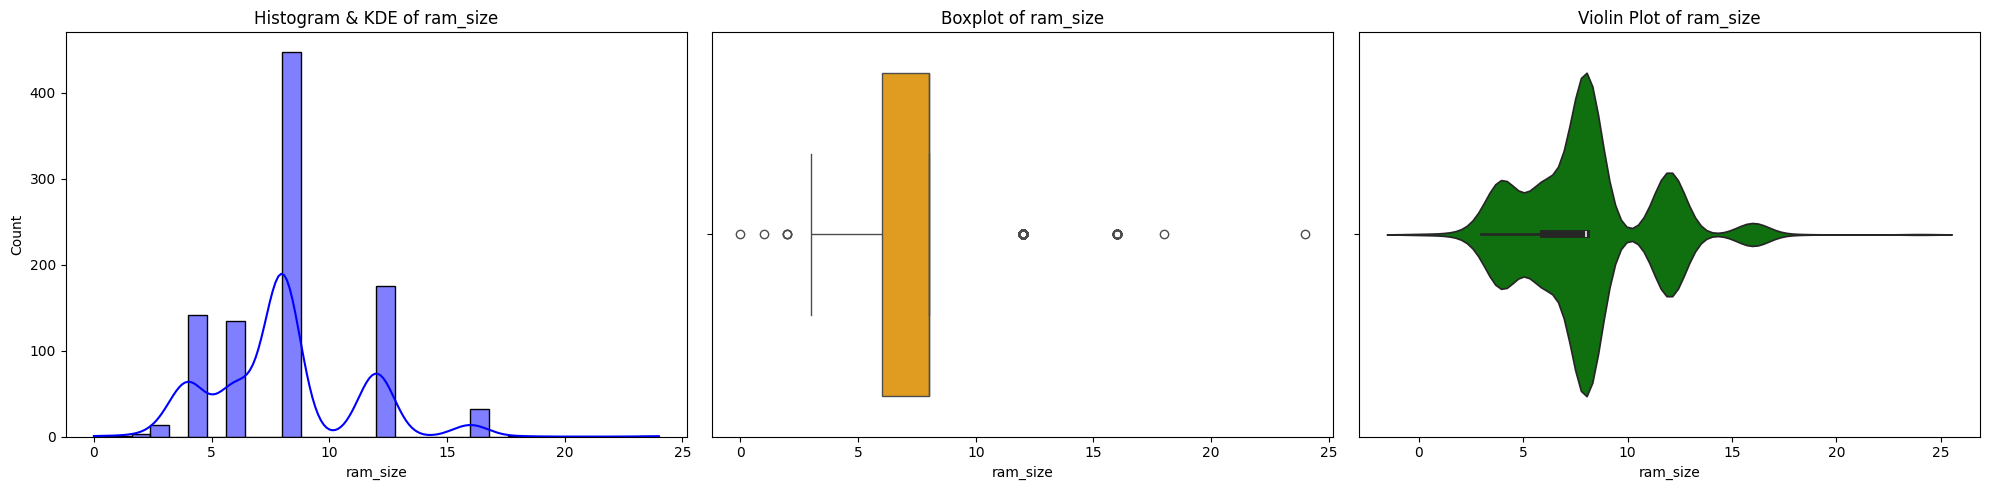

Analysis for rom_size


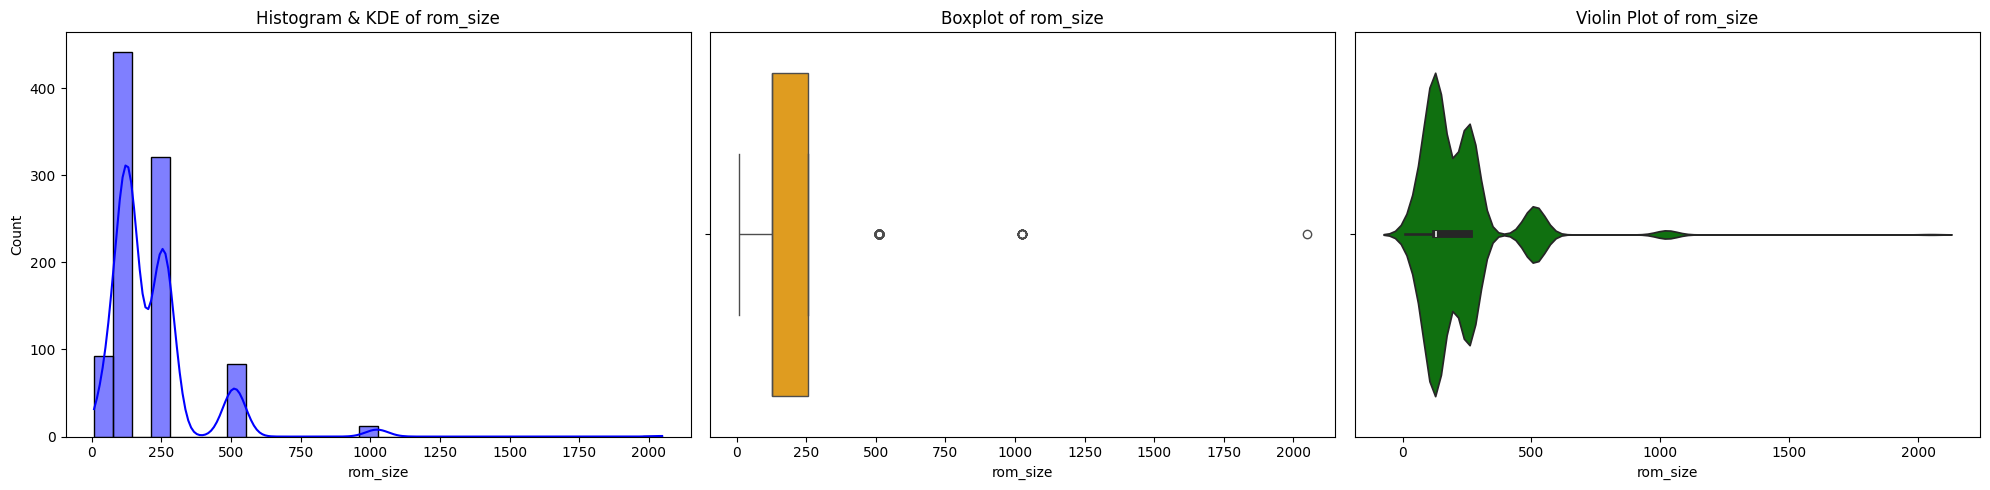

Analysis for battery_capacity


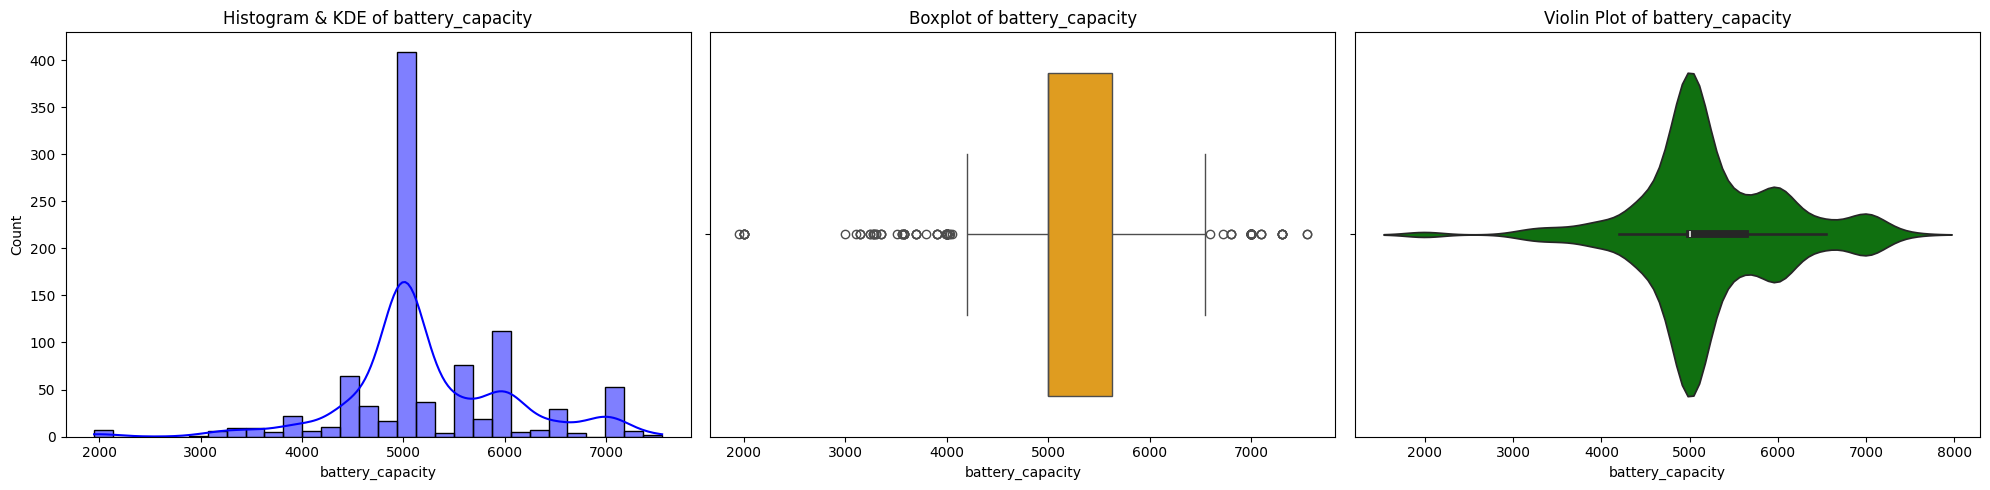

Analysis for charger_wattage


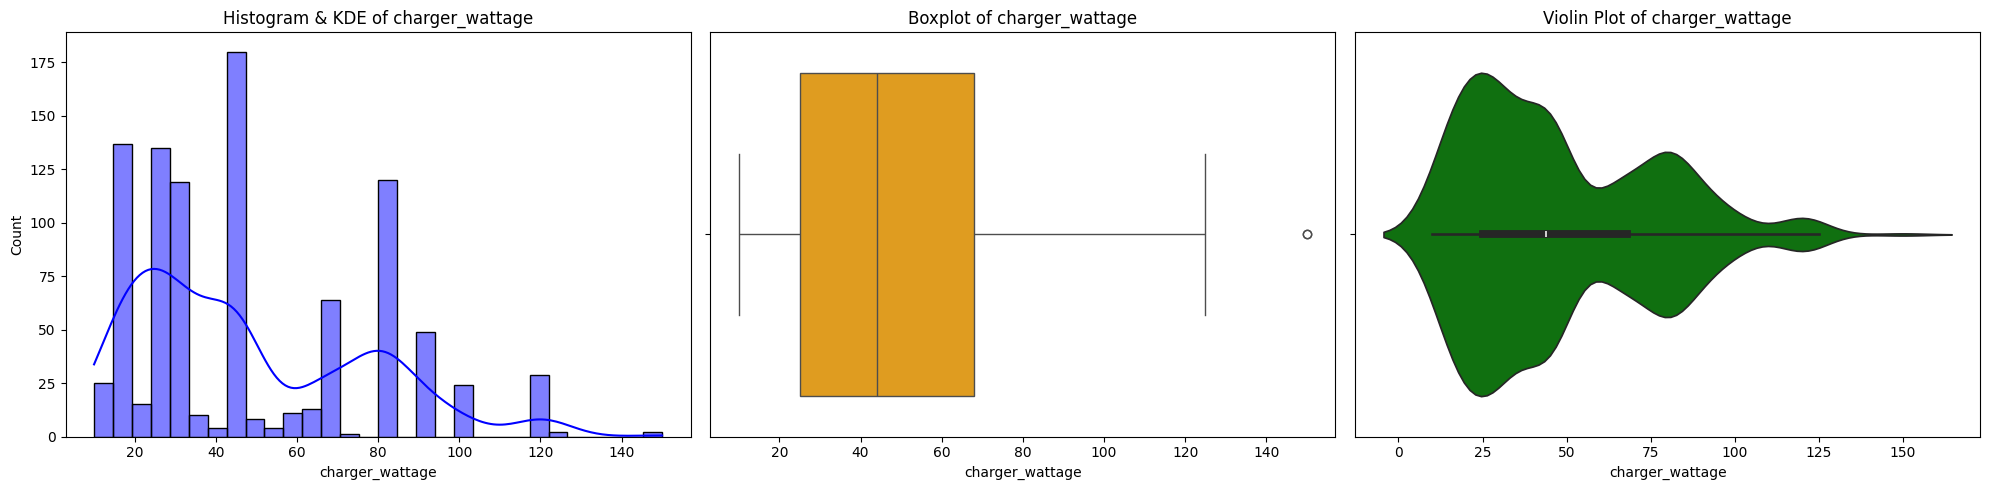

Analysis for screen_size


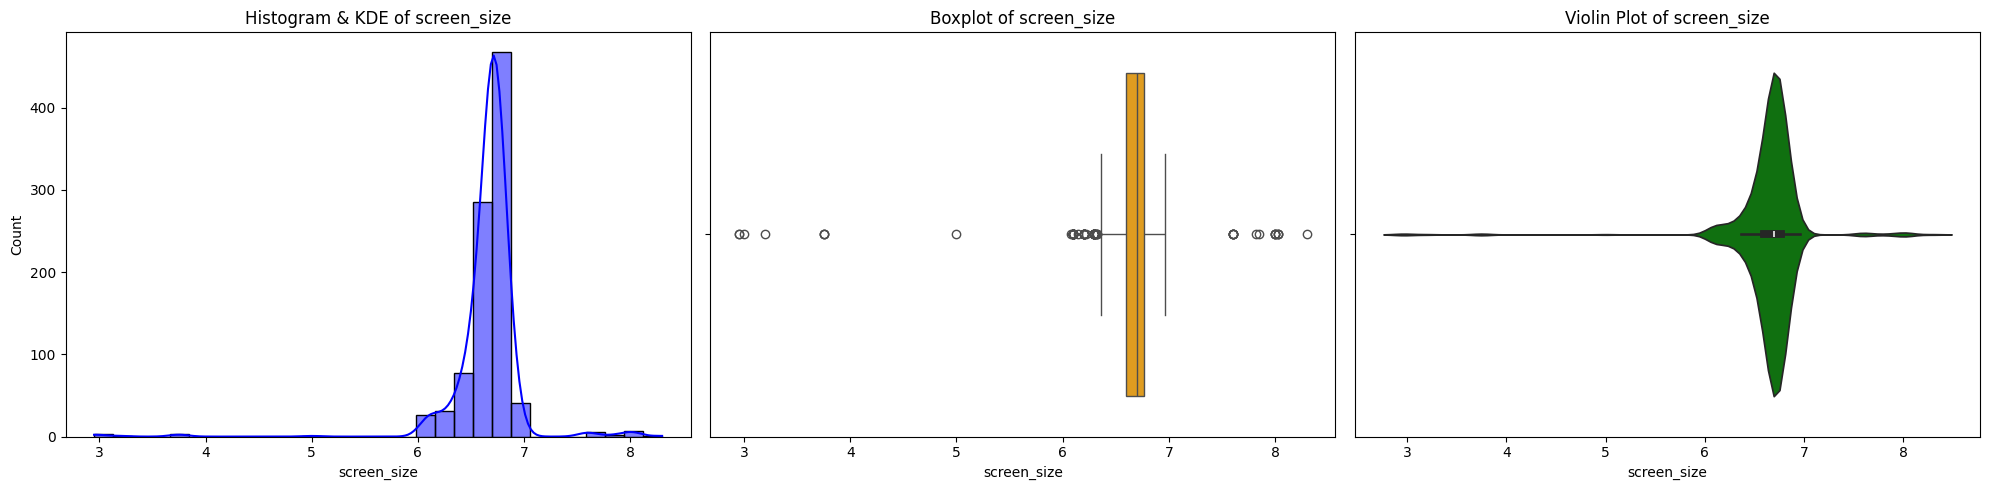

Analysis for display_resolution_width


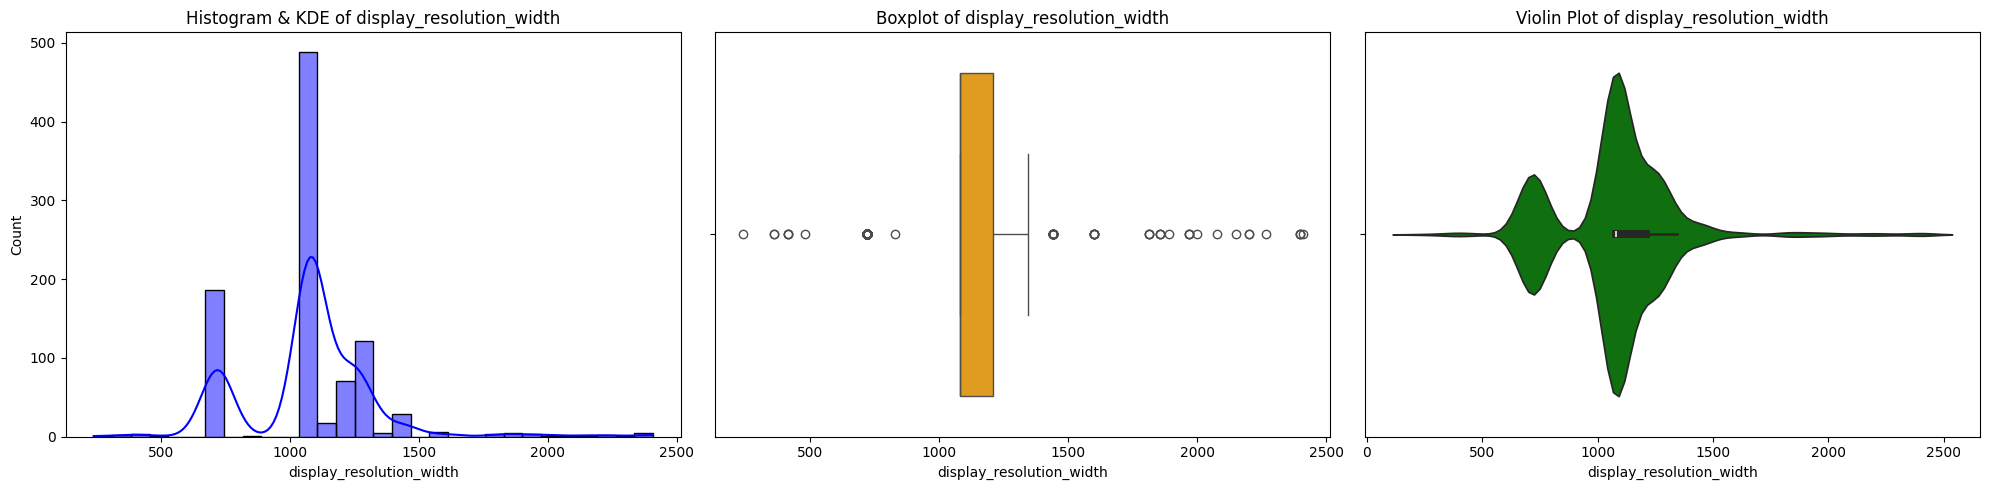

Analysis for display_resolution_height


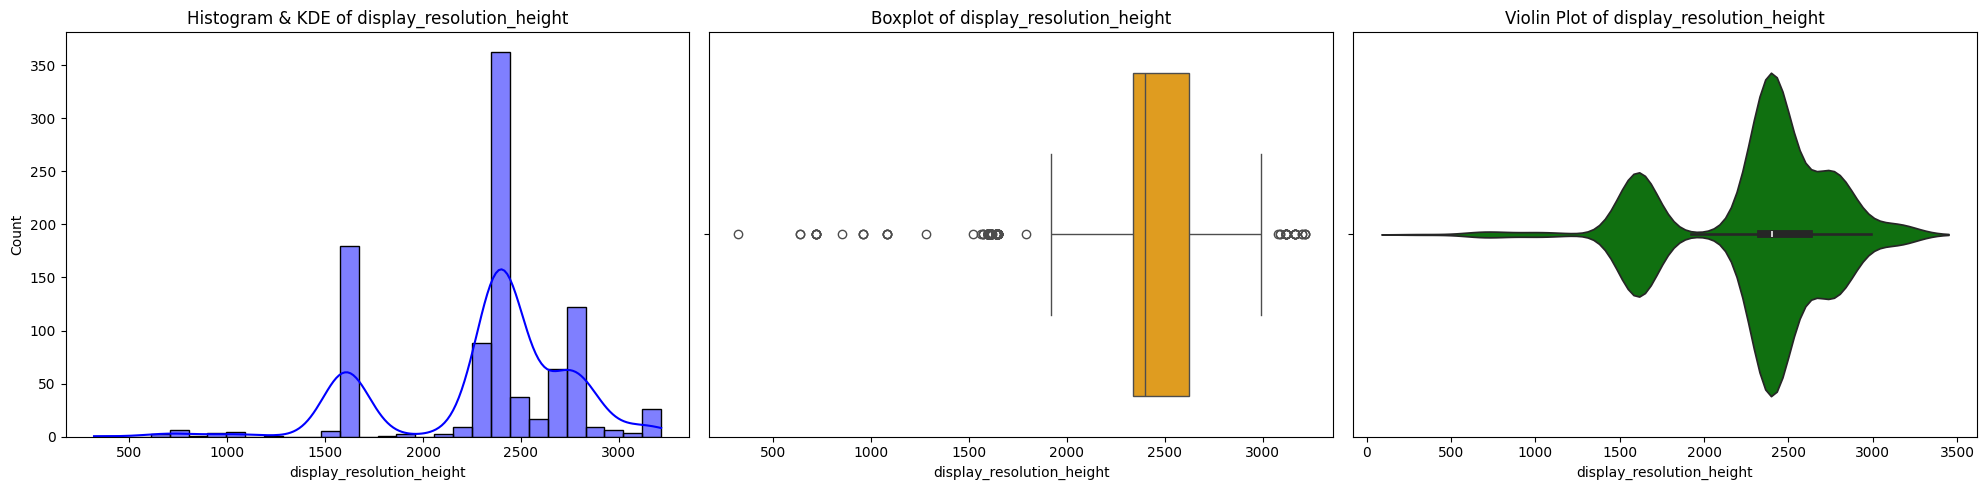

Analysis for display_refresh_rate


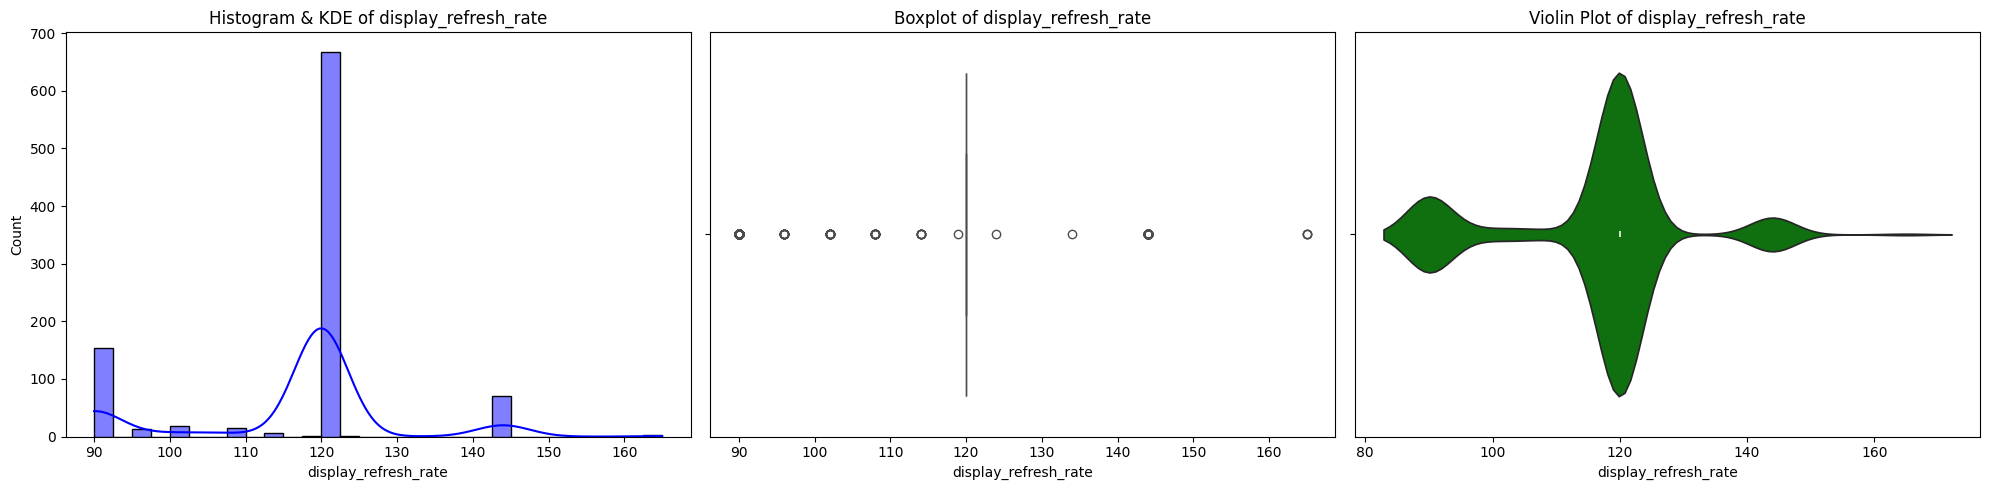

Analysis for num_rear_cameras


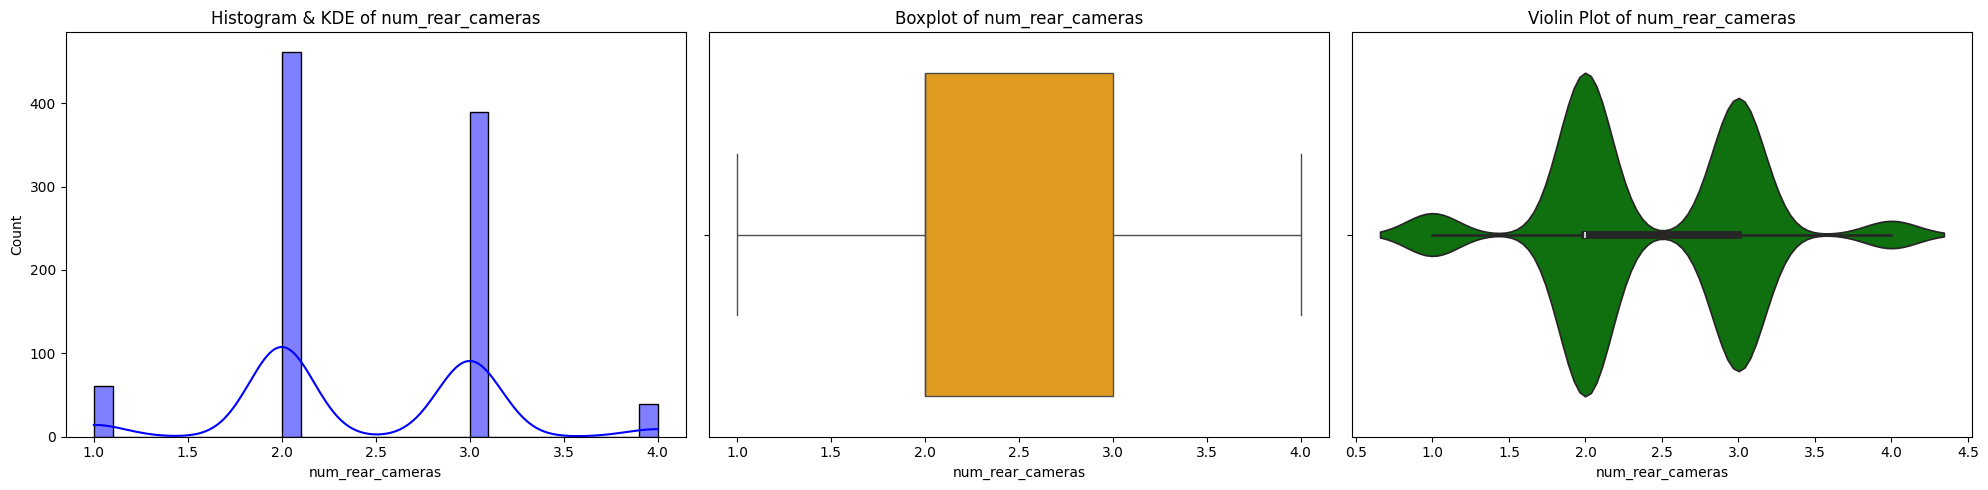

Analysis for num_front_cameras


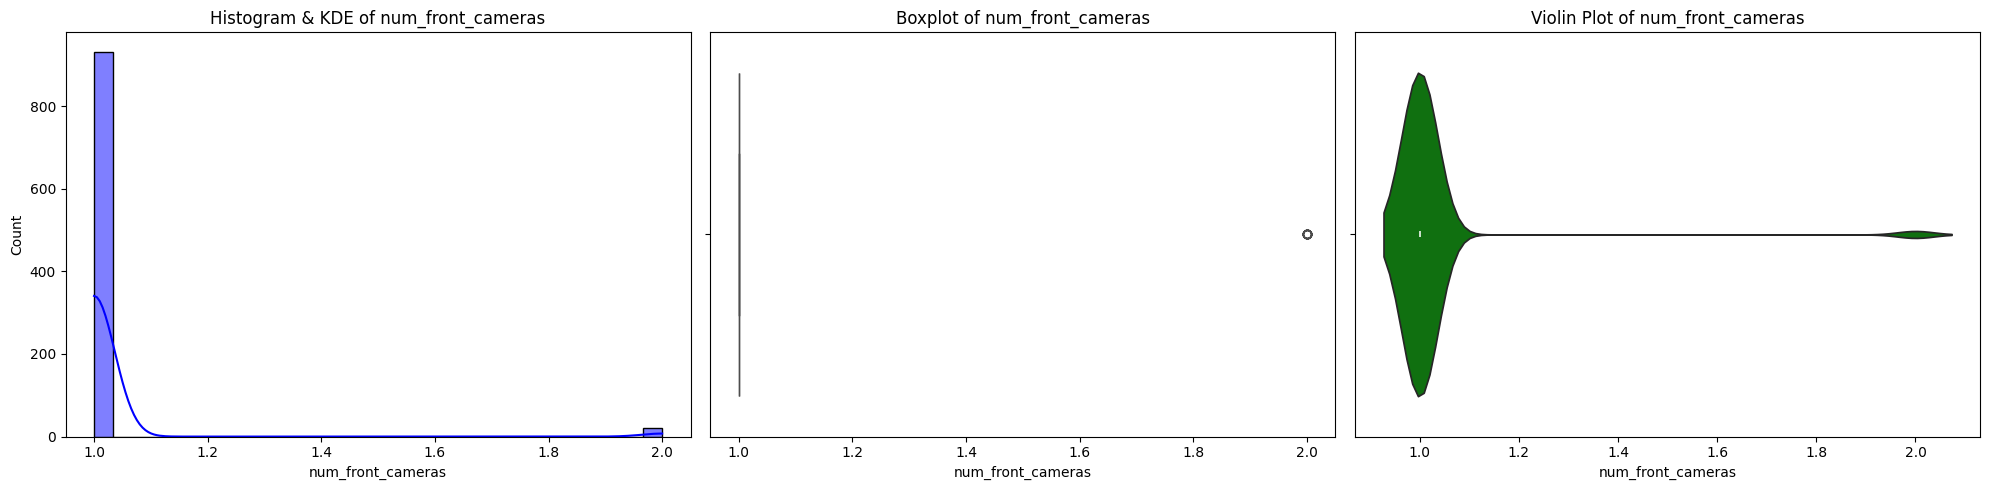

Analysis for primary_rear_camera


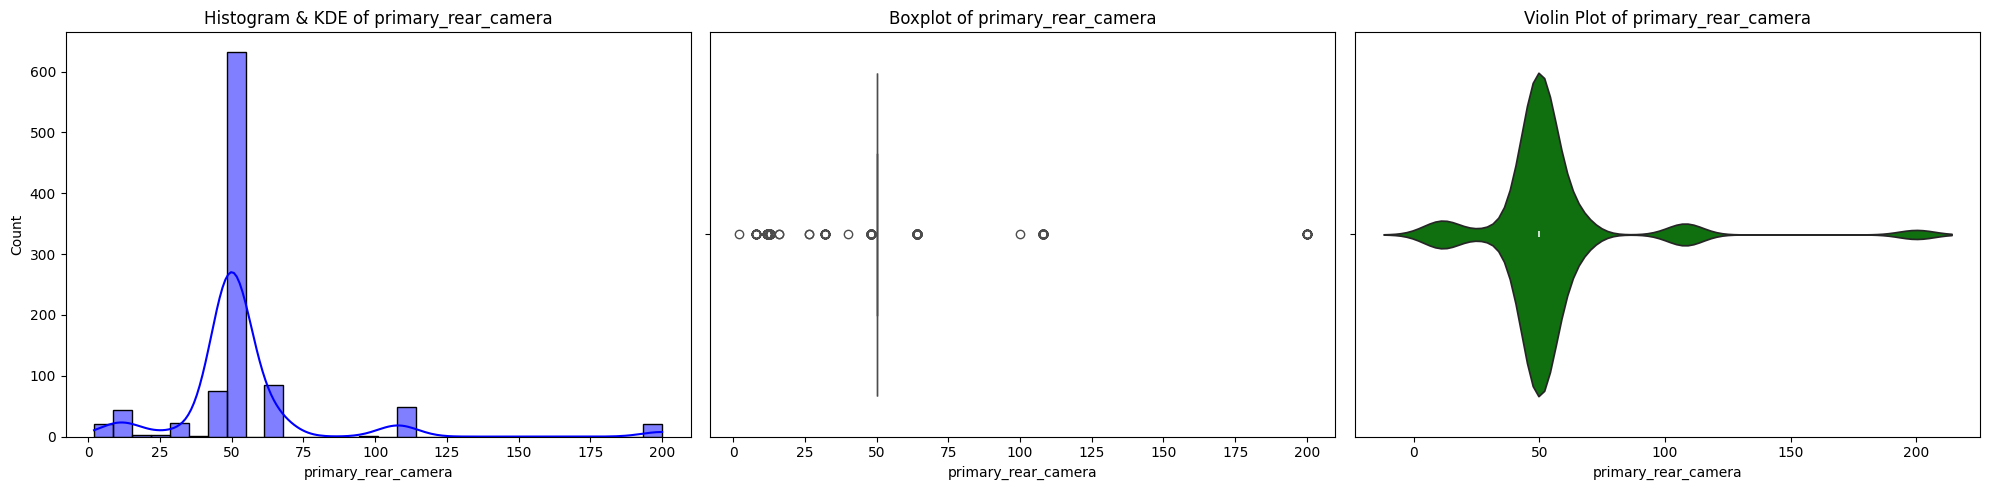

Analysis for primary_front_camera


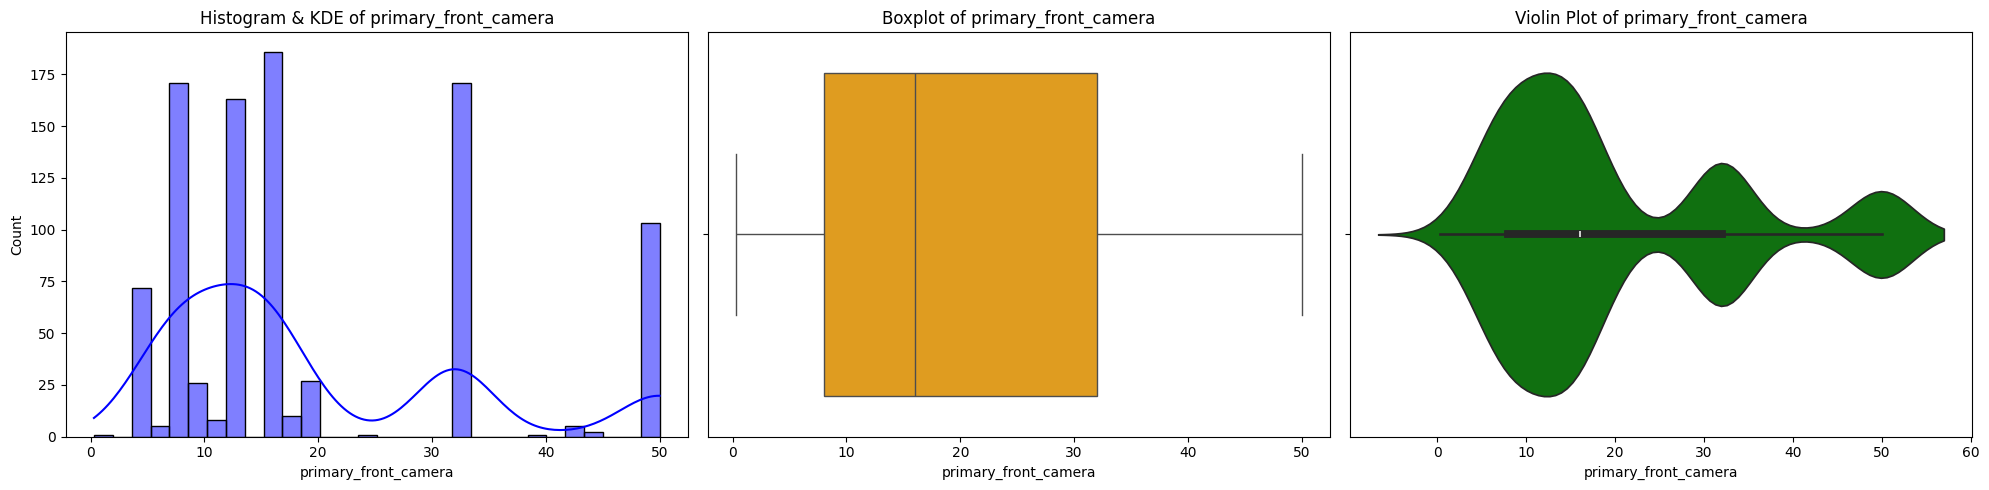

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    print(f"Analysis for {col}")
    
    # Set up the figure for 3 plots
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 3, 1)
    sns.histplot(df1_clean[col], kde=True, bins=30, color='blue')
    plt.title(f'Histogram & KDE of {col}')
    
    # Plot 2: Boxplot
    # Best for quickly spotting outliers
    plt.subplot(1, 3, 2)
    sns.boxplot(x=df1_clean[col], color='orange')
    plt.title(f'Boxplot of {col}')
    
    # Plot 3: Violin Plot
    # Combines the boxplot and KDE
    plt.subplot(1, 3, 3)
    sns.violinplot(x=df1_clean[col], color='green')
    plt.title(f'Violin Plot of {col}')
    
    plt.tight_layout()
    plt.show()

### Summary of Numerical Features

* **Typical Phone Specs (Median):** The most common phone in the dataset has **6GB RAM**, **128GB ROM**, a **5000 mAh** battery, a **33W** charger, a **6.6-inch** screen, and a **120Hz** refresh rate.

* **Right-Skewed Features (High-End Tail):**
    * Features like **`ram_size`**, **`rom_size`**, **`charger_wattage`**, and **camera megapixels** are all strongly **right-skewed** (`skewness > 1.0`).
    * This means most phones have average specs, but there is a "long tail" of a few expensive phones with very high specs.

* **Left-Skewed Features (Low-End Tail):**
    * Features like **`display_refresh_rate`** (`skewness -0.9`) and **`num_rear_cameras`** (`skewness -0.5`) are **left-skewed**.
    * This means most phones have the "good" spec (120Hz or 3 cameras), and the tail consists of a few cheaper models with lower specs.

* **Symmetric Features:**
    * **`screen_size`** is almost **perfectly symmetric** (`skewness -0.04`). Most phones are clustered very tightly around the 6.6-inch average.

* **Outliers Detected:**
    * The `max` values and high `kurtosis` (peakedness) confirm significant outliers in **`ram_size` **, **`rom_size`**, and **`charger_wattage` **. These will need to be investigated in the next step.

Analysis for: brand_name 

Frequency Counts:
brand_name
samsung      149
realme       130
vivo         124
oppo          85
xiaomi        71
motorola      59
poco          51
apple         45
oneplus       44
iqoo          35
lava          28
infinix       27
tecno         26
google        21
nothing       16
honor          6
hmd            6
peace          5
alcatel        5
cmf            4
ai+            4
itel           4
acer           3
blackzone      2
asus           1
microsoft      1
Name: count, dtype: int64

Percentage Distribution:
brand_name
samsung      15.65
realme       13.66
vivo         13.03
oppo          8.93
xiaomi        7.46
motorola      6.20
poco          5.36
apple         4.73
oneplus       4.62
iqoo          3.68
lava          2.94
infinix       2.84
tecno         2.73
google        2.21
nothing       1.68
honor         0.63
hmd           0.63
peace         0.53
alcatel       0.53
cmf           0.42
ai+           0.42
itel          0.42
acer          0.32
bl

C:\Users\asus\AppData\Local\Temp\ipykernel_11560\2514674248.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


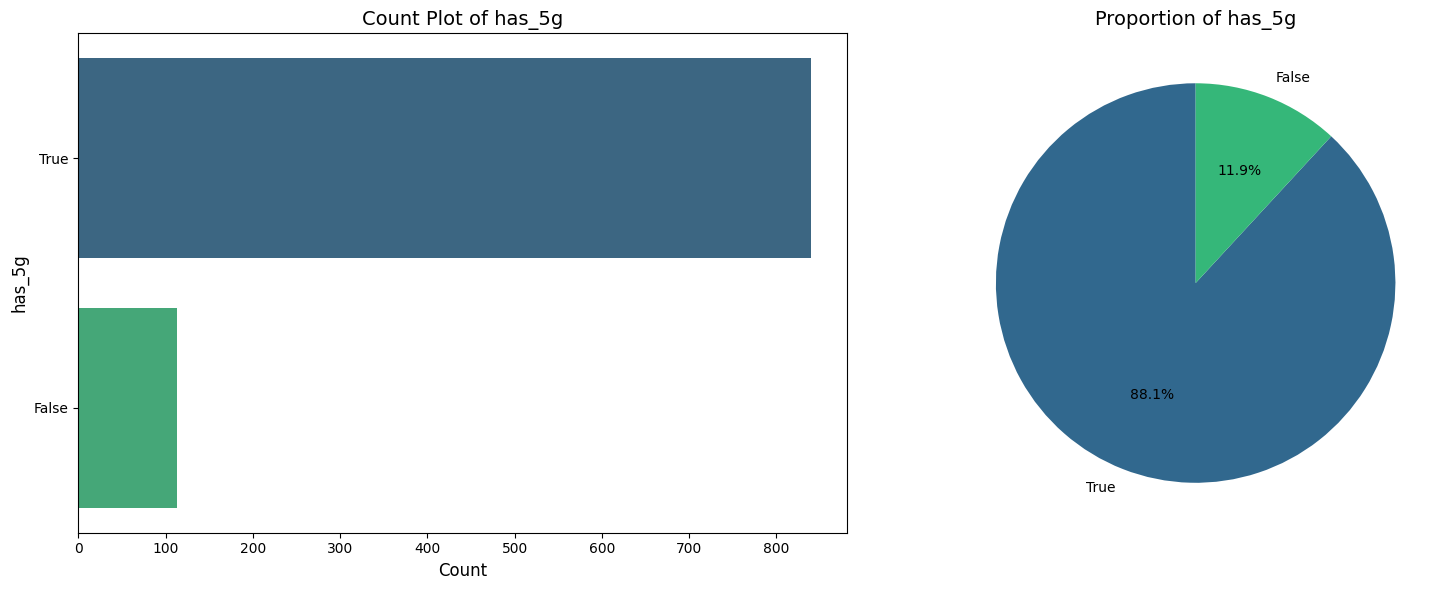

Analysis for: has_nfc 

Frequency Counts:
has_nfc
False    540
True     412
Name: count, dtype: int64

Percentage Distribution:
has_nfc
False    56.72
True     43.28
Name: proportion, dtype: float64


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\2514674248.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


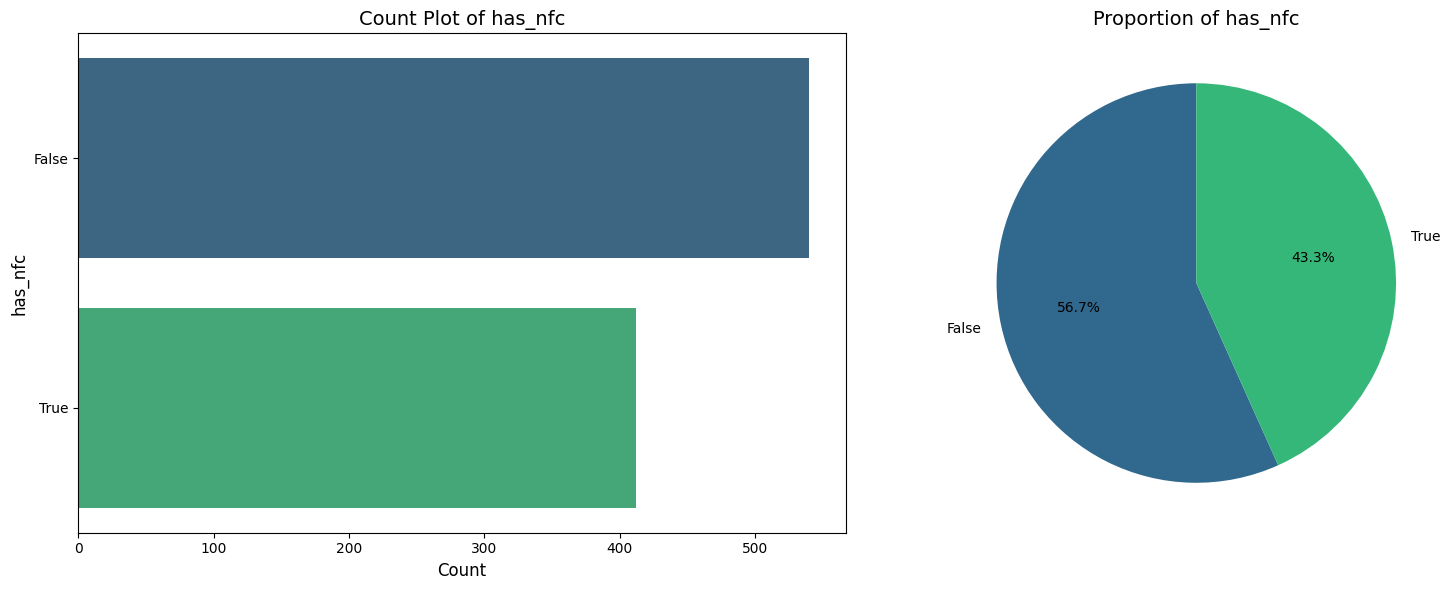

Analysis for: has_ir 

Frequency Counts:
has_ir
False    686
True     266
Name: count, dtype: int64

Percentage Distribution:
has_ir
False    72.06
True     27.94
Name: proportion, dtype: float64


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\2514674248.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


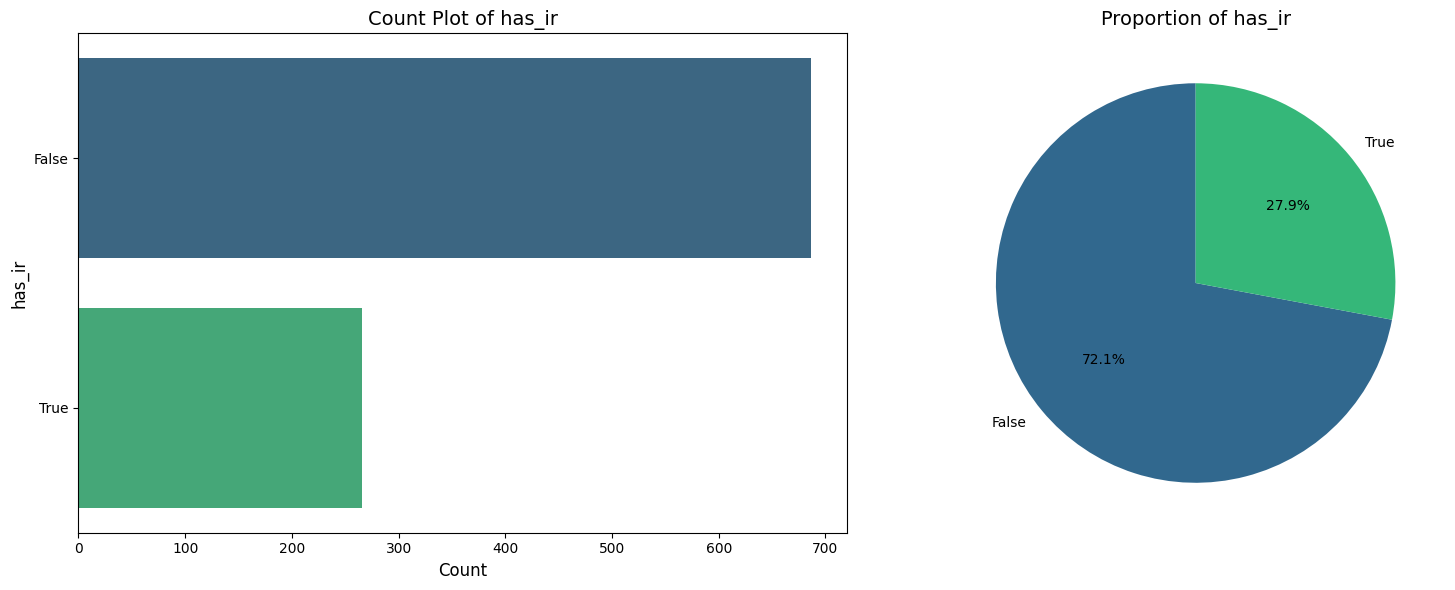

Analysis for: processor_brand 

Frequency Counts:
processor_brand
dimensity     391
snapdragon    339
exynos         62
helio          53
unisoc         35
bionic         32
tensor         17
apple          12
google          4
tiger           3
a13             1
dimensit        1
sc9863a         1
Name: count, dtype: int64

Percentage Distribution:
processor_brand
dimensity     41.11
snapdragon    35.65
exynos         6.52
helio          5.57
unisoc         3.68
bionic         3.36
tensor         1.79
apple          1.26
google         0.42
tiger          0.32
a13            0.11
dimensit       0.11
sc9863a        0.11
Name: proportion, dtype: float64


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\2514674248.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


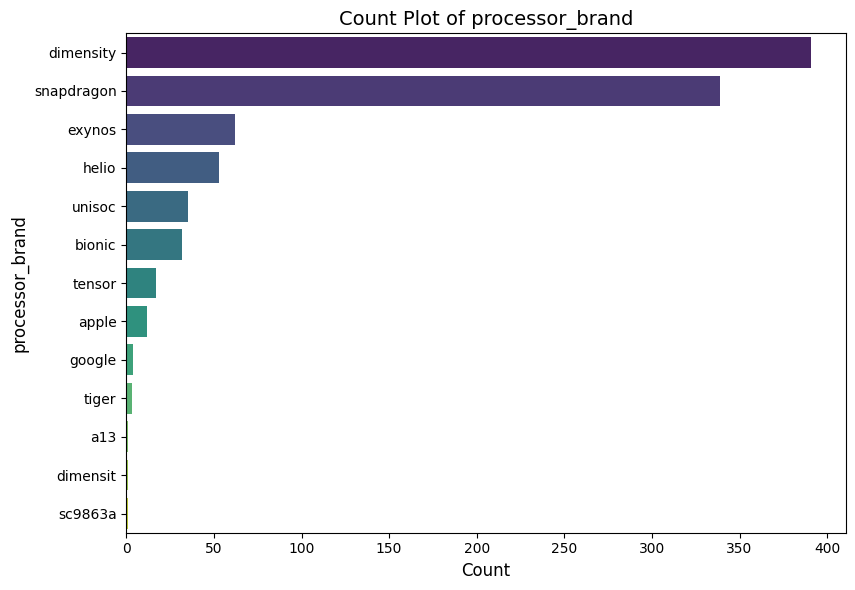

Analysis for: memory_card_support 

Frequency Counts:
memory_card_support
True     730
False    222
Name: count, dtype: int64

Percentage Distribution:
memory_card_support
True     76.68
False    23.32
Name: proportion, dtype: float64


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\2514674248.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


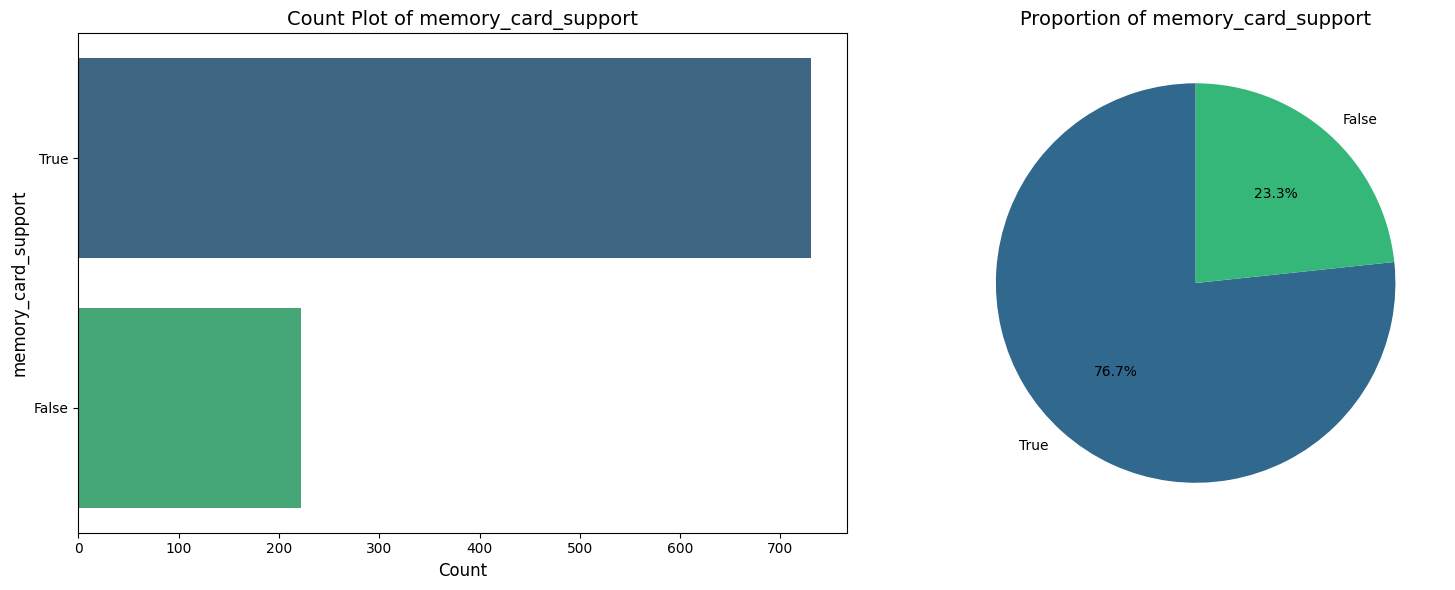

Analysis for: os_category 

Frequency Counts:
os_category
Android    884
iOS         45
Other       23
Name: count, dtype: int64

Percentage Distribution:
os_category
Android    92.86
iOS         4.73
Other       2.42
Name: proportion, dtype: float64


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\2514674248.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


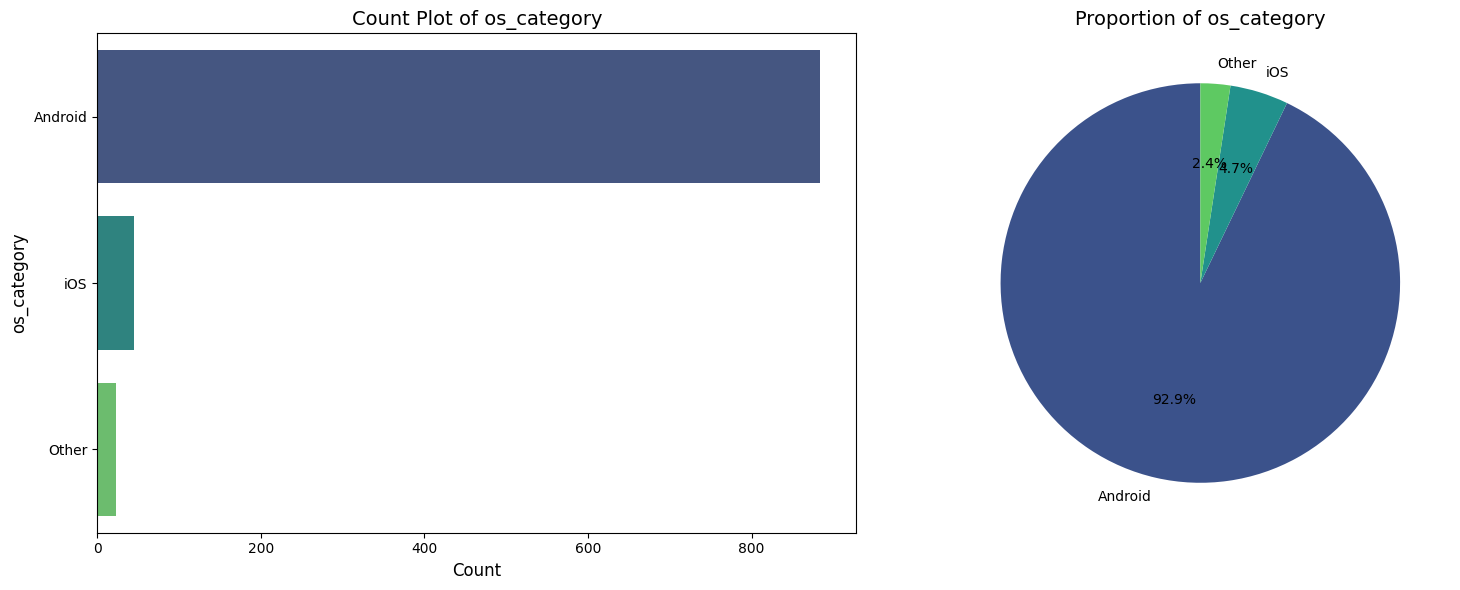

In [103]:

categorical_features = [col for col in categorical_cols if col not in ['mobile_name']]

for col in categorical_features:
    print(f"Analysis for: {col} ")
    
    # Get frequency and percentage
    freq_counts = df1_clean[col].value_counts()
    pct_counts = df1_clean[col].value_counts(normalize=True) * 100
    
    print("\nFrequency Counts:")
    print(freq_counts)
    print("\nPercentage Distribution:")
    print(pct_counts.round(2))

    
    # Check if there are too many unique values to plot clearly
    if freq_counts.nunique() > 20:
        print(f"Skipping plot for {col}, too many unique values ({freq_counts.nunique()}).")
        continue

    plt.figure(figsize=(16, 6))

    # Plot 1: Count Plot (Bar Chart)
    plt.subplot(1, 2, 1)
    # Use a horizontal bar plot (y=) for better readability of labels
    sns.countplot(
        y=df1_clean[col], 
        order=freq_counts.index, 
        palette='viridis'
    )
    plt.title(f'Count Plot of {col}', fontsize=14)
    plt.xlabel('Count', fontsize=12)
    plt.ylabel(col, fontsize=12)

    # Plot 2: Pie Chart (Good for proportions)
    # Only make a pie chart if there are 7 or fewer categories
    if len(freq_counts) <= 7:
        plt.subplot(1, 2, 2)
        plt.pie(
            freq_counts, 
            labels=freq_counts.index, 
            autopct='%.1f%%',  # Show percentage
            startangle=90,
            colors=sns.color_palette('viridis', len(freq_counts))
        )
        plt.title(f'Proportion of {col}', fontsize=14)
    
    plt.tight_layout()
    plt.show()

### Summary of Categorical Features

* **Processor Brand:** The market is dominated by two main brands: **Snapdragon** (43.1%) and **MediaTek** (38.9%). Other brands like Apple and Google are very rare in this dataset.

* **Operating System:** The `os_category` feature is **extremely imbalanced**. **Android** makes up 90.7% of the phones, with iOS (Apple) and "Other" making up the small remainder. This column may not be very useful for modeling.

* **5G Support:** `has_5g` is a **well-distributed** feature. A majority of phones (**71.9%**) are 5G capable, while 28.1% are not.

* **NFC Support:** `has_nfc` is **highly imbalanced**. The vast majority of phones (**70.4%**) **do not** have NFC.

* **IR Blaster:** `has_ir_blaster` is also **highly imbalanced**. This is a rare feature, with **80.3%** of phones **not** having it.

* **Memory Card:** `memory_card_support` is **well-balanced**, with a slight majority of phones (**59.3%**) supporting expandable memory.

## **Biverient analysis**

Spearman Correlation with Mobile Price
mobile_price                 1.000000
processor_speed              0.838710
ram_size                     0.762493
rom_size                     0.729413
mobile_rank                  0.725522
display_resolution_width     0.725142
display_resolution_height    0.655225
charger_wattage              0.567905
primary_front_camera         0.550432
display_refresh_rate         0.452678
num_rear_cameras             0.390831
num_front_cameras            0.208800
screen_size                  0.146013
primary_rear_camera          0.117147
battery_capacity            -0.127550
processor_cores             -0.155194
Name: mobile_price, dtype: float64

--- Visualizing Numerical Features vs. Log-Price ---


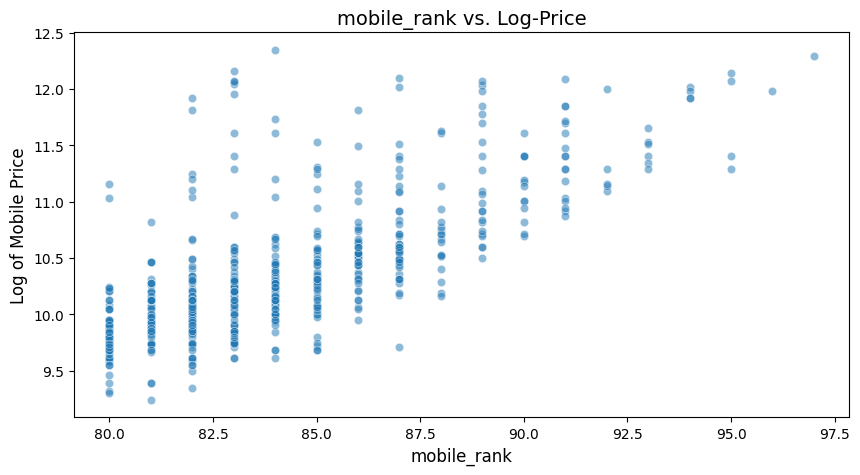

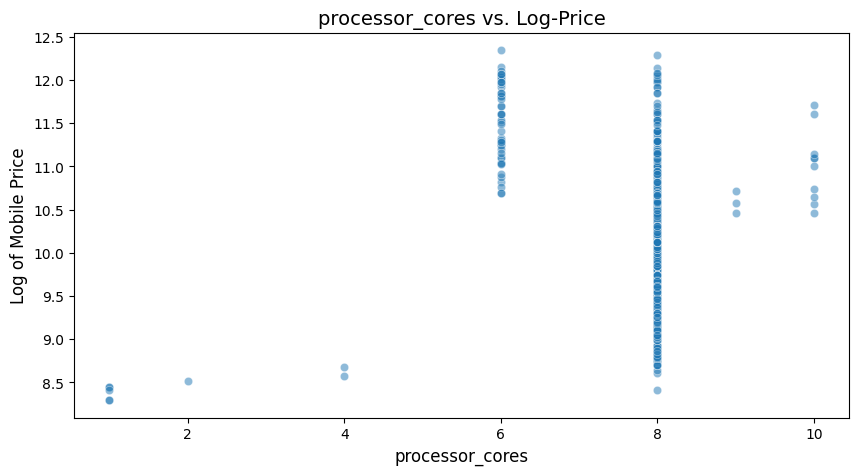

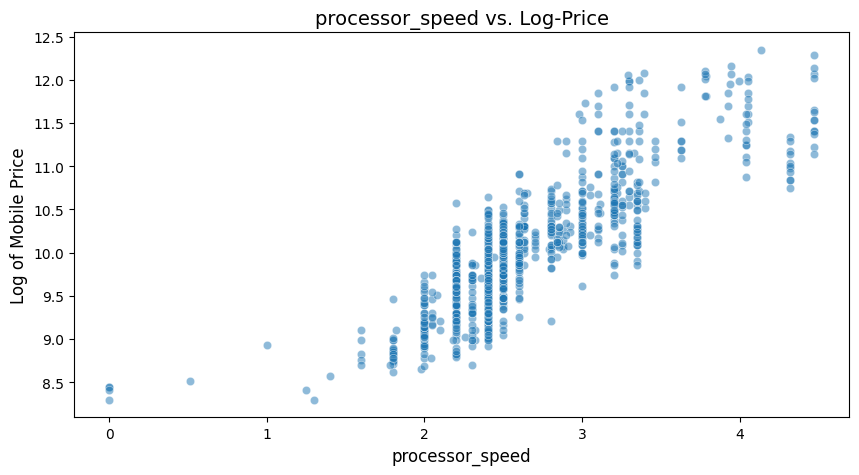

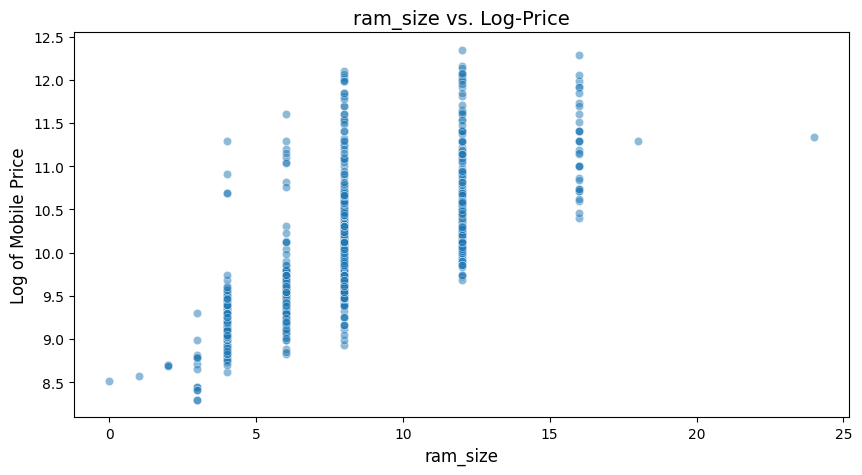

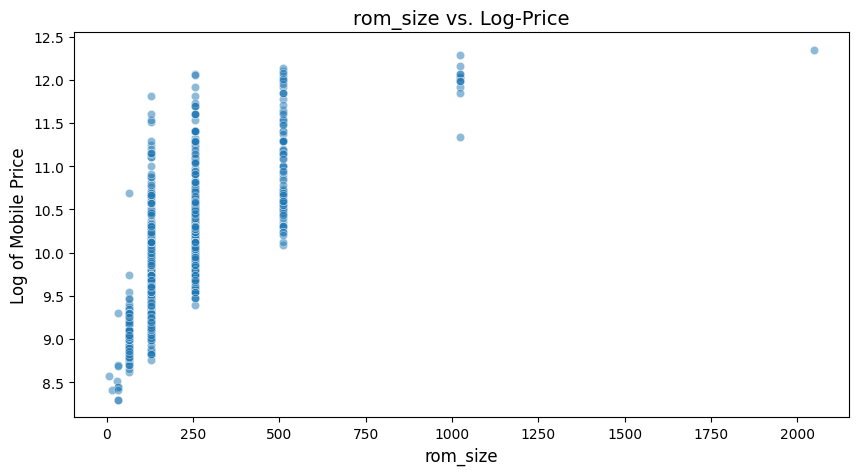

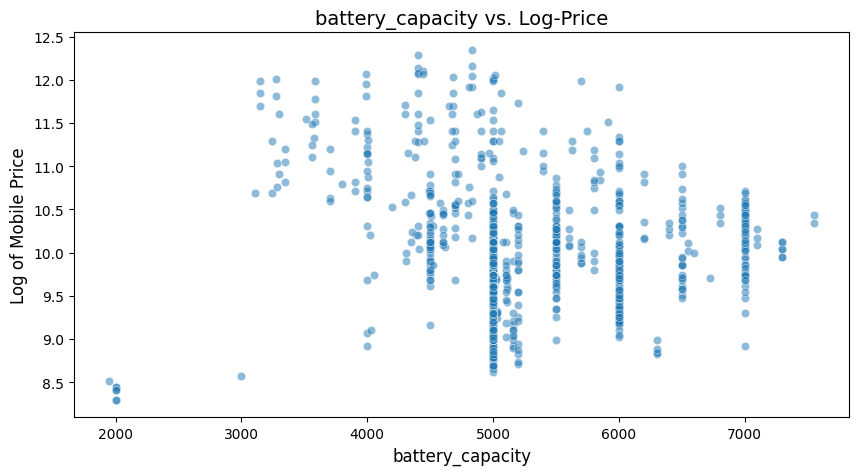

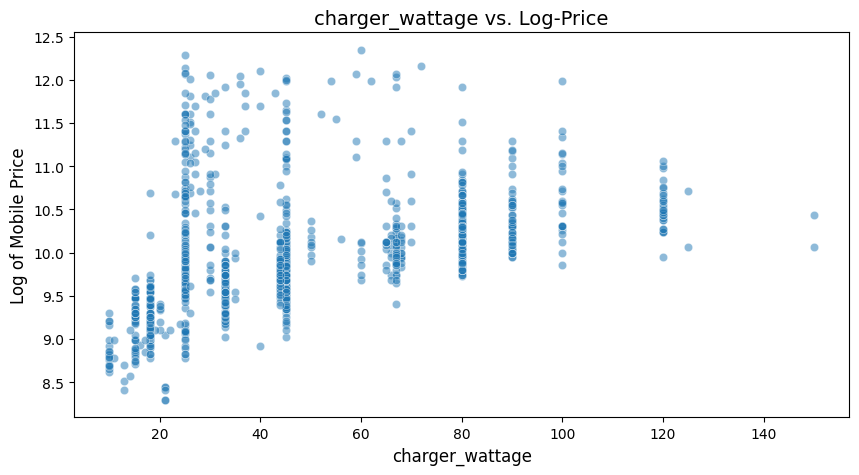

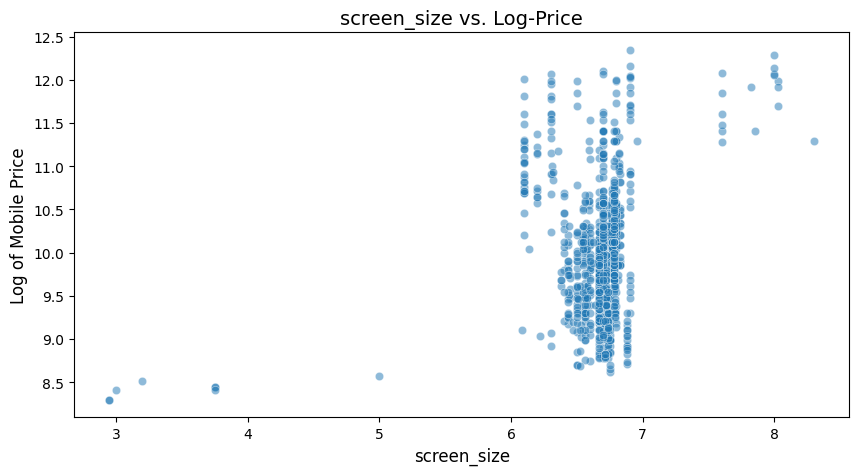

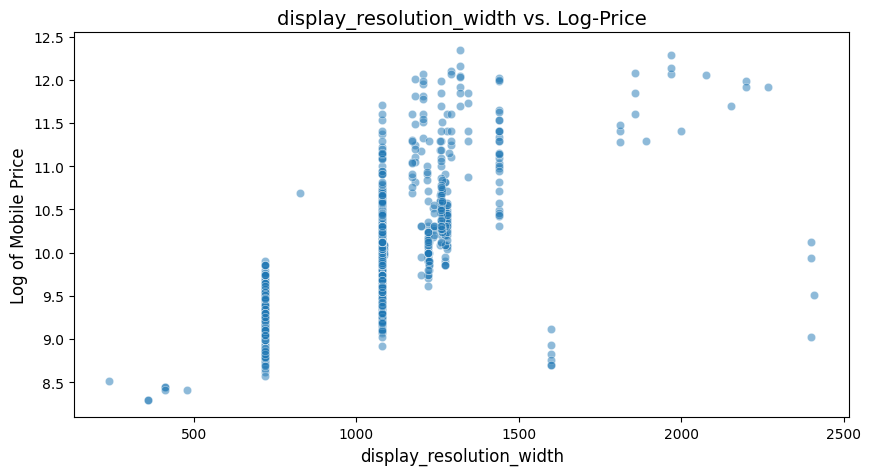

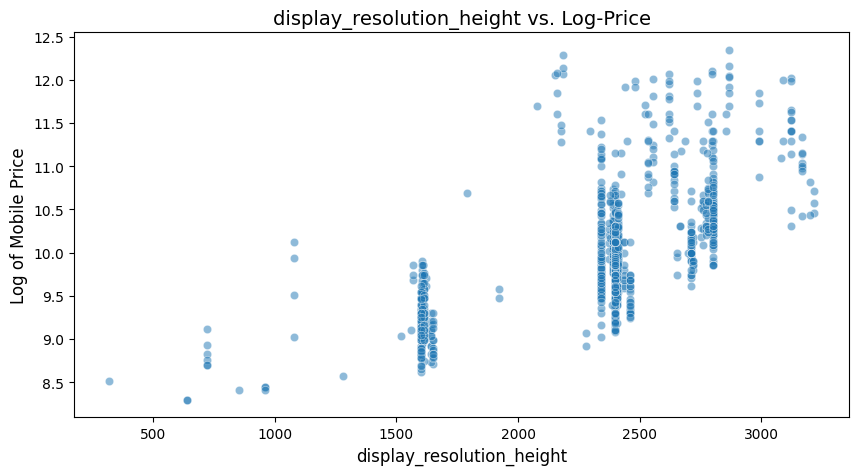

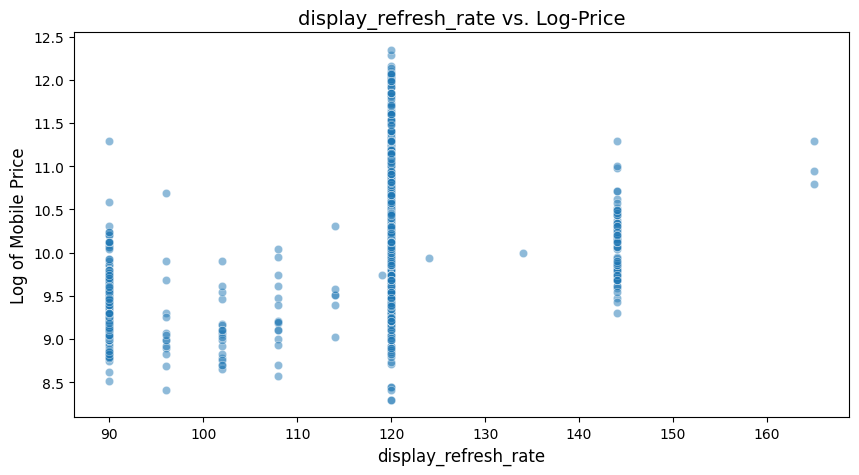

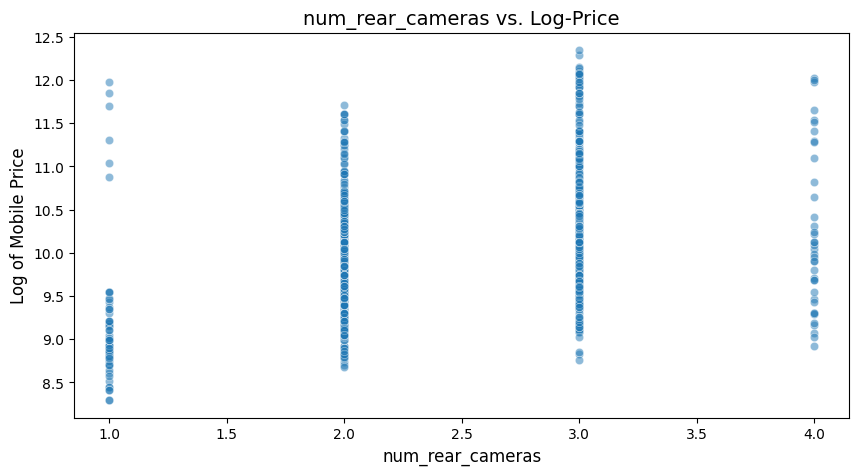

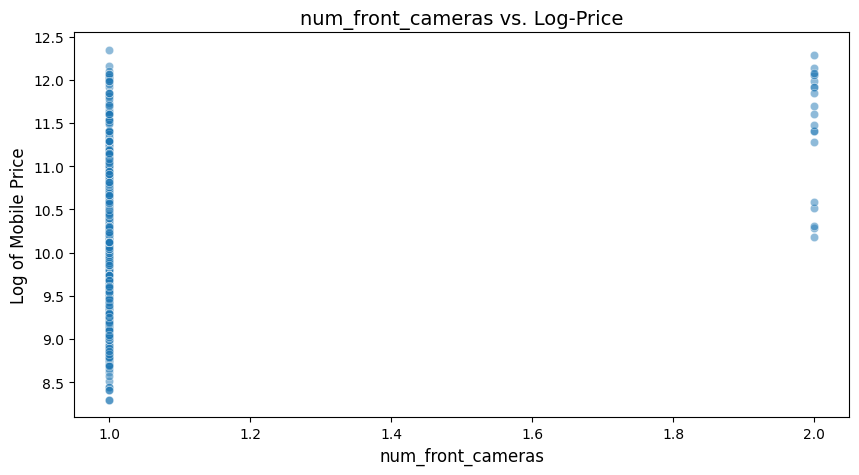

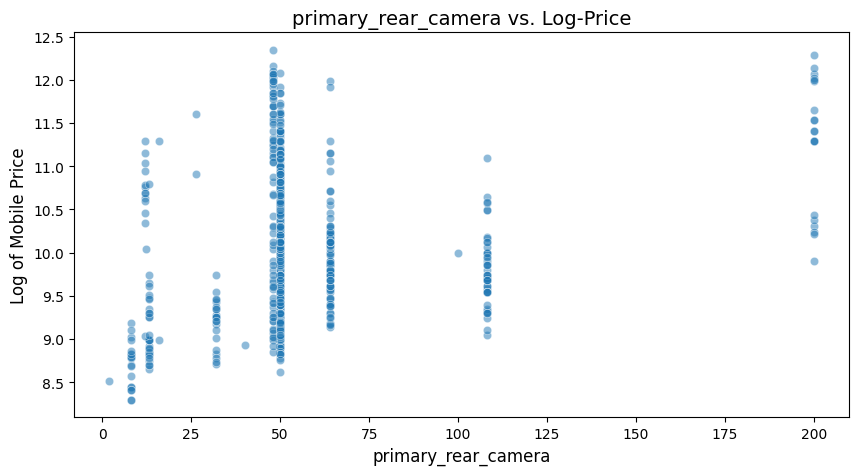

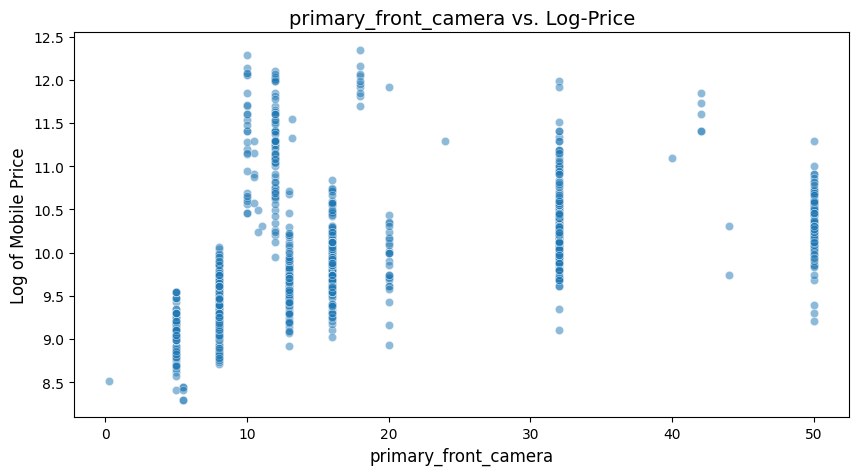

In [104]:

df1_clean['price_log'] = np.log1p(df1_clean['mobile_price'])

# Get our lists of features (excluding targets)
numerical_features = [col for col in numerical_cols if col not in ['mobile_price', 'price_log']]
target = 'mobile_price'
target_log = 'price_log'

# --- 1. Spearman Correlation ---
print("Spearman Correlation with Mobile Price")

# Calculate correlation for all numerical features + price
correlations = df1_clean[numerical_features + [target]].corr(method='spearman')

# Show the correlation of each feature *with the price*
price_corr = correlations[target].sort_values(ascending=False)
print(price_corr)

# --- 2. Scatter Plots (Feature vs. Log-Price) ---
print("\n--- Visualizing Numerical Features vs. Log-Price ---")

for col in numerical_features:
    plt.figure(figsize=(10, 5))
    # We plot against the LOG of price for a clearer view
    sns.scatterplot(
        x=df1_clean[col], 
        y=df1_clean[target_log], 
        alpha=0.5 # Use transparency to see data density
    )
    plt.title(f'{col} vs. Log-Price', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Log of Mobile Price', fontsize=12)
    plt.show()

Spearman Correlation with Mobile Rank
mobile_rank                  1.000000
mobile_price                 0.725522
processor_speed              0.574754
ram_size                     0.554631
rom_size                     0.541635
display_resolution_width     0.482154
display_resolution_height    0.370930
num_rear_cameras             0.283529
num_front_cameras            0.245723
screen_size                  0.242180
display_refresh_rate         0.151394
charger_wattage              0.140325
primary_front_camera         0.136800
primary_rear_camera          0.020447
processor_cores              0.018112
battery_capacity            -0.126729
Name: mobile_rank, dtype: float64

--- Visualizing Numerical Features vs. Log-Price ---


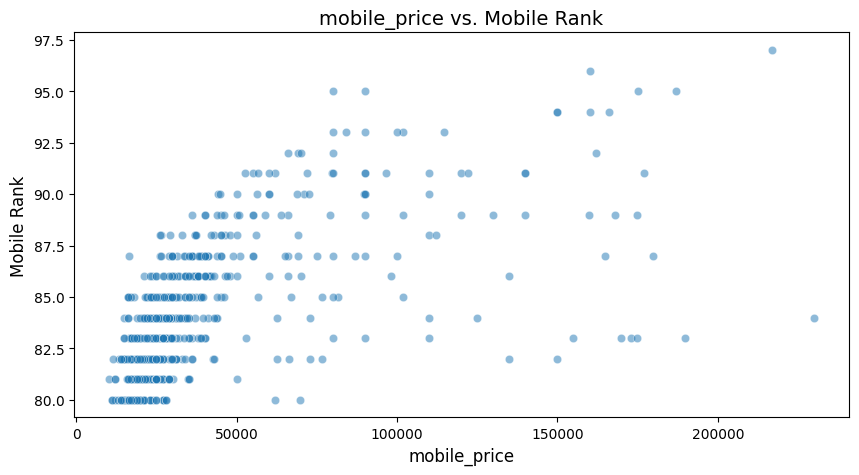

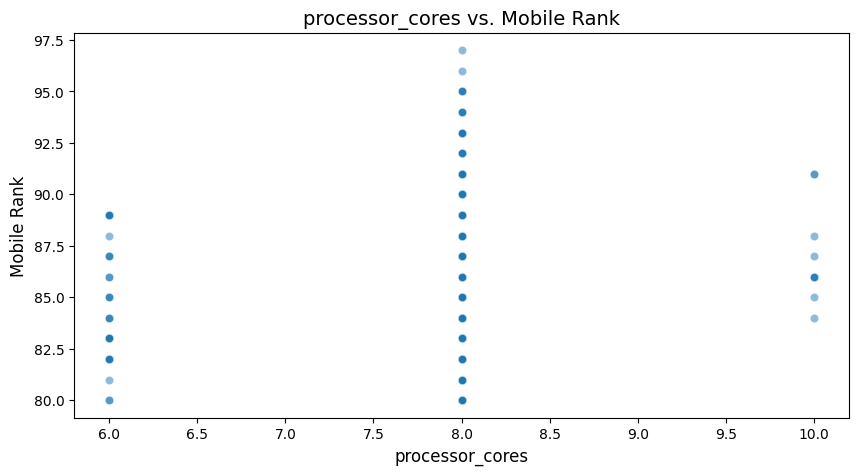

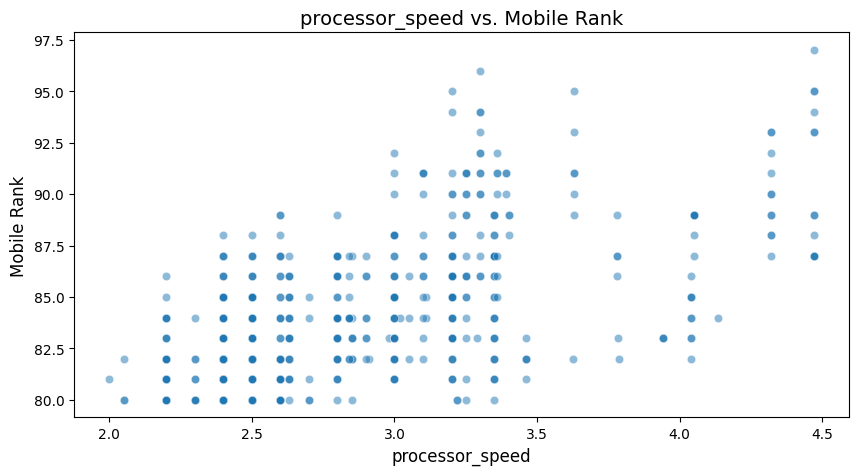

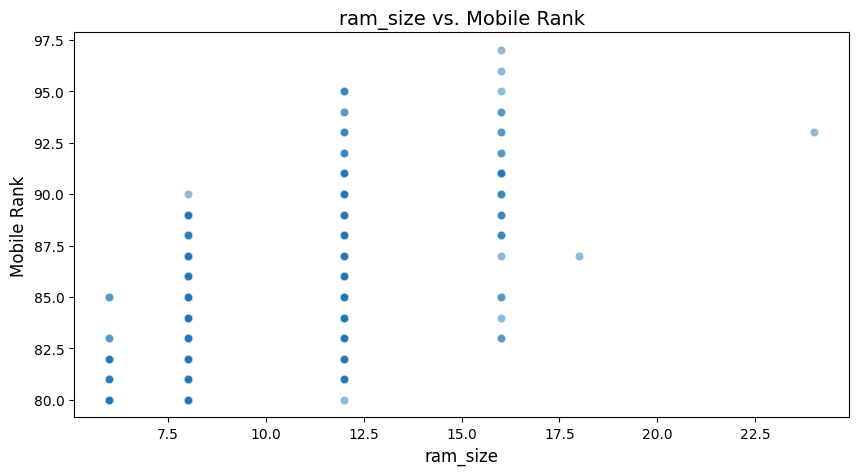

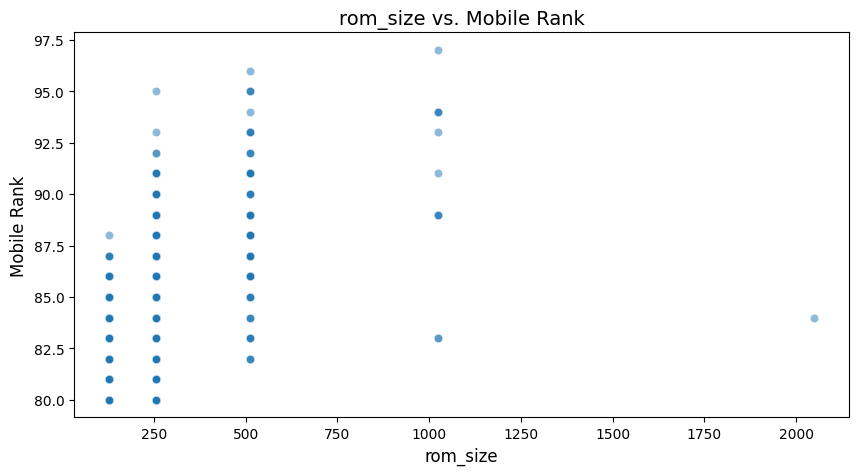

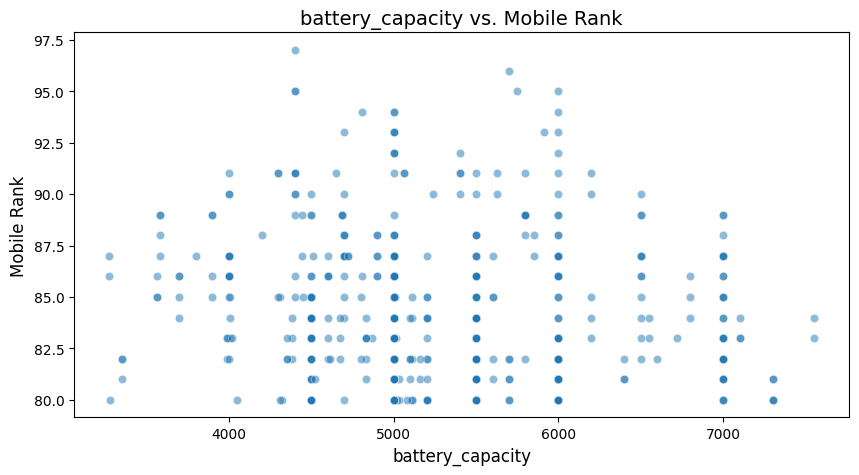

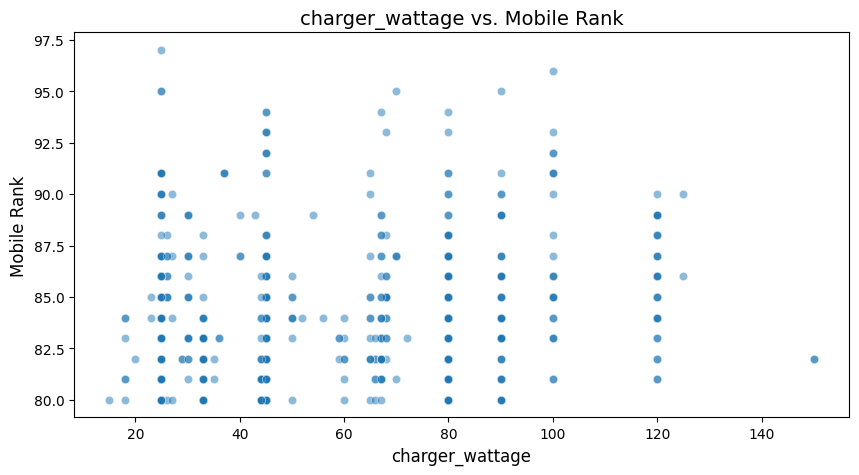

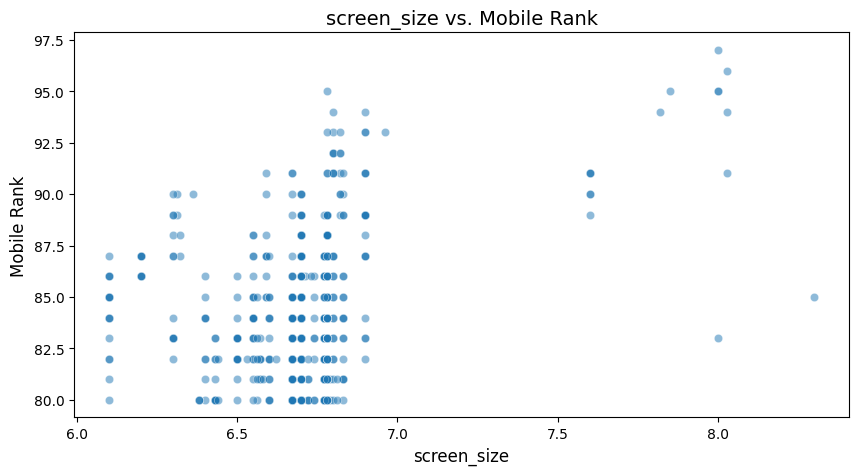

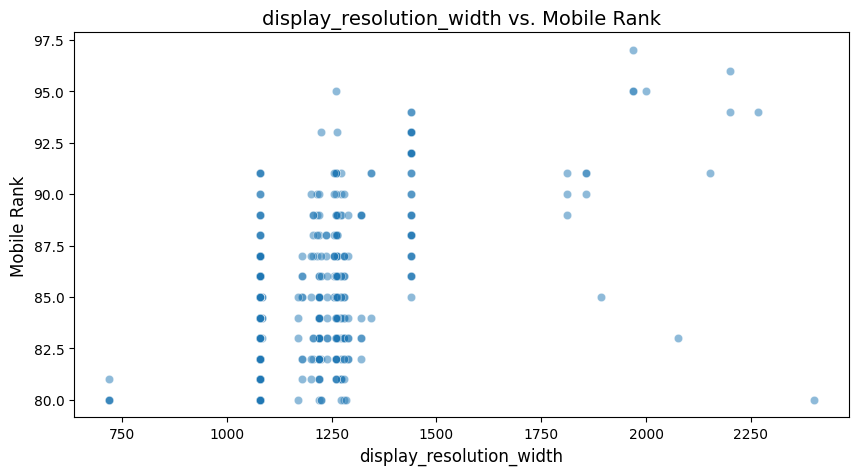

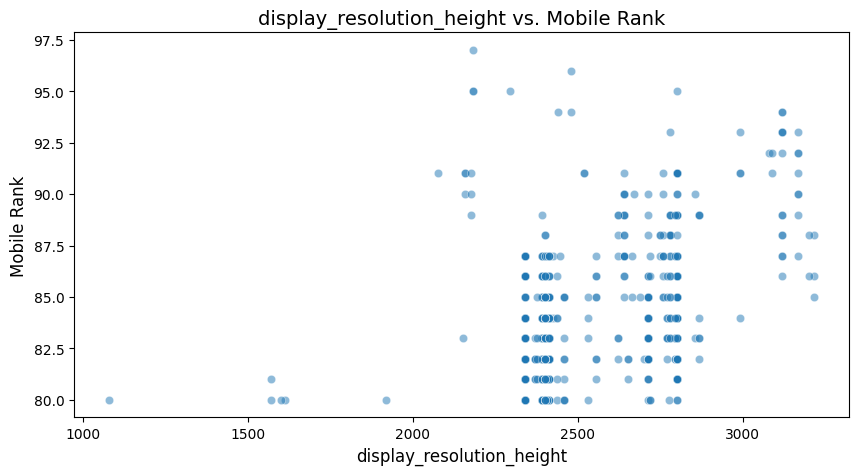

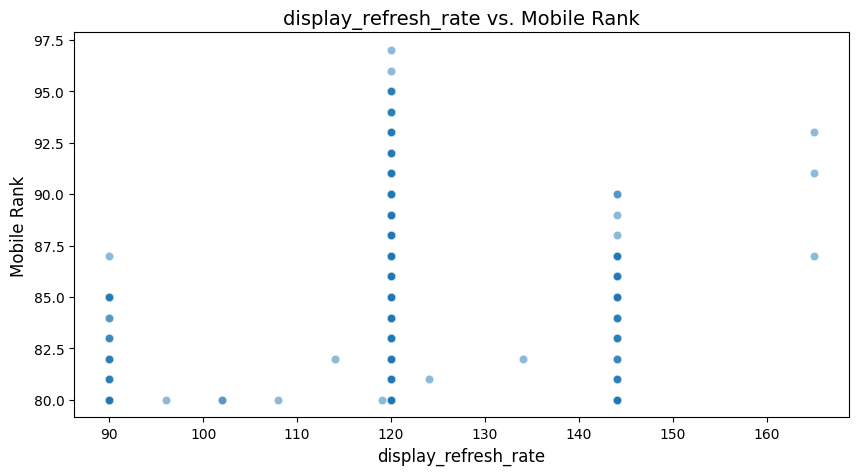

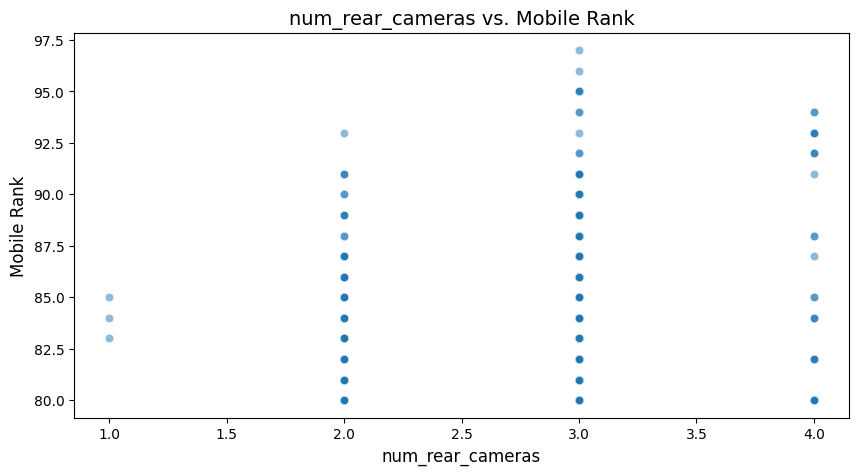

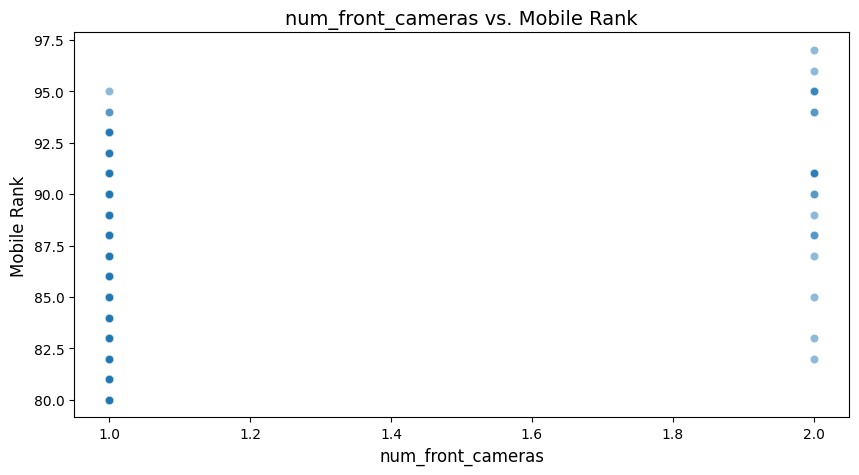

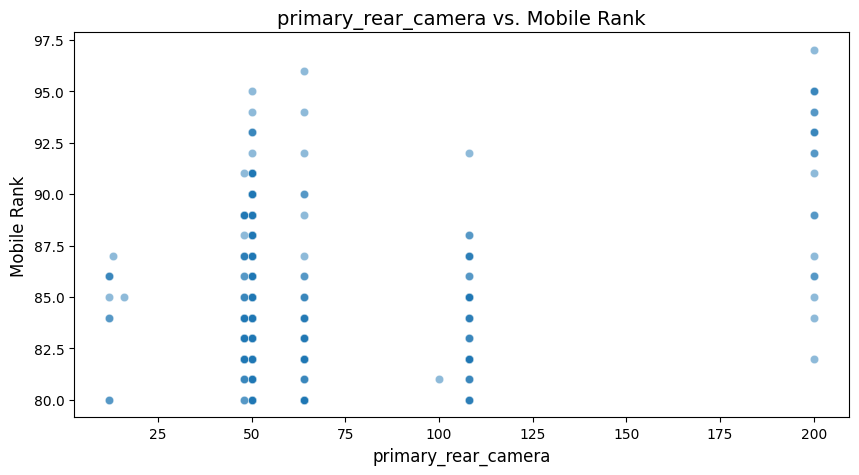

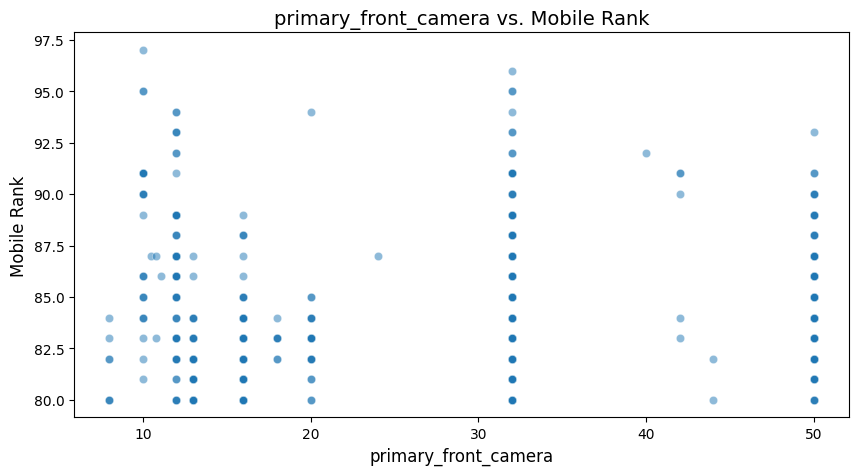

In [105]:

df1_clean['price_log'] = np.log1p(df1_clean['mobile_price'])

# Get our lists of features (excluding targets)
numerical_features = [col for col in numerical_cols if col not in ['mobile_rank']]
target = 'mobile_rank'

# --- 1. Spearman Correlation ---
print("Spearman Correlation with Mobile Rank")

# Calculate correlation for all numerical features + rank
correlations = df1_clean[numerical_features + [target]].corr(method='spearman')

# Show the correlation of each feature *with the price*
price_corr = correlations[target].sort_values(ascending=False)
print(price_corr)

# --- 2. Scatter Plots (Feature vs. Log-Price) ---
print("\n--- Visualizing Numerical Features vs. Log-Price ---")

for col in numerical_features:
    plt.figure(figsize=(10, 5))
    # We plot against the LOG of price for a clearer view
    sns.scatterplot(
        x=df1_clean[col], 
        y=df1_clean[target], 
        alpha=0.5 # Use transparency to see data density
    )
    plt.title(f'{col} vs. Mobile Rank', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Mobile Rank', fontsize=12)
    plt.show()


--- Visualizing Categorical Features vs. Log-Price ---

--- Group-by Summary for brand_name vs. Price ---
            count           mean           std      min       25%       50%  \
brand_name                                                                    
acer          3.0   10326.333333   1377.882554   9290.0   9544.50    9799.0   
ai+           4.0    7499.000000   1683.250823   5499.0   6624.00    7499.0   
alcatel       5.0   13599.000000   2701.851217   9999.0  11999.00   13999.0   
apple        45.0  110000.666667  47361.957209  43900.0  69900.00  102900.0   
asus          1.0   79999.000000           NaN  79999.0  79999.00   79999.0   
blackzone     2.0    6049.000000   2192.031022   4499.0   5274.00    6049.0   
cmf           4.0   17667.250000   1685.039342  15401.0  16877.00   18134.5   
google       21.0   68371.095238  43735.916003  22999.0  34999.00   52999.0   
hmd           6.0   13832.333333  11125.046816   4999.0   9249.00   10499.0   
honor         6.0   2309

C:\Users\asus\AppData\Local\Temp\ipykernel_11560\1507897682.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


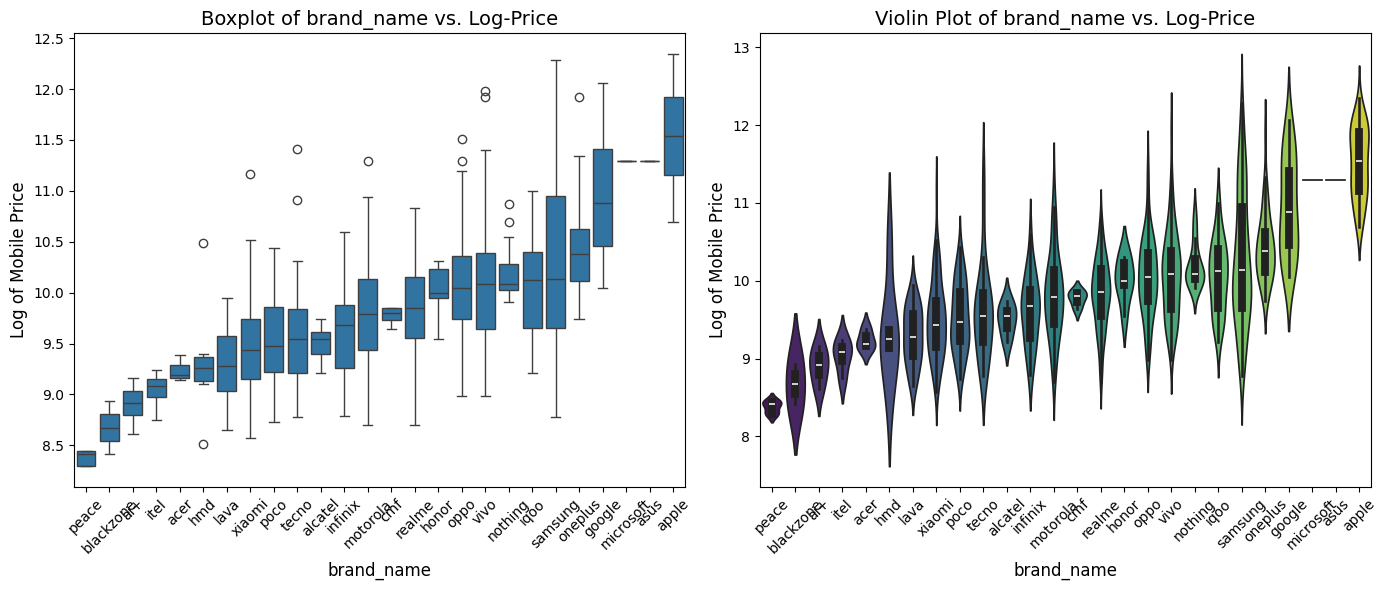


--- Group-by Summary for has_5g vs. Price ---
        count          mean           std     min      25%      50%      75%  \
has_5g                                                                         
False   113.0   9635.973451   5064.877580  3999.0   6799.0   8499.0  10490.0   
True    839.0  33653.386174  33076.935559  7299.0  15499.0  22999.0  35532.0   

             max  
has_5g            
False    43900.0  
True    229900.0  


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\1507897682.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


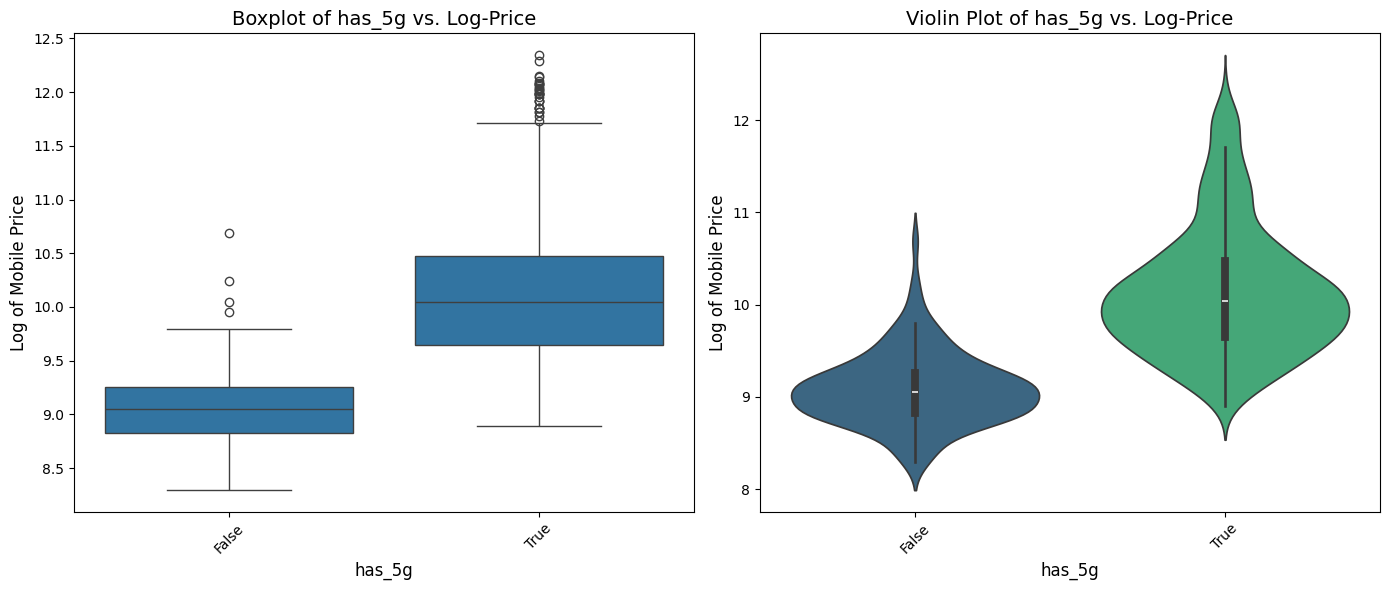


--- Group-by Summary for has_nfc vs. Price ---
         count          mean           std     min      25%      50%  \
has_nfc                                                                
False    540.0  16902.320370   8243.467088  3999.0  10499.0  14999.0   
True     412.0  49021.366505  41252.974843  7600.0  21999.0  33989.0   

              75%       max  
has_nfc                      
False    20999.00   47999.0  
True     61924.75  229900.0  


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\1507897682.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


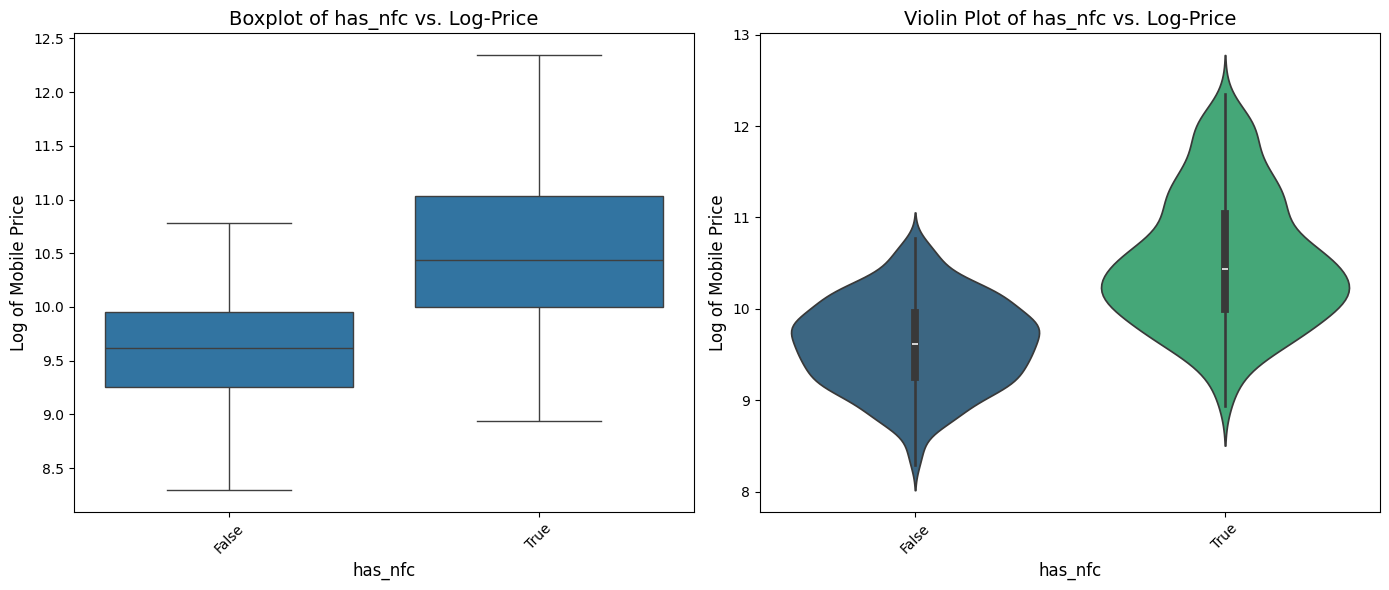


--- Group-by Summary for has_ir vs. Price ---
        count          mean           std     min       25%      50%  \
has_ir                                                                 
False   686.0  31833.930029  35360.307536  3999.0  12999.00  19499.0   
True    266.0  28142.781955  21106.964490  6499.0  14998.25  23845.0   

             75%       max  
has_ir                      
False   30996.75  229900.0  
True    33999.00  159999.0  


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\1507897682.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


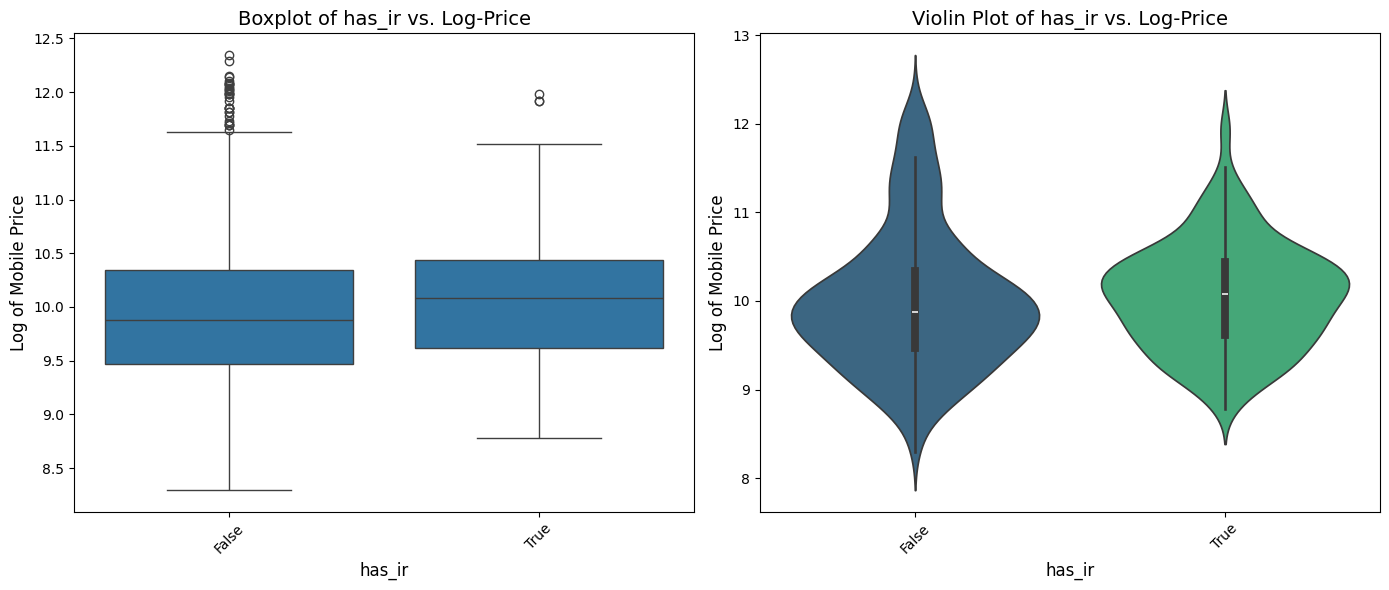


--- Group-by Summary for processor_brand vs. Price ---
                 count           mean           std      min        25%  \
processor_brand                                                           
a13                1.0   43900.000000           NaN  43900.0   43900.00   
apple             12.0  150816.666667  39384.949440  82900.0  131150.00   
bionic            32.0   96760.312500  40824.340939  43900.0   65417.25   
dimensit           1.0   24990.000000           NaN  24990.0   24990.00   
dimensity        391.0   21596.772379  13153.268107   7499.0   13490.50   
exynos            62.0   30493.629032  22998.619510   9699.0   17124.00   
google             4.0   27621.750000   6014.892926  22999.0   23374.00   
helio             53.0    9138.113208   3112.530634   3999.0    6799.00   
sc9863a            1.0    8999.000000           NaN   8999.0    8999.00   
snapdragon       339.0   34783.436578  31852.863982   5299.0   17249.00   
tensor            17.0   77959.176471  43260

C:\Users\asus\AppData\Local\Temp\ipykernel_11560\1507897682.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


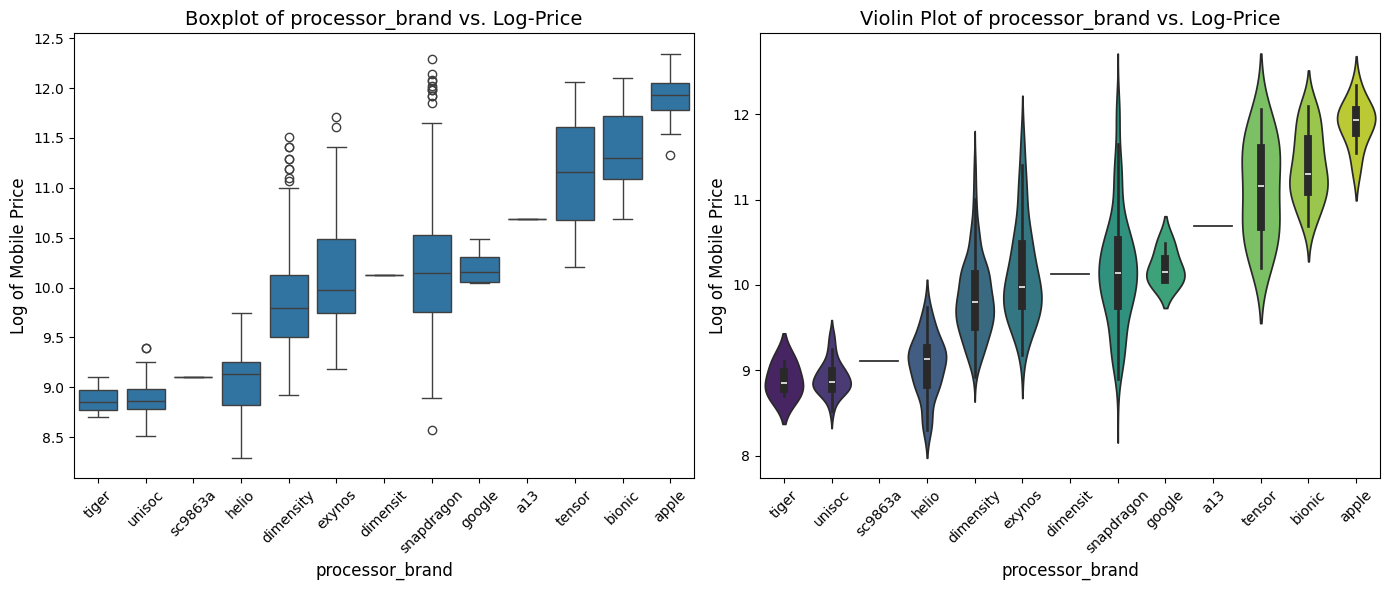


--- Group-by Summary for memory_card_support vs. Price ---
                     count          mean           std      min       25%  \
memory_card_support                                                         
False                222.0  55811.211712  43487.372664  11844.0  25984.75   
True                 730.0  23197.215068  22775.400444   3999.0  11839.50   

                         50%      75%       max  
memory_card_support                              
False                38802.0  68400.0  229900.0  
True                 16999.0  24999.0  216999.0  


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\1507897682.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


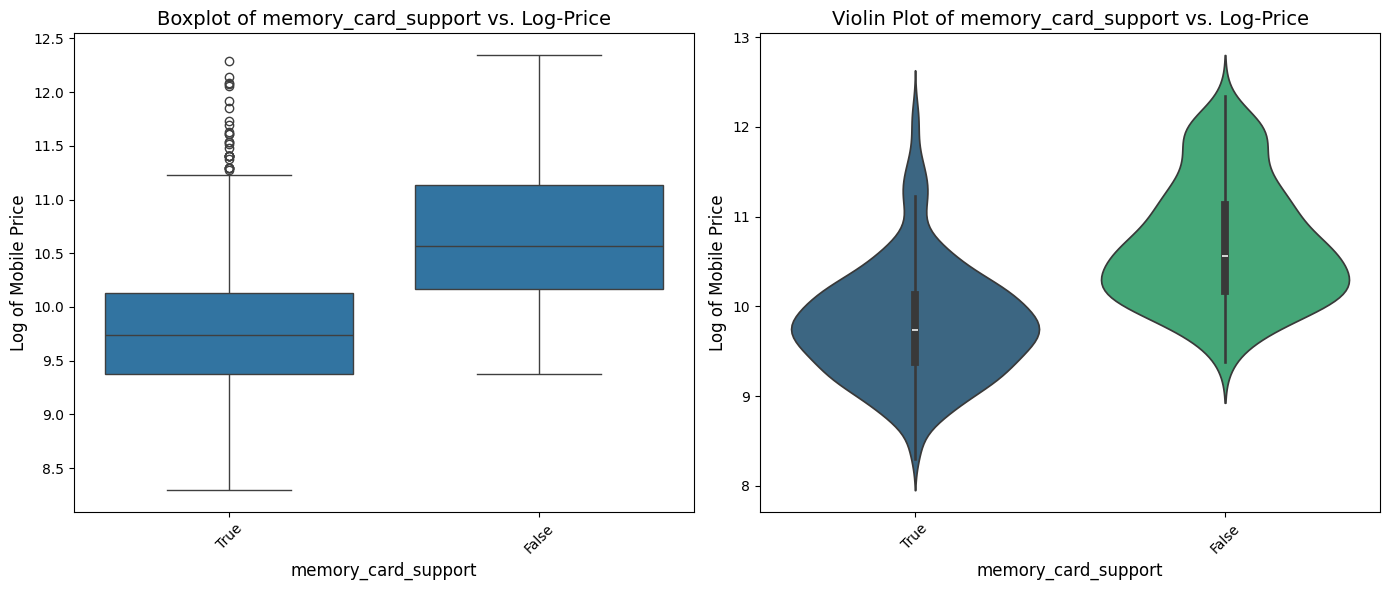

C:\Users\asus\AppData\Local\Temp\ipykernel_11560\1507897682.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df1_clean.groupby(col)[target].describe())
C:\Users\asus\AppData\Local\Temp\ipykernel_11560\1507897682.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_order = df1_clean.groupby(col)[target].median().sort_values().index



--- Group-by Summary for os_category vs. Price ---
             count           mean           std      min      25%       50%  \
os_category                                                                   
Android      884.0   25903.808824  23927.219710   3999.0  12999.0   19494.0   
Other         23.0   64133.000000  44677.382806   4999.0  38699.0   54999.0   
iOS           45.0  110000.666667  47361.957209  43900.0  69900.0  102900.0   

                  75%       max  
os_category                      
Android       28999.0  216999.0  
Other         84999.0  159999.0  
iOS          149900.0  229900.0  


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\1507897682.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


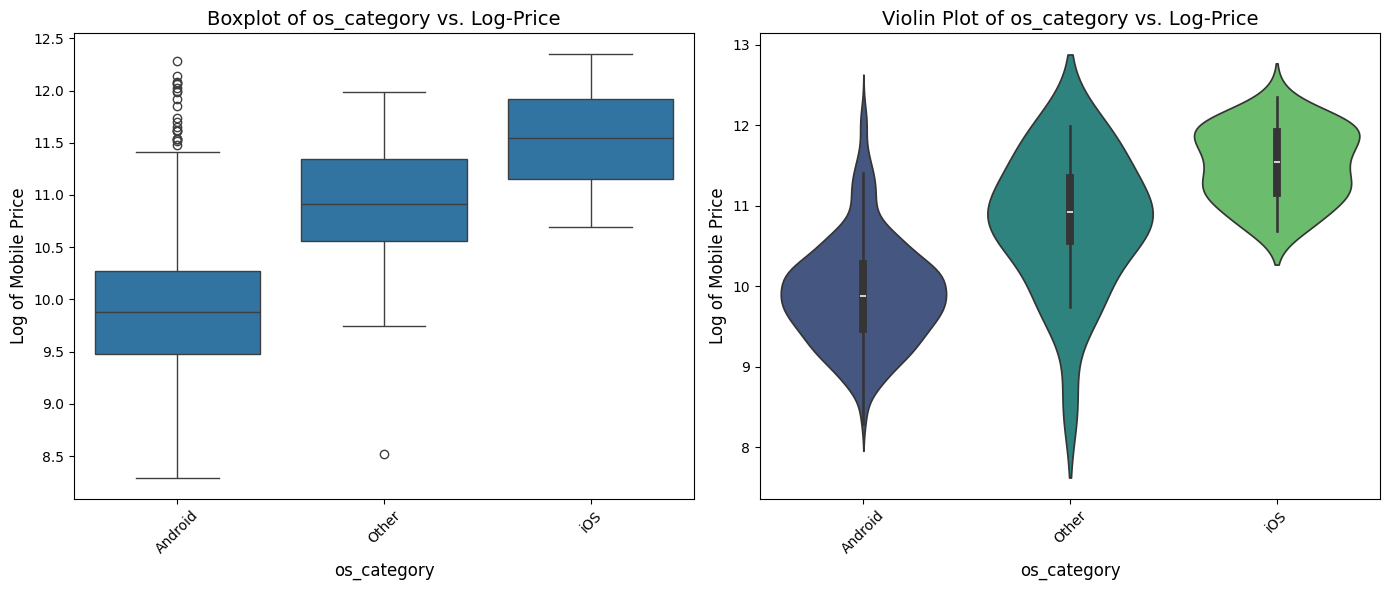

In [106]:
categorical_features = [col for col in categorical_cols if col not in ['mobile_name']]

target = 'mobile_price'
target_log = 'price_log'

print("\n--- Visualizing Categorical Features vs. Log-Price ---")

for col in categorical_features:
    # --- 1. Group-by Summaries ---
    print(f"\n--- Group-by Summary for {col} vs. Price ---")
    # We use the *original* price for .describe() to see real monetary values
    print(df1_clean.groupby(col)[target].describe())

    # --- 2. Boxplots / Violin Plots ---
    # Find the order based on median price
    median_order = df1_clean.groupby(col)[target].median().sort_values().index
    
    plt.figure(figsize=(14, 6))
    
    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(
        x=df1_clean[col], 
        y=df1_clean[target_log], 
        order=median_order
    )
    plt.title(f'Boxplot of {col} vs. Log-Price', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Log of Mobile Price', fontsize=12)
    plt.xticks(rotation=45)
    
    # Violin Plot
    plt.subplot(1, 2, 2)
    sns.violinplot(
        x=df1_clean[col], 
        y=df1_clean[target_log], 
        order=median_order,
        palette='viridis'
    )
    plt.title(f'Violin Plot of {col} vs. Log-Price', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Log of Mobile Price', fontsize=12)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


--- Visualizing Categorical Features vs. Mobile Rank ---

--- Group-by Summary for brand_name vs. Mobile Rank ---
            count       mean       std   min    25%   50%    75%   max
brand_name                                                            
acer          0.0        NaN       NaN   NaN    NaN   NaN    NaN   NaN
ai+           0.0        NaN       NaN   NaN    NaN   NaN    NaN   NaN
alcatel       3.0  82.666667  2.516611  80.0  81.50  83.0  84.00  85.0
apple        34.0  84.588235  2.829687  80.0  82.25  84.0  87.00  89.0
asus          1.0  87.000000       NaN  87.0  87.00  87.0  87.00  87.0
blackzone     0.0        NaN       NaN   NaN    NaN   NaN    NaN   NaN
cmf           3.0  82.333333  2.081666  80.0  81.50  83.0  83.50  84.0
google       14.0  86.142857  3.370851  82.0  83.25  85.0  89.25  91.0
hmd           3.0  82.333333  4.041452  80.0  80.00  80.0  83.50  87.0
honor         5.0  83.400000  2.509980  81.0  82.00  82.0  85.00  87.0
infinix      12.0  84.666667  2.3

C:\Users\asus\AppData\Local\Temp\ipykernel_11560\607122917.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


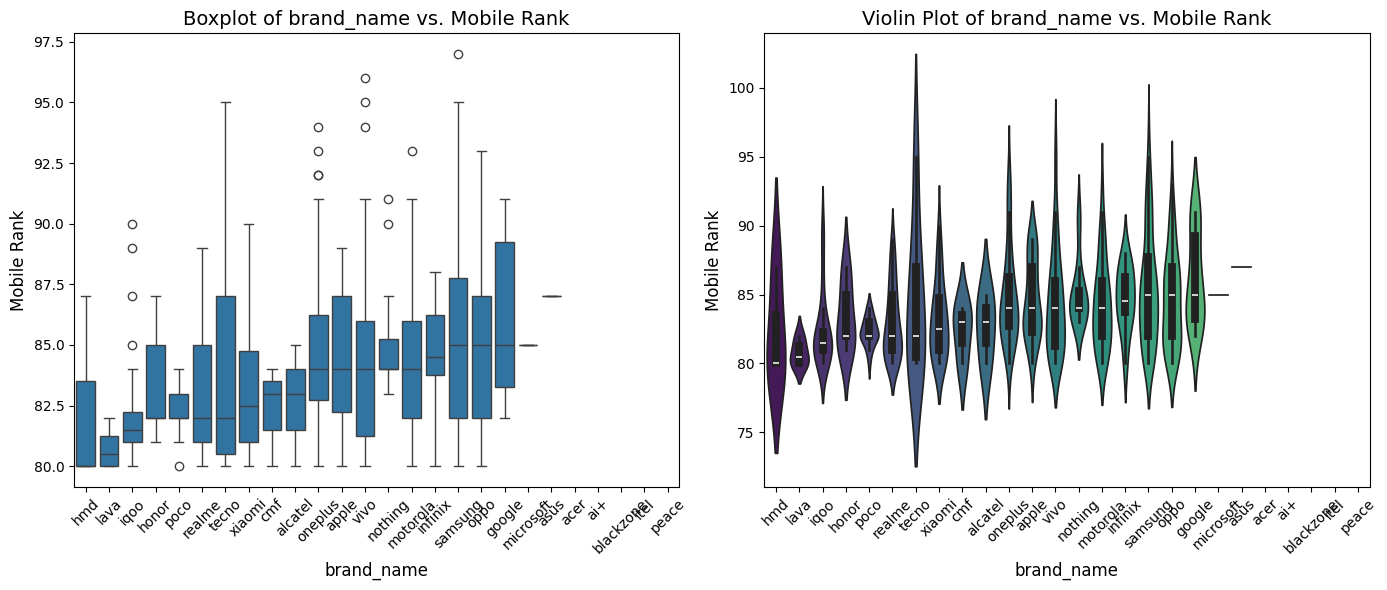


--- Group-by Summary for has_5g vs. Mobile Rank ---
        count       mean       std   min   25%   50%   75%   max
has_5g                                                          
False     9.0  80.888889  1.452966  80.0  80.0  80.0  82.0  84.0
True    555.0  84.335135  3.442059  80.0  82.0  84.0  86.0  97.0


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\607122917.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


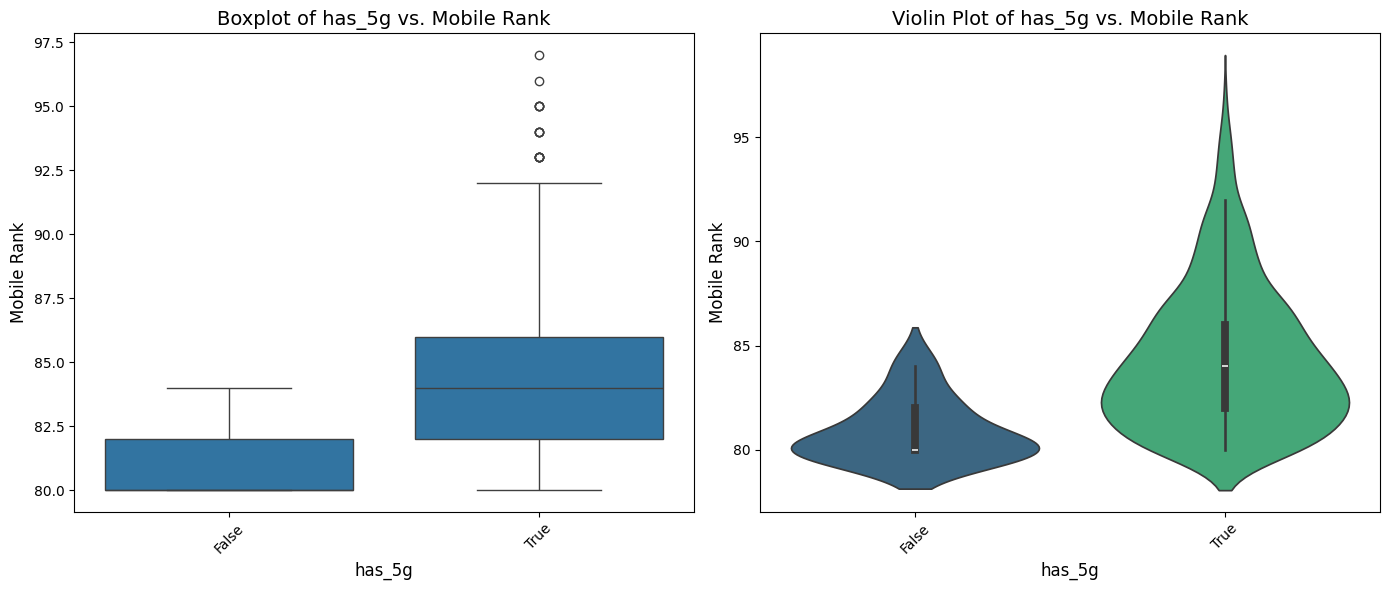


--- Group-by Summary for has_nfc vs. Mobile Rank ---
         count       mean       std   min   25%   50%   75%   max
has_nfc                                                          
False    204.0  81.946078  1.870706  80.0  80.0  82.0  83.0  88.0
True     360.0  85.602778  3.434301  80.0  83.0  85.0  87.0  97.0


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\607122917.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


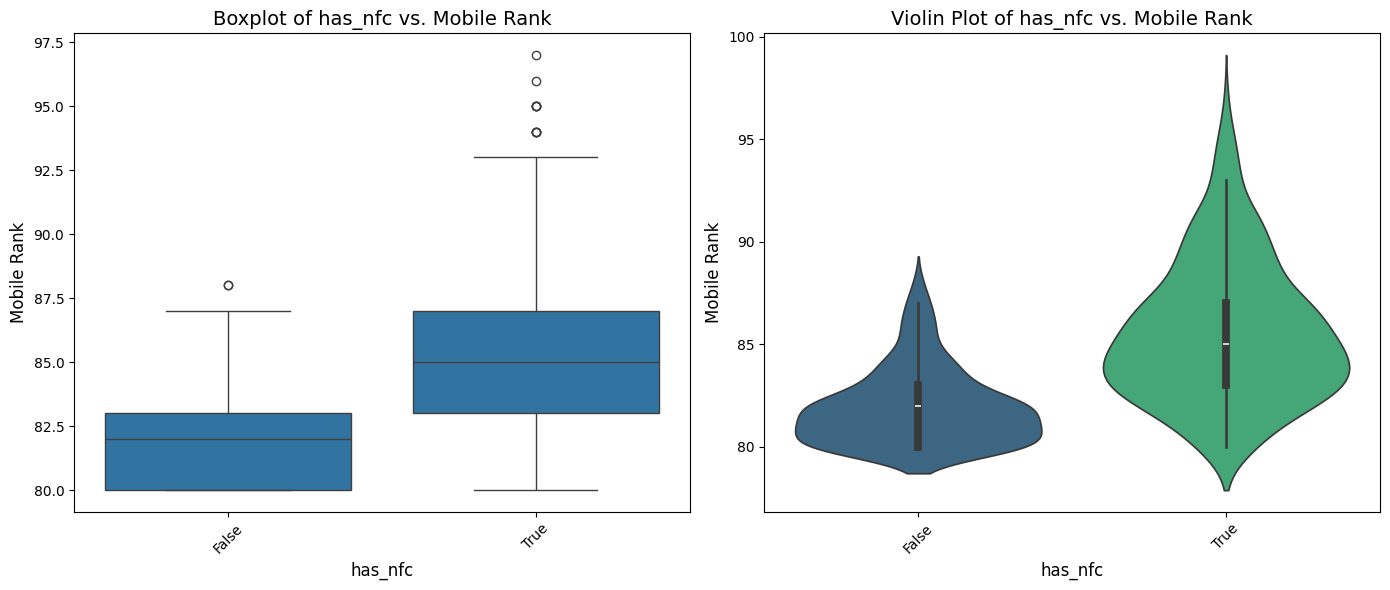


--- Group-by Summary for has_ir vs. Mobile Rank ---
        count       mean       std   min   25%   50%   75%   max
has_ir                                                          
False   388.0  84.028351  3.337473  80.0  82.0  83.0  86.0  97.0
True    176.0  84.835227  3.622329  80.0  82.0  84.0  87.0  96.0


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\607122917.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


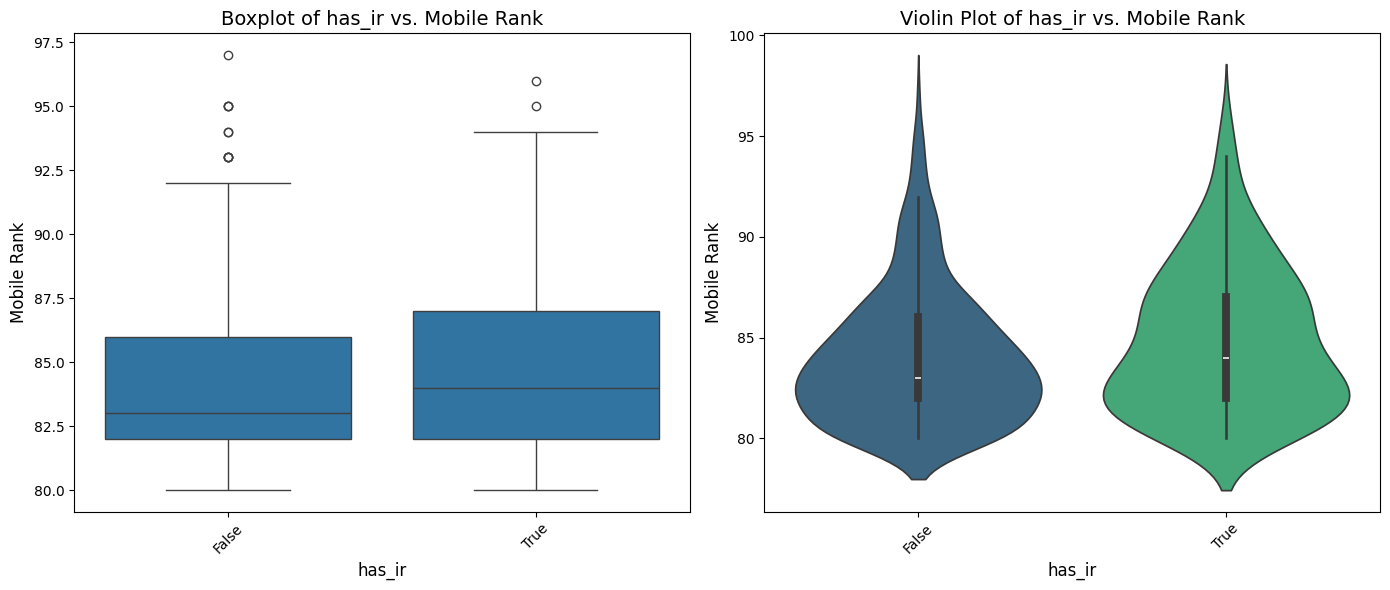


--- Group-by Summary for processor_brand vs. Mobile Rank ---
                 count       mean       std   min    25%   50%    75%   max
processor_brand                                                            
a13                0.0        NaN       NaN   NaN    NaN   NaN    NaN   NaN
apple              7.0  82.857143  0.690066  82.0  82.50  83.0  83.00  84.0
bionic            27.0  85.037037  3.006167  80.0  82.50  85.0  87.50  89.0
dimensit           1.0  81.000000       NaN  81.0  81.00  81.0  81.00  81.0
dimensity        211.0  83.672986  3.188100  80.0  81.00  83.0  85.50  95.0
exynos            46.0  83.543478  2.911331  80.0  81.25  83.0  85.75  91.0
google             3.0  84.000000  2.645751  82.0  82.50  83.0  85.00  87.0
helio              4.0  80.500000  1.000000  80.0  80.00  80.0  80.50  82.0
sc9863a            0.0        NaN       NaN   NaN    NaN   NaN    NaN   NaN
snapdragon       252.0  84.880952  3.687185  80.0  82.00  84.0  87.00  97.0
tensor            11.0  86

C:\Users\asus\AppData\Local\Temp\ipykernel_11560\607122917.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


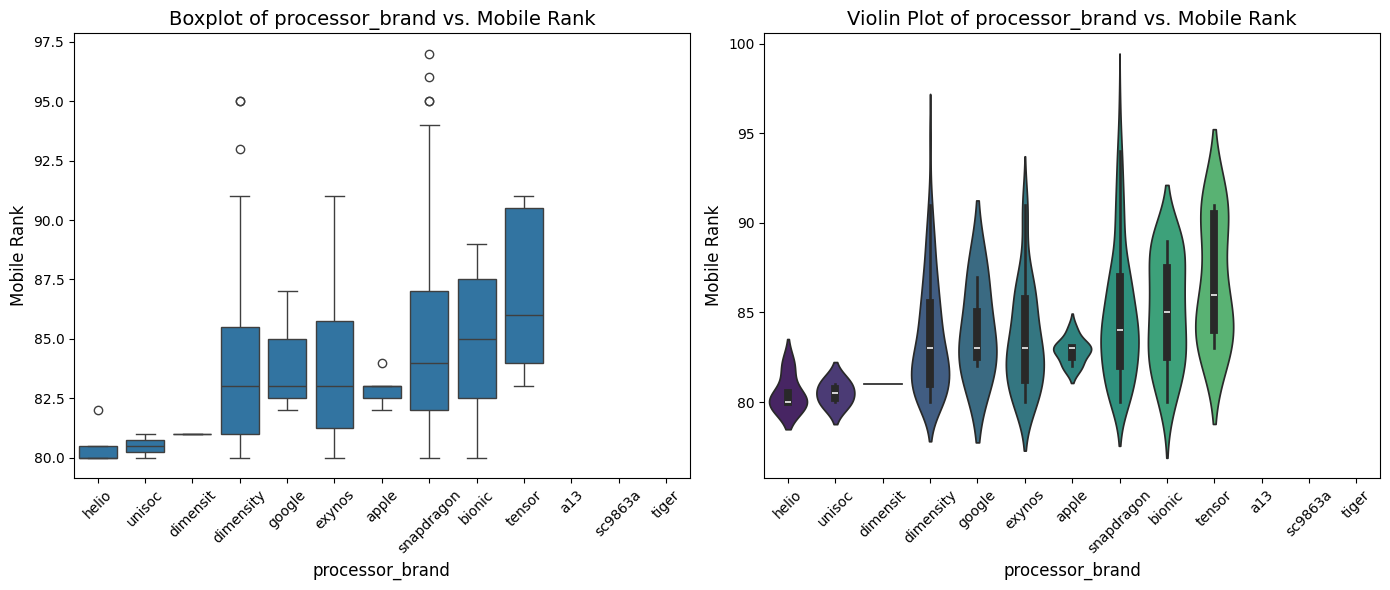


--- Group-by Summary for memory_card_support vs. Mobile Rank ---
                     count       mean       std   min   25%   50%   75%   max
memory_card_support                                                          
False                194.0  85.525773  3.626594  80.0  83.0  85.0  88.0  96.0
True                 370.0  83.627027  3.161648  80.0  81.0  83.0  85.0  97.0


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\607122917.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


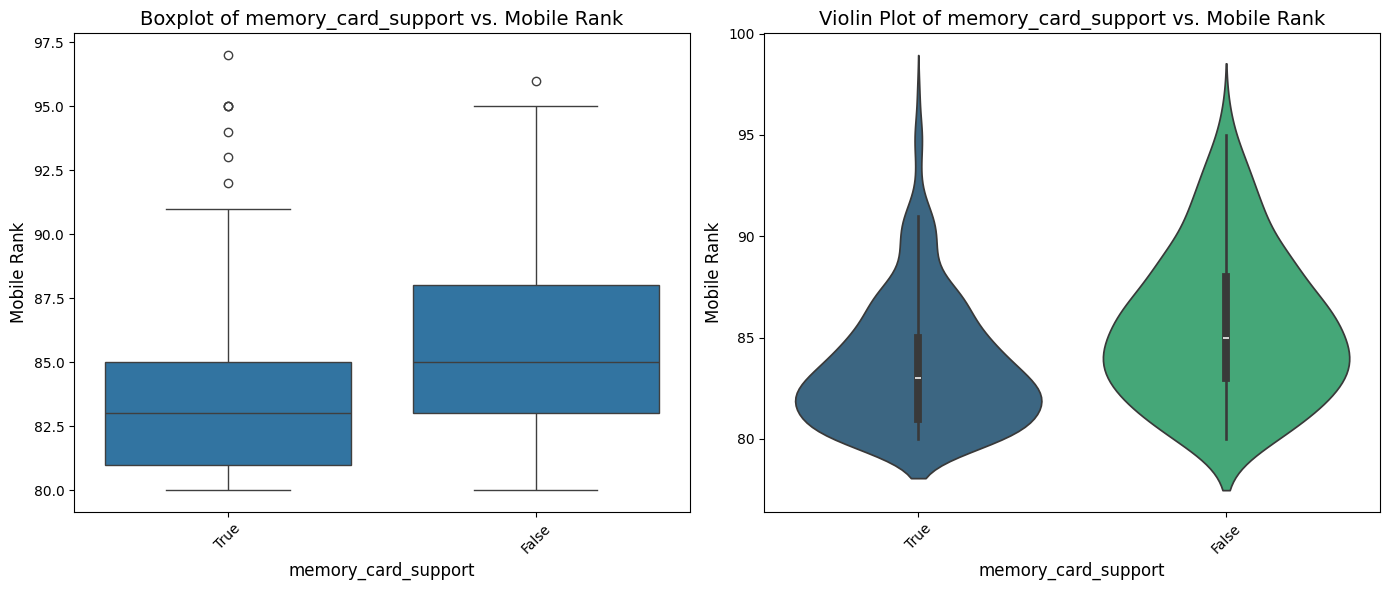

C:\Users\asus\AppData\Local\Temp\ipykernel_11560\607122917.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df1_clean.groupby(col)[target].describe())
C:\Users\asus\AppData\Local\Temp\ipykernel_11560\607122917.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_order = df1_clean.groupby(col)[target].median().sort_values().index



--- Group-by Summary for os_category vs. Mobile Rank ---
             count       mean       std   min    25%   50%   75%   max
os_category                                                           
Android      510.0  84.086275  3.358771  80.0  82.00  83.0  86.0  97.0
Other         20.0  88.700000  3.743064  81.0  86.75  89.0  91.0  96.0
iOS           34.0  84.588235  2.829687  80.0  82.25  84.0  87.0  89.0


C:\Users\asus\AppData\Local\Temp\ipykernel_11560\607122917.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


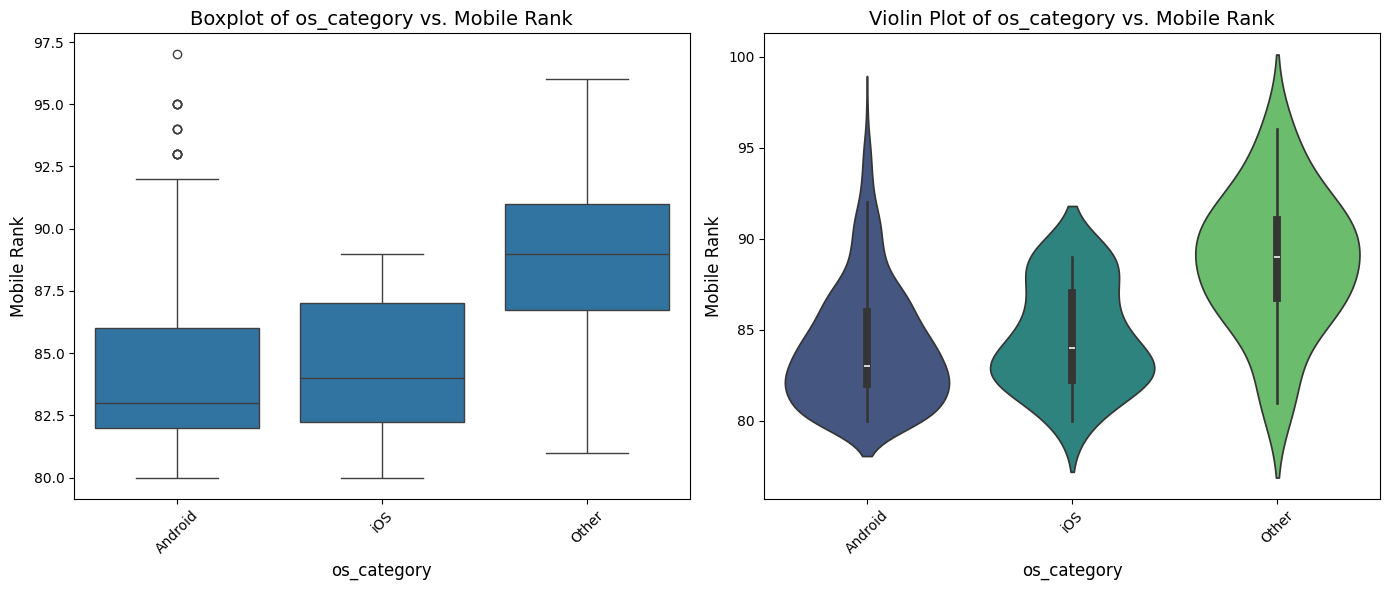

In [107]:
categorical_features = [col for col in categorical_cols if col not in ['mobile_name']]

print("\n--- Visualizing Categorical Features vs. Mobile Rank ---")
target = 'mobile_rank'

for col in categorical_features:
    # --- 1. Group-by Summaries ---
    print(f"\n--- Group-by Summary for {col} vs. Mobile Rank ---")
    # We use the *original* price for .describe() to see real monetary values
    print(df1_clean.groupby(col)[target].describe())

    # --- 2. Boxplots / Violin Plots ---
    # Find the order based on median price
    median_order = df1_clean.groupby(col)[target].median().sort_values().index
    
    plt.figure(figsize=(14, 6))
    
    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(
        x=df1_clean[col], 
        y=df1_clean[target], 
        order=median_order
    )
    plt.title(f'Boxplot of {col} vs. Mobile Rank', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Mobile Rank', fontsize=12)
    plt.xticks(rotation=45)
    
    # Violin Plot
    plt.subplot(1, 2, 2)
    sns.violinplot(
        x=df1_clean[col], 
        y=df1_clean[target], 
        order=median_order,
        palette='viridis'
    )
    plt.title(f'Violin Plot of {col} vs. Mobile Rank', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Mobile Rank', fontsize=12)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


--- Analyzing Categorical vs. Categorical ---

--- Crosstab for processor_brand vs. os_category ---
os_category      Android  Other  iOS
processor_brand                     
a13                    0      0    1
apple                  0      0   12
bionic                 0      0   32
dimensit               1      0    0
dimensity            382      9    0
exynos                59      3    0
google                 4      0    0
helio                 53      0    0
sc9863a                1      0    0
snapdragon           329     10    0
tensor                17      0    0
tiger                  3      0    0
unisoc                34      1    0

--- Stacked Bar Plot ---


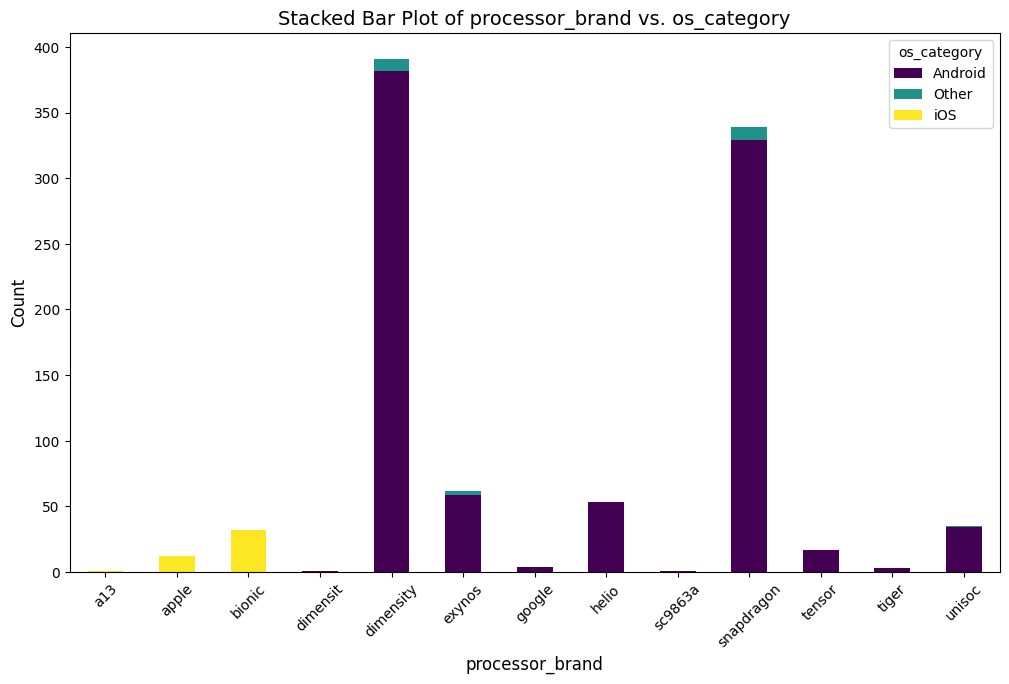


--- Chi-Square Test for processor_brand vs. os_category ---
Chi-Square Statistic: 954.90
P-value: 3.331595472362629e-186
Result: The variables are DEPENDENT (p < 0.05).


In [108]:
from scipy.stats import chi2_contingency

print("\n--- Analyzing Categorical vs. Categorical ---")

c1 = 'processor_brand'
c2 = 'os_category'

# --- 1. Crosstab Analysis (Contingency Table) ---
print(f"\n--- Crosstab for {c1} vs. {c2} ---")
crosstab = pd.crosstab(df1_clean[c1], df1_clean[c2])
print(crosstab)

# --- 2. Stacked Bar Plot ---
print("\n--- Stacked Bar Plot ---")
crosstab.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title(f'Stacked Bar Plot of {c1} vs. {c2}', fontsize=14)
plt.xlabel(c1, fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()
# --- 3. Chi-Square Test of Independence ---
chi2, p, dof, expected = chi2_contingency(crosstab)
print(f"\n--- Chi-Square Test for {c1} vs. {c2} ---")
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p}")

if p < 0.05:
    print("Result: The variables are DEPENDENT (p < 0.05).")
else:
    print("Result: The variables are INDEPENDENT (p >= 0.05).")

### **Bivariate Analysis - Summary**

This analysis reveals the key drivers for both `mobile_price` and `mobile_rank`. The relationships are clear and strong.

#### **Key Finding: Price vs. Rank**

* There is a **strong negative correlation** between `mobile_price` and `mobile_rank`. As the price increases, the rank *number* decreases (i.e., the rank gets *better*). This confirms they are closely linked and validates the ranking system.

#### **1. Numerical Features vs. Price/Rank**

The core hardware specifications are the most powerful predictors for both price and rank.

* **Strong Positive Correlation:** `ram_size` and `rom_size` are the **strongest drivers**. The scatter plots show a clear, positive trend: more RAM and more storage directly correspond to a higher price and a better (lower) rank.
* **Moderate Positive Correlation:** `charger_wattage` and `primary_rear_camera` (megapixels) also show a clear positive relationship, but it's less linear. This means that while high-end phones have them, they are more of a "premium feature" rather than a direct 1:1 driver like RAM.
* **Weak Correlation:** `battery_capacity` and `screen_size` show a **very weak** relationship with price and rank. This is because (as seen in Step 3) almost all phones, from budget to flagship, now have large screens and large batteries. These features are no longer premium differentiators.

#### **2. Categorical Features vs. Price/Rank**

The "brand ecosystem" is just as important as the hardware.

* **Processor & OS (The Biggest Factor):** The boxplots and group-by summaries show a massive difference in price/rank distributions.
    * **`os_category`**: `iOS` (Apple) has the highest median price and best median rank by a large margin.
    * **`processor_brand`**: `Apple` processors command the highest price, followed by `Google`, then `Snapdragon`. `MediaTek` processors are clearly associated with the lowest-priced, budget-friendly phones.
* **Key Features (`5G`, `NFC`):**
    * `has_5g`: Phones *with* 5G have a significantly higher median price and a better median rank than 4G-only phones.
    * `has_nfc`: Phones *with* NFC (`True`) are, on average, more expensive and have better rankings.

#### **3. Categorical vs. Categorical**

This analysis confirms strong dependencies between features, which is crucial for modeling.

* **Redundancy Identified:** The Chi-Square test for `os_category` vs. `processor_brand` showed a **p-value near 0**, confirming they are **highly dependent**. The stacked bar plot confirms this: 100% of `Apple` processors are in `iOS` phones.
* **Actionable Insight:** We cannot use both of these features in a model; it would be redundant (this is called multicollinearity). We will need to drop one of them (e.g., drop `os_category` and keep `processor_brand`).
* **Other Dependencies:** Similarly, `memory_card_support` is also dependent on `processor_brand` (Apple phones do not have card slots).


**Conclusion:** We have successfully identified the top predictors. Price and rank are driven by:
1.  **Brand:** `processor_brand` (and its redundant feature, `os_category`).
2.  **Core Specs:** `ram_size` and `rom_size`.
3.  **Premium Features:** `has_5g`, `has_nfc`, and `charger_wattage`.

## **Multivariate Analysis**
Understand the complete correlation structure of the data and identify complex, higher-order relationships.

<Axes: >

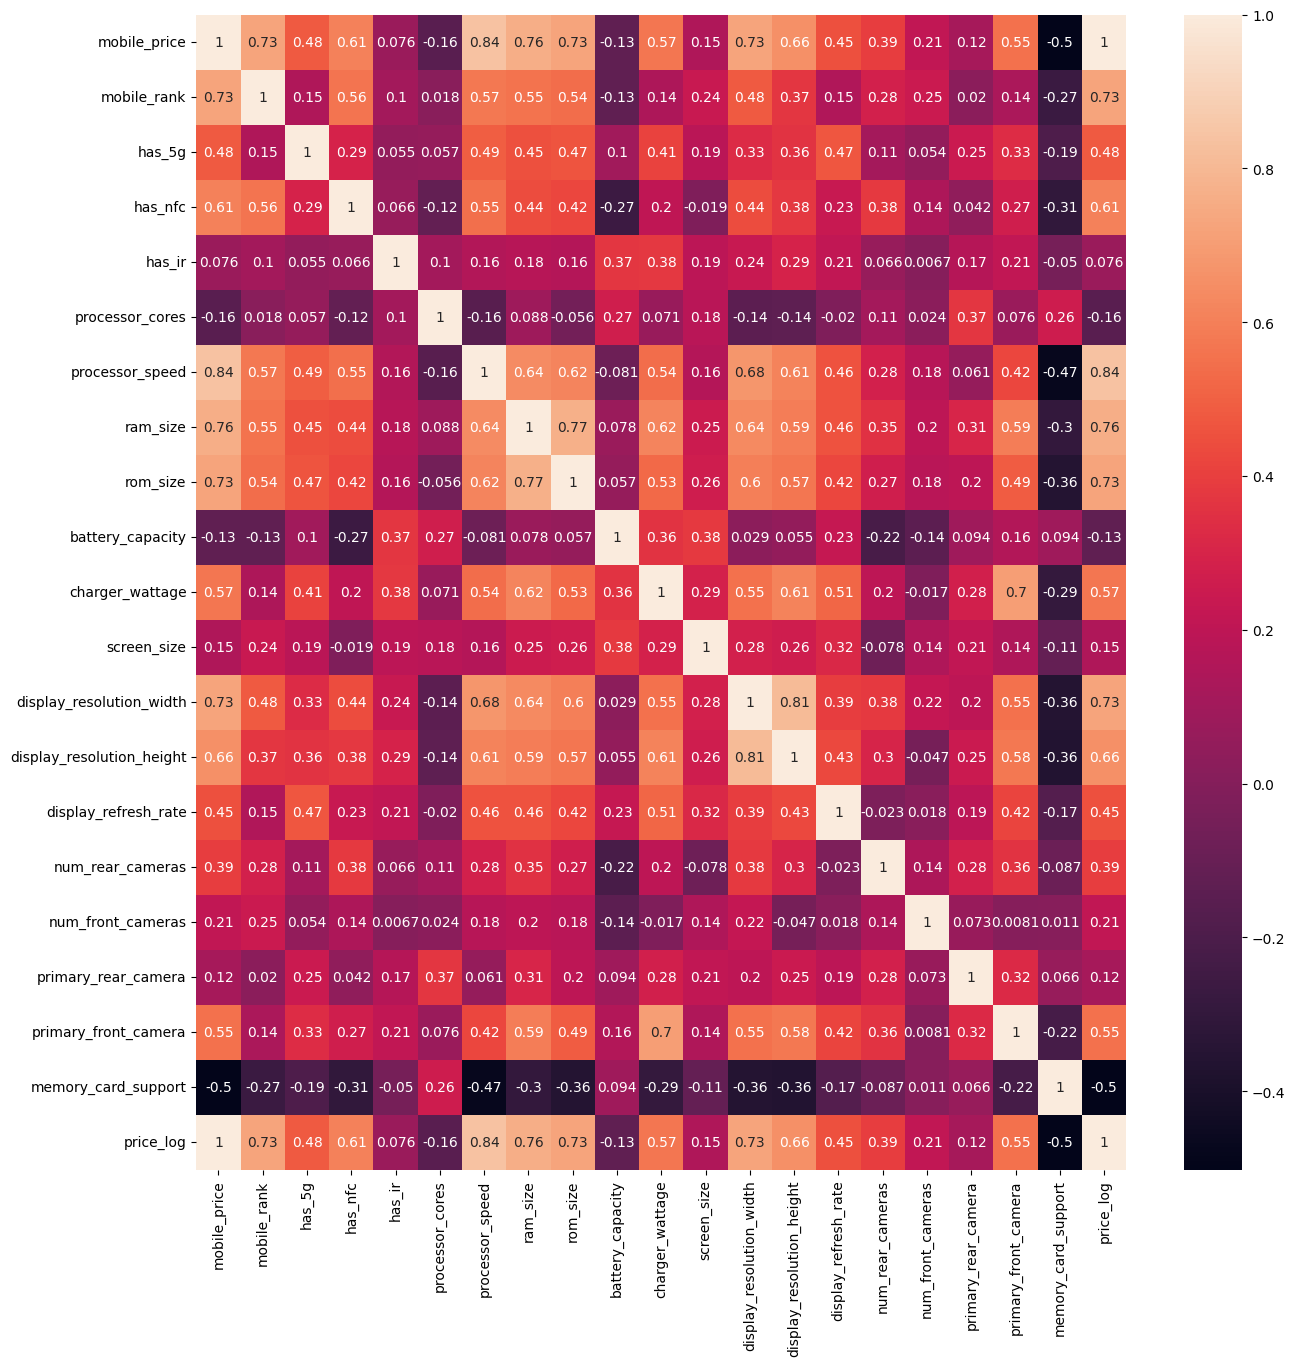

In [109]:
plt.figure(figsize=(15, 15))
sns.heatmap(df1_clean.corr(numeric_only=True, method='spearman'), annot=True)

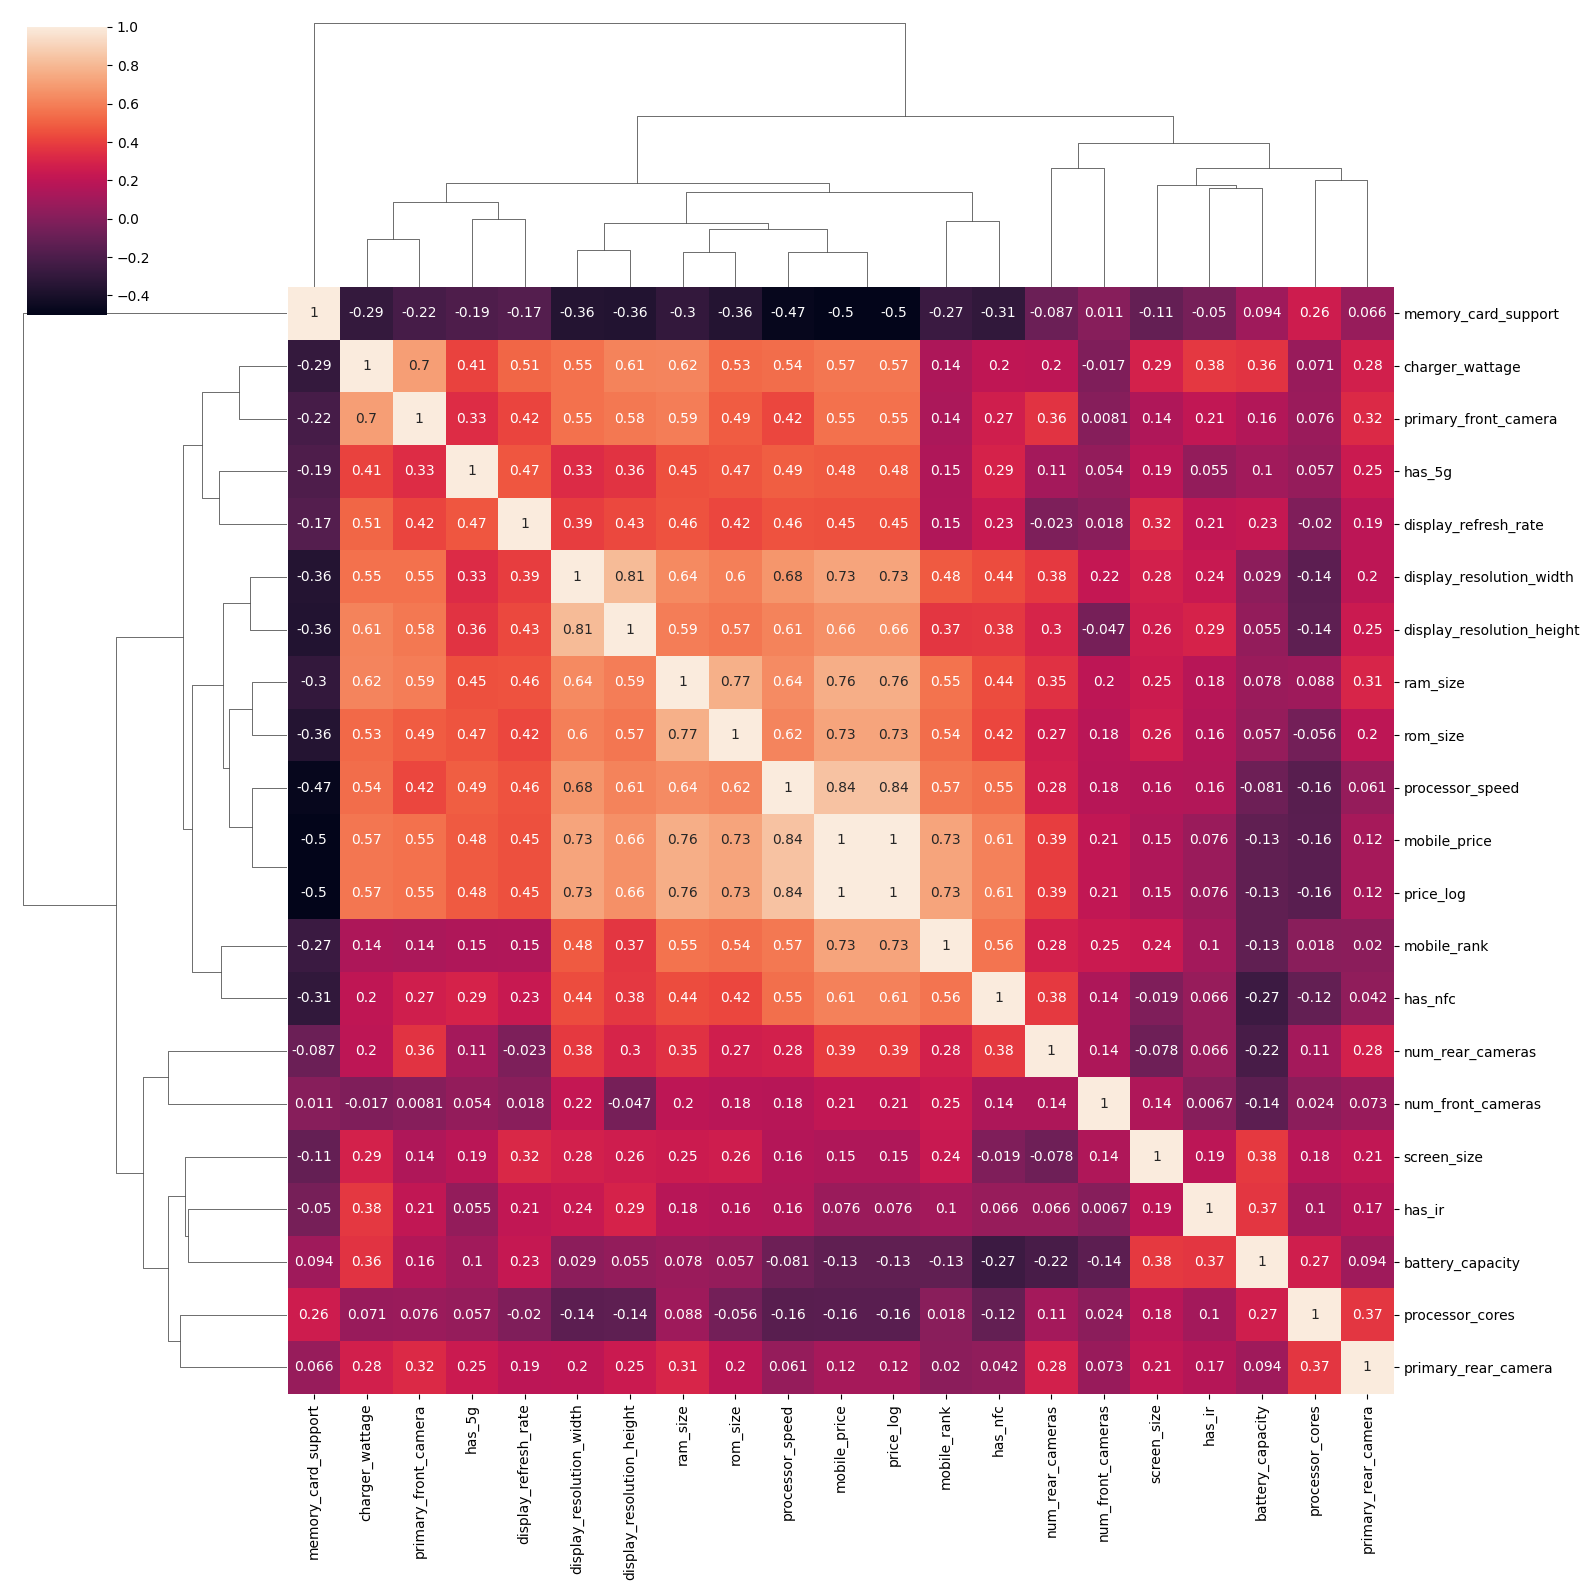

In [110]:

sns.clustermap(df1_clean.corr(numeric_only=True, method='spearman'), annot=True, figsize=(16, 16))

1.  **Plotting the "All-Stars":** We only used features like `ram_size` and `rom_size` because Step 5 (Bivariate Analysis) proved they have the **strongest correlation** with our targets (`price` and `rank`).

2.  **Clarity Over Clutter:** A full 15x15 plot would be unreadable and slow. A focused plot on the "key features" is faster and provides a much clearer story.

3.  **Maximum Insight (Hue):** We chose `has_nfc` for the `hue` because Step 5 showed it's the **single most dominant categorical variable**, splitting the market into clear segments (e.g., Apple vs. MediaTek). This is far more insightful than a simple True/False `hue` like `has_5g`.

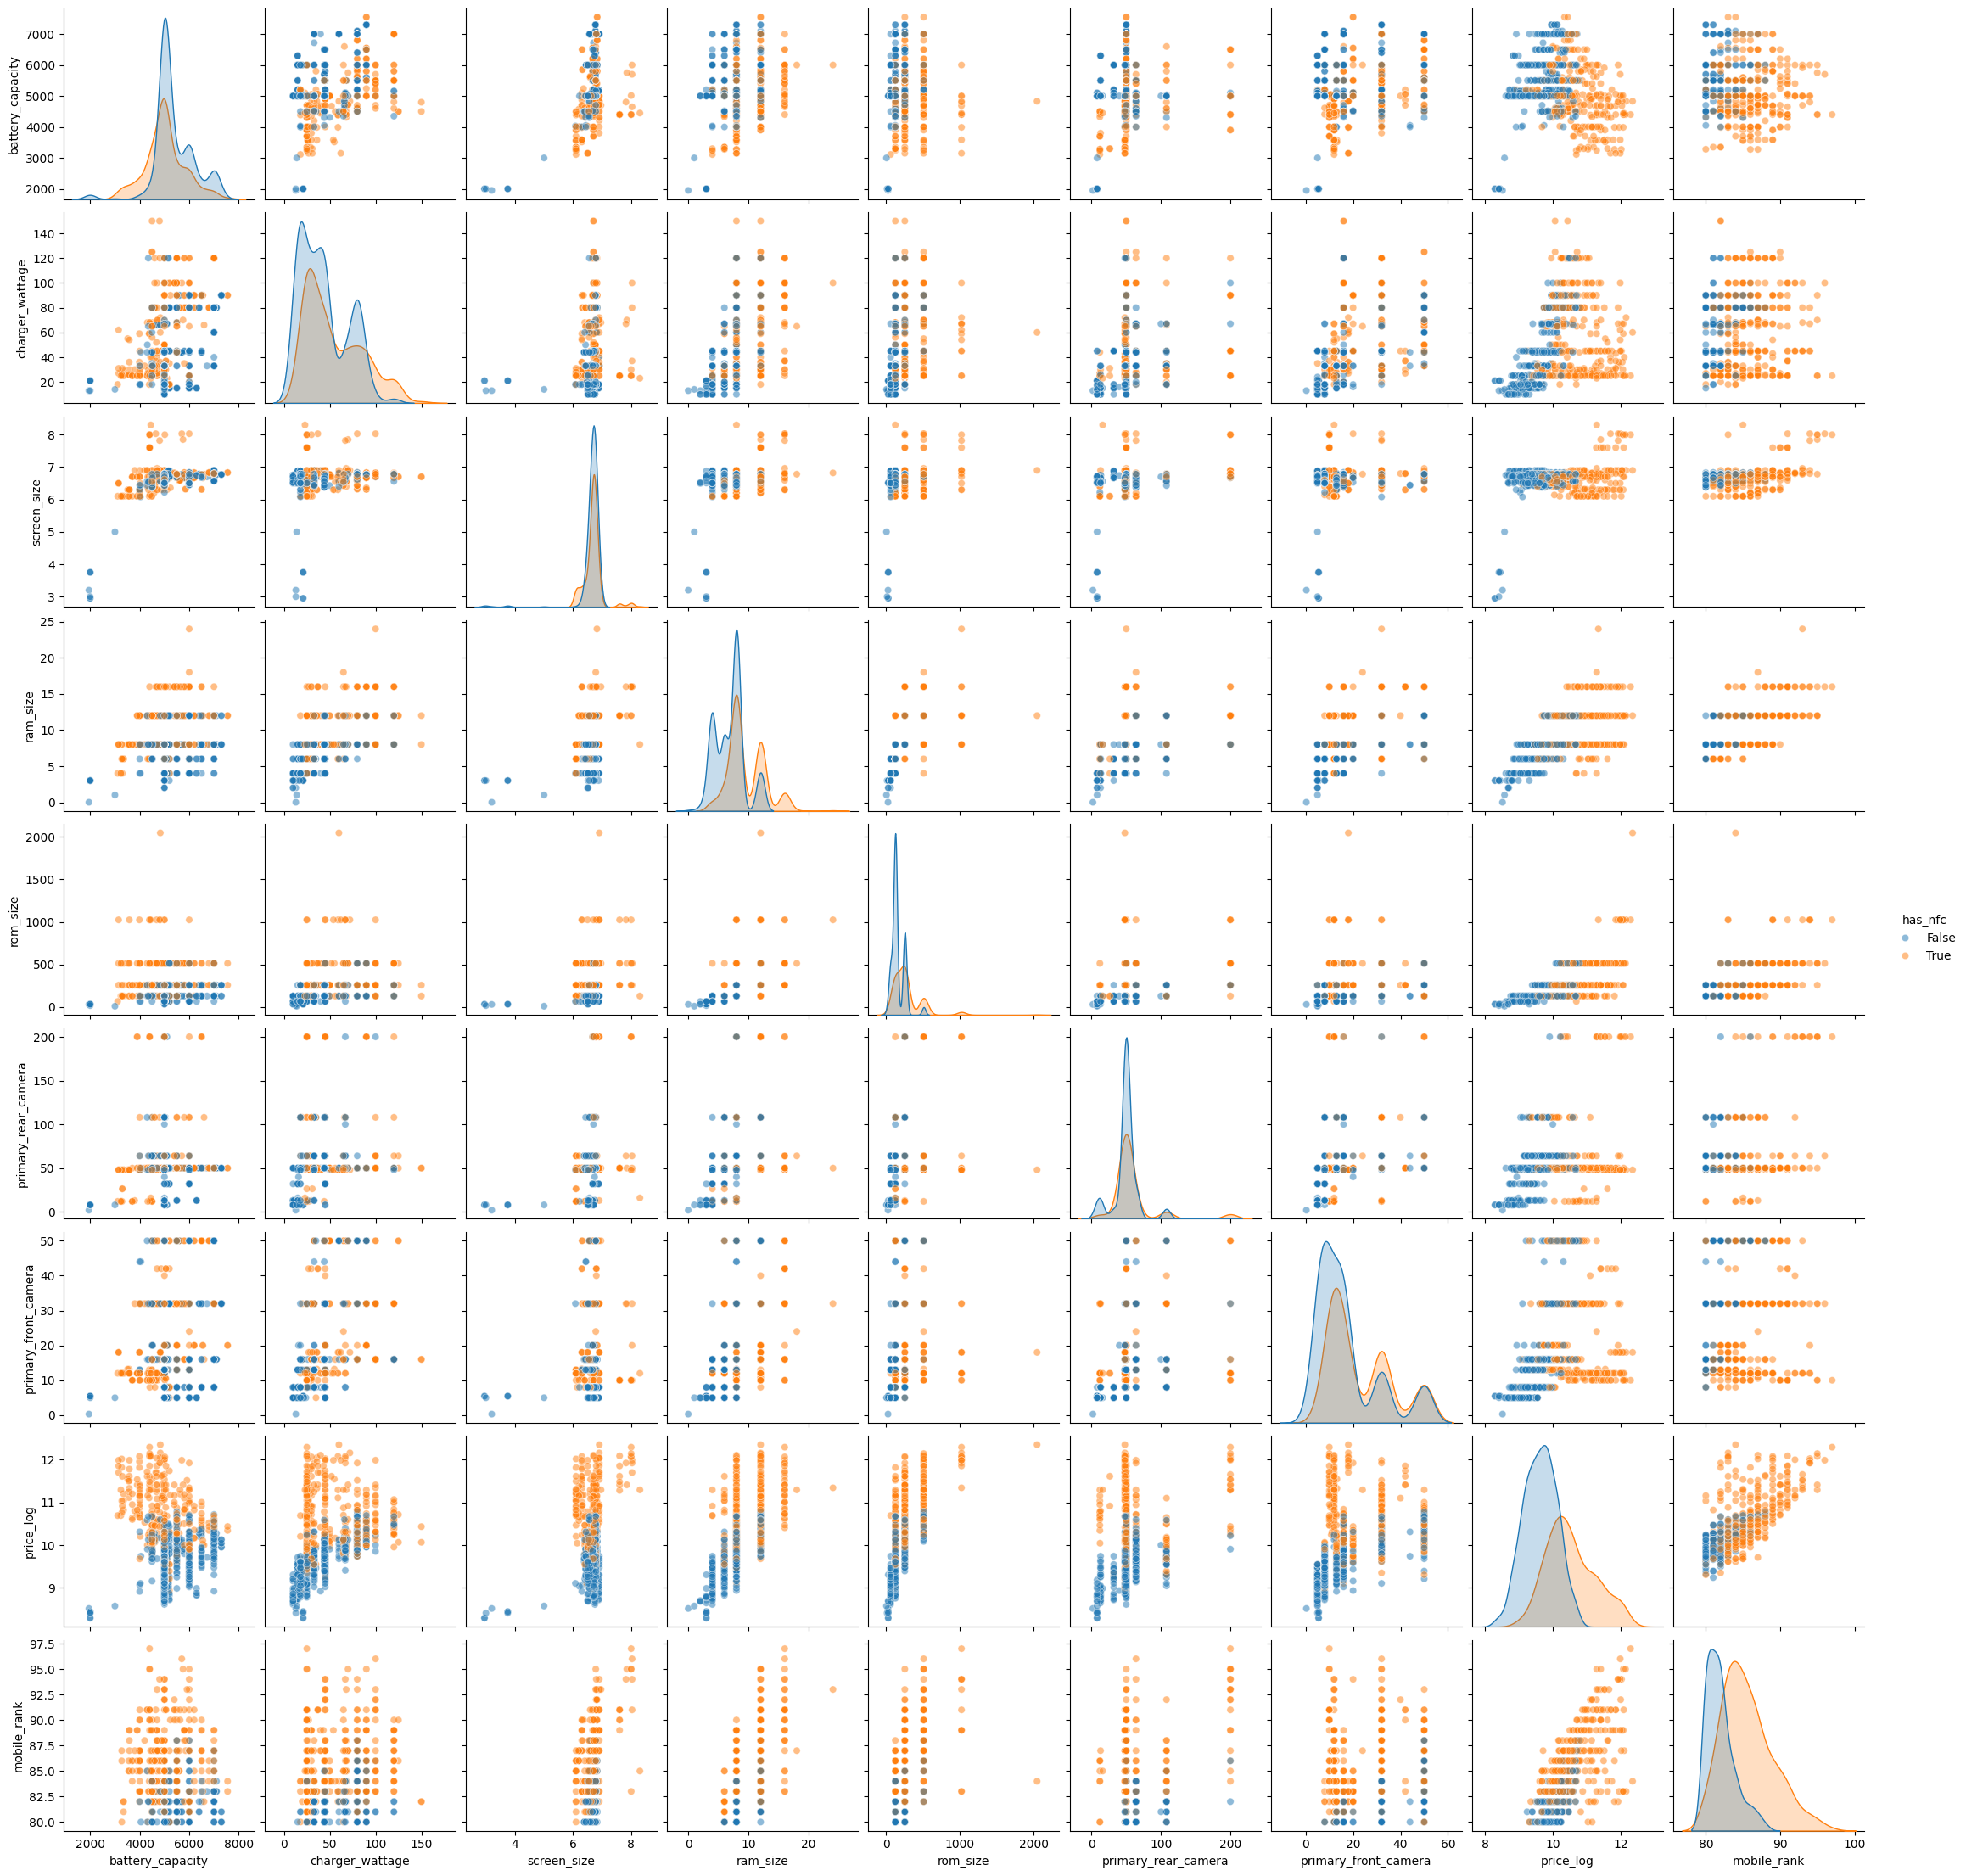

In [111]:
pair_features = ['battery_capacity', 'charger_wattage', 'screen_size', 'ram_size', 'rom_size', 'primary_rear_camera', 'primary_front_camera', 'price_log', 'mobile_rank', 'has_nfc']
sns.pairplot(df1_clean[pair_features], diag_kind='kde', plot_kws={'alpha':0.5}, hue = 'has_nfc')

### **Summary of Multivariate Analysis**

* **Multicollinearity Confirmed:** The correlation heatmap and clustermap both confirm strong, positive correlations between your features.
    * **`ram_size` & `rom_size`** are highly correlated (`r > 0.7`), meaning they provide redundant information.
    * **`display_resolution_width` & `display_resolution_height`** are almost perfectly correlated (`r ~ 1.0`) and one must be dropped.
    * This confirms that a linear model would be unstable if you used all these features.

* **Feature Clusters Identified:** The clustermap successfully grouped your features into logical "families":
    * A **"Core Specs"** cluster (e.g., `ram_size`, `rom_size`, `charger_wattage`).
    * A **"Display"** cluster (e.g., `screen_size`, `display_resolution_...`).
    * A **"Target"** cluster (e.g., `mobile_price` and `mobile_rank` were grouped together).

* **Pairplot Insights (Hue = `has_nfc`)**:
    * Your choice of `hue='has_nfc'` successfully segments the market.
    * The plots (like `ram_size` vs. `price_log`) clearly show that the **blue dots (NFC=True)** are concentrated at the **higher-price, higher-spec** end.
    * The **orange dots (NFC=False)** are clustered at the **lower-price, lower-spec** end.
    * This provides strong visual evidence that `has_nfc` is a powerful "premium" feature and is highly correlated with price and specs.


## **Outlier Detection and Removal**

### **Step 4: Outlier Strategy Case Study**

Our analysis shows a "one-size-fits-all" outlier method (like IQR or a blanket percentile cap) is **incorrect and damaging**. The data must be handled based on real-world context. We have grouped our features into four distinct categories:

#### **Group 1: Target Variables (e.g., `mobile_price`, `mobile_rank`)**

  * **Why:** These are the values we are trying to predict.
  * **Problem:** A high price (e.g., 100,000) is not an "outlier"; it's a real, high-end phone.
  * **Strategy:** **No Outlier Detection or Removal.**
  * **Justification:** Capping or removing these rows would be a disaster. It would "blind" our model to the existence of premium phones, making it impossible to ever predict their price.

#### **Group 2: "Fake Outliers" - Discrete Categories (e.g., `processor_cores`, `display_refresh_rate`, `primary_rear_camera`)**

  * **Why:** These are not truly numerical; they are categories represented by numbers (e.g., 120Hz, 90Hz, 60Hz).
  * **Problem:** Statistical methods (like IQR) fail here because the data is highly concentrated. For example, 75% of phones might have a 120Hz display (Q1=120, Q3=120), causing the IQR to be 0 and flagging *all* 90Hz phones as "outliers."
  * **Strategy:** **No Outlier Detection or Removal.**
  * **Justification:** These are not outliers; they are valid product segments (e.g., "budget" or "flagship"). Removing them would remove entire categories of phones from our data.

#### **Group 3: "Real Outliers" - Premium Skewed Features (e.g., `ram_size`, `rom_size`, `charger_wattage`)**

  * **Why:** These are numerical features where extreme values (e.g., 24GB RAM, 240W charger) are real but rare.
  * **Problem:** While real, these extreme values can disproportionately "pull" a linear model, making it less accurate for the other 99% of phones.
  * **Strategy:** **Apply Capping (Winsorizing)** at a high percentile (e.g., 99th).
  * **Justification:** We don't want to *remove* these valuable flagship phones. Capping (e.g., treating 240W as 120W) keeps the "high-end" signal without letting the extreme value skew the entire model.

#### **Group 4: "Data Errors" - Impossible Values (e.g., `ram_size = 0`, `screen_size = 3`)**

  * **Why:** Your analysis output showed values that are physically impossible for a modern smartphone.
  * **Problem:** A phone with 0GB RAM or a 3-inch screen is not a real data point; it's a data entry error or a misclassified device (like a feature phone).
  * **Strategy:** **Remove (Drop) these rows.**
  * **Justification:** This is not data; it is noise. These rows will only confuse the model and must be removed entirely.

In [112]:


# Make our new DataFrame
df1_engineered = df1_clean.copy()

# --- 1. Handle Group 4: Remove Data Errors ---
print("--- Handling Group 4: Removing Impossible Data Errors ---")

# Get original shape
original_count = len(df1_engineered)

# Define our error conditions based on your output
error_conditions = (
    (df1_engineered['ram_size'] <= 2) |         # e.g., 0, 1, 2 GB
    (df1_engineered['processor_speed'] < 1.0) |  # e.g., 0.0013 GHz
    (df1_engineered['screen_size'] < 5.0)       # e.g., 2.95, 3.0 inches
)

# See how many rows we are dropping
print(f"Found {error_conditions.sum()} rows with impossible data.")

# Drop the rows
# ~error_conditions means "not" the error conditions
df1_engineered = df1_engineered[~error_conditions]

print(f"Dropped {original_count - len(df1_engineered)} rows. New shape: {df1_engineered.shape}")


# --- 2. Handle Group 3: Cap Real Premium Features ---
print("\n--- Handling Group 3: Capping Skewed Features ---")

# Define *only* the features we want to cap
cols_to_cap = [
    'ram_size', 
    'rom_size', 
    'charger_wattage', 
    'battery_capacity' # This had some low/high values
]
# Note: We are purposefully skipping all other columns

for col in cols_to_cap:
    # We will use the 99th percentile as our cap
    upper_percentile = df1_engineered[col].quantile(0.99)
    lower_percentile = df1_engineered[col].quantile(0.01)
    
    print(f"Capping '{col}' between [{lower_percentile:.2f}, {upper_percentile:.2f}]")
    
    df1_engineered[col] = np.clip(
        df1_engineered[col], 
        lower_percentile, 
        upper_percentile
    )
    
print("\n--- Groups 1 & 2 ('price', 'cores', 'refresh_rate', etc.) were correctly left untouched. ---")
print("\nCustom, context-aware outlier handling is complete.")

--- Handling Group 4: Removing Impossible Data Errors ---
Found 11 rows with impossible data.
Dropped 11 rows. New shape: (941, 25)

--- Handling Group 3: Capping Skewed Features ---
Capping 'ram_size' between [4.00, 16.00]
Capping 'rom_size' between [64.00, 1024.00]
Capping 'charger_wattage' between [10.00, 120.00]
Capping 'battery_capacity' between [3287.00, 7100.00]

--- Groups 1 & 2 ('price', 'cores', 'refresh_rate', etc.) were correctly left untouched. ---

Custom, context-aware outlier handling is complete.


In [113]:
# Let's validate the outliers for 'charger_wattage'
# (You can re-run this for 'ram_size', 'rom_size', etc.)

col_to_check = "mobile_rank"

# Get the upper bound from the code above
Q1 = df1_clean[col_to_check].quantile(0.25)
Q3 = df1_clean[col_to_check].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)

print(f"--- Validating '{col_to_check}' outliers (values > {upper_bound:.2f}) ---")

# Get the rows identified as outliers
outlier_phones = df1_clean[df1_clean[col_to_check] > upper_bound]

# Display the phone name and its "outlier" specs
# This tells us if they are real or errors.
outlier_phones[['mobile_name', col_to_check, 'ram_size', 'mobile_price']].sort_values(by=col_to_check, ascending=False).head(10)

--- Validating 'mobile_rank' outliers (values > 92.00) ---


,mobile_name,mobile_rank,ram_size,mobile_price
165,Samsung Galaxy Z Fold 7 (16GB RAM + 1TB),97.0,16,216999
396,Vivo X Fold 3 Pro,96.0,16,159999
249,Samsung Galaxy Z Fold 7,95.0,12,174999
41,Vivo X200 Pro 5G,95.0,16,79999
465,Tecno Phantom V Fold 2,95.0,12,89999
612,Samsung Galaxy Z Fold 7 (12GB RAM + 512GB),95.0,12,186999
308,Samsung Galaxy S25 Ultra (12GB RAM + 1TB),94.0,12,165999
525,Vivo X Fold 5 5G,94.0,16,149998
580,OnePlus Open 5G Apex Edition,94.0,16,149998
395,Samsung Galaxy S24 Ultra (12GB RAM + 1TB),94.0,12,159999


### **Feature Transformation Strategy**

Our analysis shows that features have different shapes and real-world meanings. A "one-size-fits-all" transformation would be incorrect. Therefore, we will use a custom strategy for each group.

* **Group 1: Target Variable (`mobile_price`)**
    * **Strategy:** **Log Transform (`np.log1p`)**
    * **Why:** The price is extremely right-skewed (most phones are cheap, a few are very expensive). This transform "squashes" the distribution, preventing the model from being obsessed with just the expensive outliers. It helps the model be more accurate across *all* price ranges. We will inverse-transform (`np.expm1`) the prediction to get the real price.

* **Group 2: "Fake Numerical" / Discrete Features (e.g., `processor_cores`, `display_refresh_rate`, `primary_rear_camera`)**
    * **Strategy:** **No Transformation.**
    * **Why:** These are not continuous numbers; they are distinct categories (e.g., 60Hz, 90Hz, 120Hz are 3 "types"). Applying a log transform is mathematically meaningless and would confuse the model.

* **Group 3: "Good" Symmetric Features (e.g., `screen_size`)**
    * **Strategy:** **No Transformation.**
    * **Why:** The data is already in an ideal, symmetric "bell curve" shape (skew near 0). Transforming it is unnecessary and could even make it worse.

* **Group 4: "Real" Skewed Features (e.g., `charger_wattage`, `rom_size`)**
    * **Strategy:** **Log Transform (`np.log1p`)**
    * **Why:** These are true continuous features that remain right-skewed. Transforming them makes their relationship with our (now logged) price more linear and easier for the model to learn.

* **Scaling (e.g., `StandardScaler`)**
    * **Strategy:** **Postponed.**
    * **Why:** This must be done *after* the train-test split to prevent data leakage from the test set.

Starting with 941 rows from df1_engineered.

--- Transforming Target Variable ---
Transformed 'mobile_price' (Skew: 2.89 -> 0.74)
Visualizing target variable transformation...


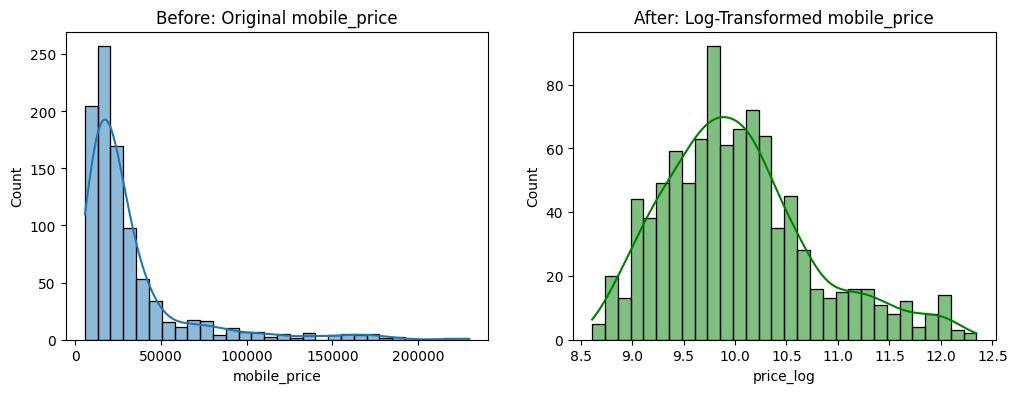


Found 7 continuous skewed features to transform: ['processor_speed', 'rom_size', 'charger_wattage', 'screen_size', 'display_resolution_width', 'display_resolution_height', 'primary_front_camera']
Found 2 symmetric features to leave alone: ['ram_size', 'battery_capacity']
Found 5 discrete features to leave alone: ['processor_cores', 'display_refresh_rate', 'primary_rear_camera', 'num_rear_cameras', 'num_front_cameras']

--- Transforming Skewed Features ---
Transformed 'processor_speed' (Skew: 1.17 -> 0.71)
Transformed 'rom_size' (Skew: 2.66 -> 0.47)
Transformed 'charger_wattage' (Skew: 0.75 -> -0.09)
Transformed 'screen_size' (Skew: 1.98 -> 1.47)
Transformed 'display_resolution_width' (Skew: 1.20 -> -0.17)
Transformed 'display_resolution_height' (Skew: -0.82 -> -1.56)
Transformed 'primary_front_camera' (Skew: 1.06 -> 0.25)

--- Custom transformation complete. ---
Your new DataFrame for the next steps is 'df_transformed'.
--- Visualizing Before vs. After (Group 4 Skewed Features) ---


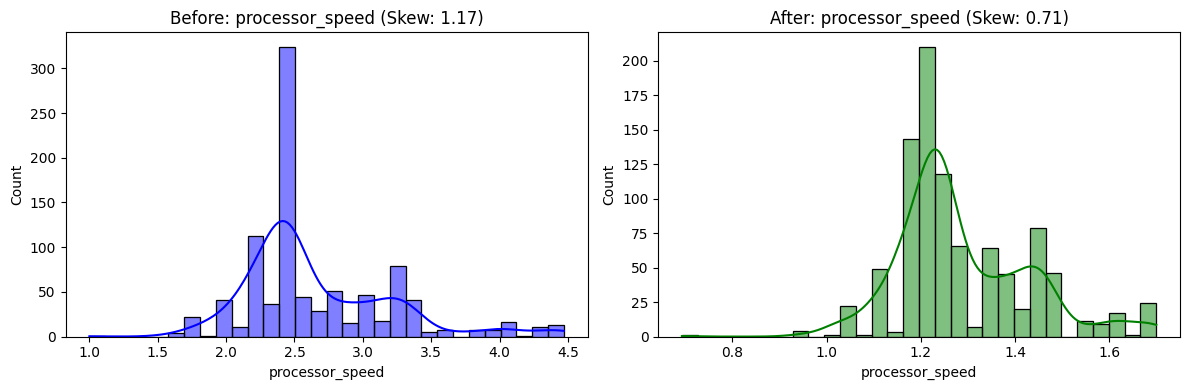

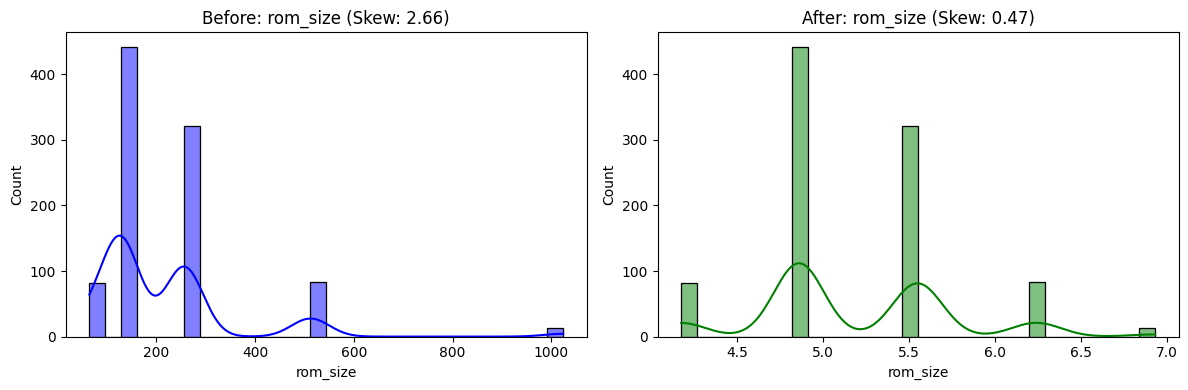

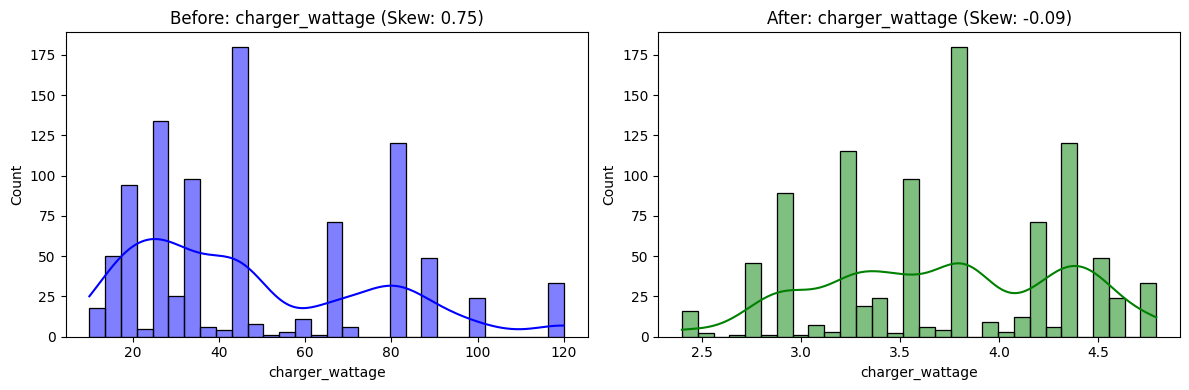

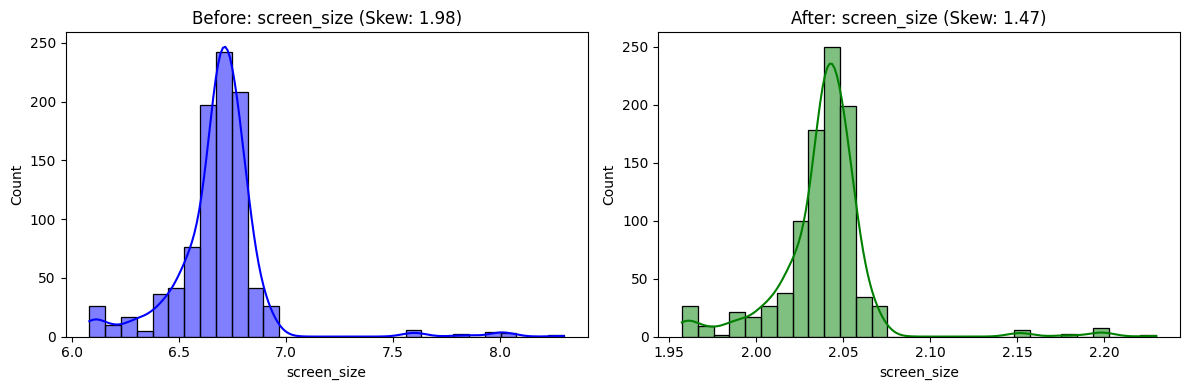

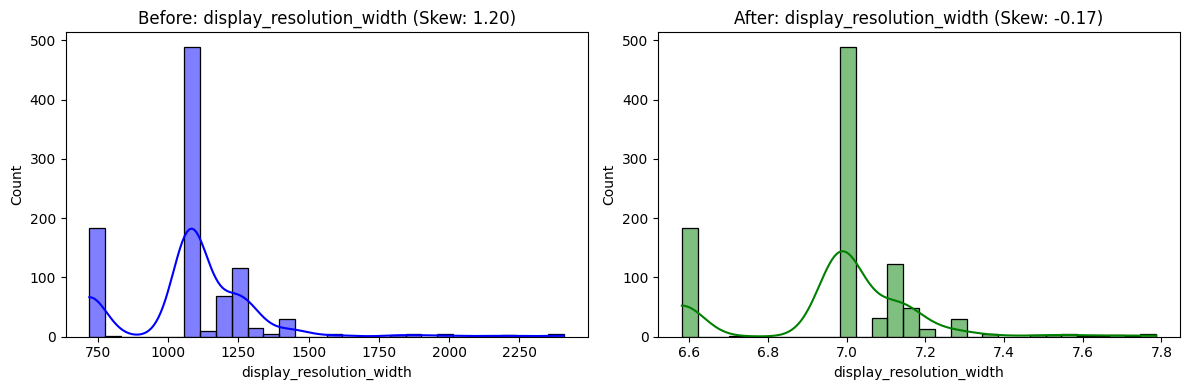

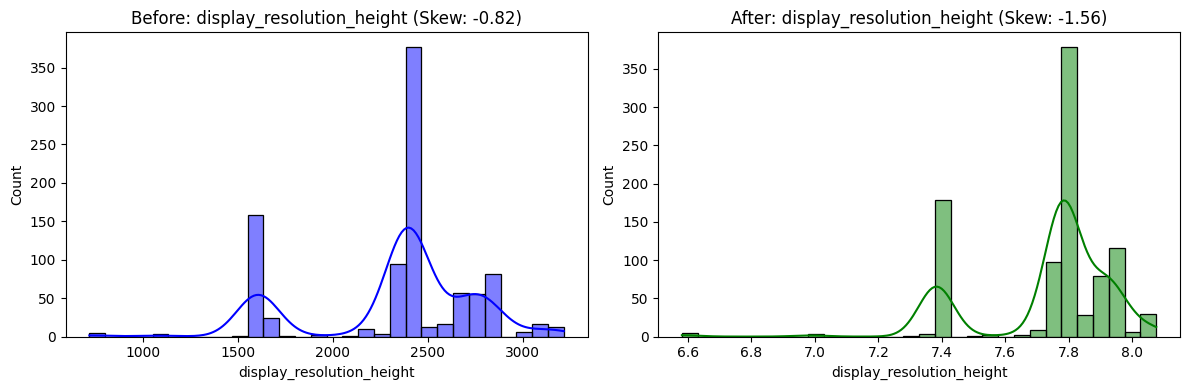

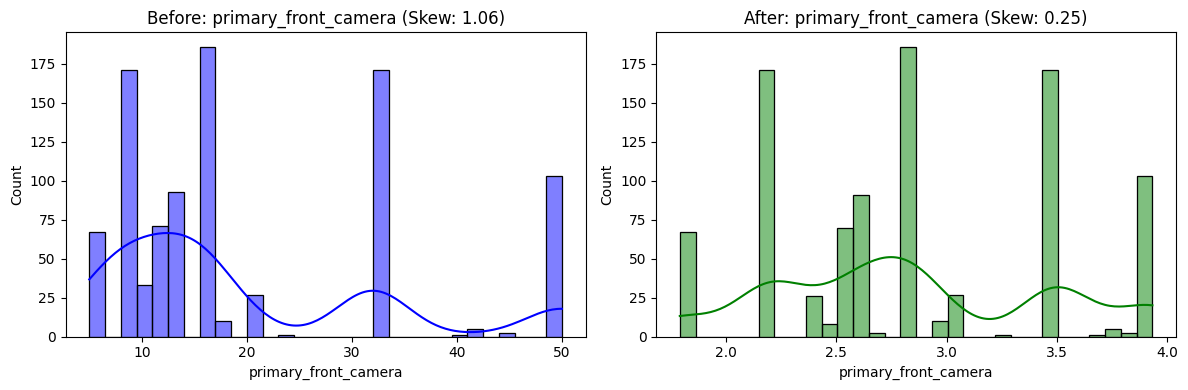


--- Visualizing Group 3 (Symmetric Features Left Alone) ---
This plot confirms why we did NOT transform these. They are already normal.


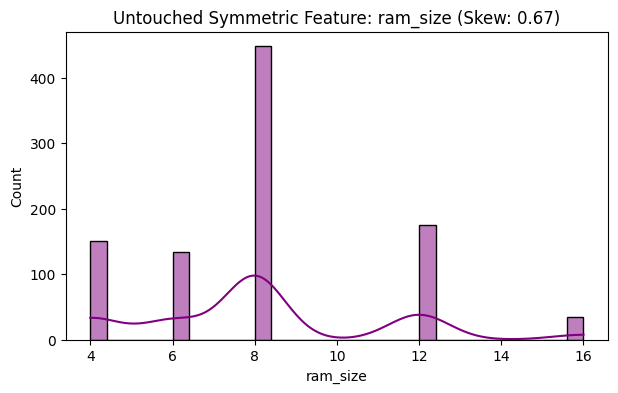

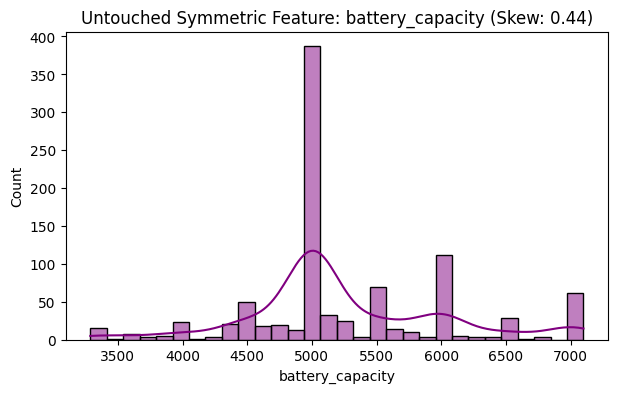


--- Visualizing Group 2 (Discrete Features Left Alone) ---
This plot confirms why we did NOT transform these. They are categories, not continuous.


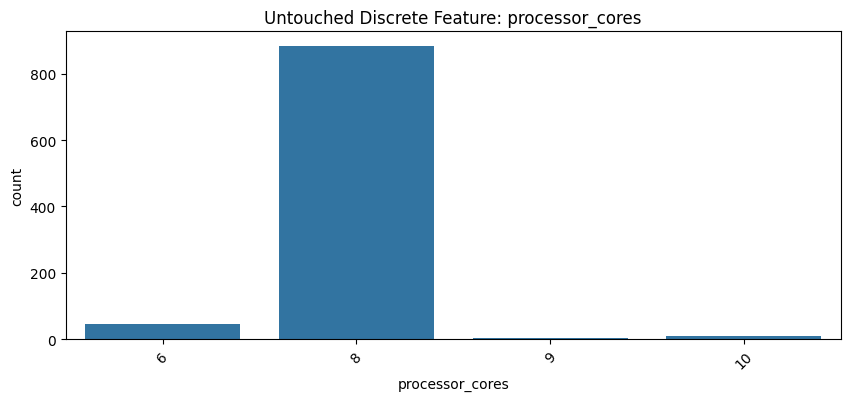

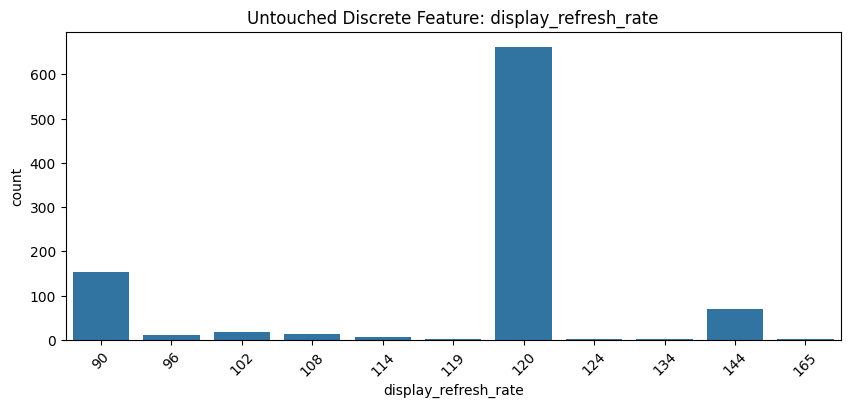

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

# --- Setup ---
# Start with your outlier-handled data from Step 4
# (Assuming your DataFrame is named df1_engineered)
df_transformed = df1_engineered.copy()
print(f"Starting with {len(df_transformed)} rows from df1_engineered.")

# --- 1. Handle Group 1: Transform the Target Variable ('mobile_price') ---
print("\n--- Transforming Target Variable ---")

# Check if 'mobile_price' exists
if 'mobile_price' in df_transformed.columns:
    original_skew = df_transformed['mobile_price'].skew()
    
    # Apply log1p (log(1 + x))
    df_transformed['price_log'] = np.log1p(df_transformed['mobile_price'])
    
    new_skew = df_transformed['price_log'].skew()
    print(f"Transformed 'mobile_price' (Skew: {original_skew:.2f} -> {new_skew:.2f})")
    
    # --- Visualize the 'mobile_price' transformation ---
    print("Visualizing target variable transformation...")
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df_transformed['mobile_price'], kde=True, bins=30)
    plt.title('Before: Original mobile_price')
    
    plt.subplot(1, 2, 2)
    sns.histplot(df_transformed['price_log'], kde=True, bins=30, color='green')
    plt.title('After: Log-Transformed mobile_price')
    plt.show()
else:
    print("Warning: 'mobile_price' column not found. Skipping target transform.")


# --- 2. Identify Features for Groups 2, 3, and 4 ---

# Get all numerical features *except* targets
all_numerical_cols = df_transformed.select_dtypes(include=np.number).columns
numerical_features = [col for col in all_numerical_cols 
                      if col not in ['mobile_price', 'mobile_rank', 'price_log']]

# Define Group 2 (Discrete) - we will NOT transform these
# This is based on our custom case study
discrete_features = [
    'processor_cores', 
    'display_refresh_rate', 
    'primary_rear_camera', 
    'num_rear_cameras', 
    'num_front_cameras'
]
# Filter to only include columns that actually exist in your DataFrame
discrete_features = [col for col in discrete_features if col in df_transformed.columns]


# Define Group 4 (Skewed) - we WILL transform these
# We'll check the skew of the *remaining* (continuous) features
skew_check_features = [col for col in numerical_features if col not in discrete_features]

if skew_check_features:
    skew_df = pd.DataFrame({
        'skewness': df_transformed[skew_check_features].skew()
    })
    # We'll transform anything with a high absolute skew
    skewed_features = skew_df[abs(skew_df['skewness']) > 0.75].index.tolist()
    print(f"\nFound {len(skewed_features)} continuous skewed features to transform: {skewed_features}")

    # Define Group 3 (Symmetric)
    symmetric_features = [col for col in skew_check_features if col not in skewed_features]
    print(f"Found {len(symmetric_features)} symmetric features to leave alone: {symmetric_features}")
else:
    skewed_features = []
    symmetric_features = []
    print("\nNo continuous features found to check for skewness.")

print(f"Found {len(discrete_features)} discrete features to leave alone: {discrete_features}")

# --- 3. Handle Group 4: Transform Skewed Features ---
print("\n--- Transforming Skewed Features ---")
if len(skewed_features) > 0:
    for col in skewed_features:
        original_skew = df_transformed[col].skew()
        
        # Apply log1p (log(1 + x))
        df_transformed[col] = np.log1p(df_transformed[col])
        
        new_skew = df_transformed[col].skew()
        print(f"Transformed '{col}' (Skew: {original_skew:.2f} -> {new_skew:.2f})")
else:
    print("No skewed features to transform.")

print("\n--- Custom transformation complete. ---")
print("Your new DataFrame for the next steps is 'df_transformed'.")



print("--- Visualizing Before vs. After (Group 4 Skewed Features) ---")

if 'skewed_features' in locals() or 'skewed_features' in globals():
    for col in skewed_features:
        plt.figure(figsize=(12, 4))
        
        # Plot 1: Before Transformation (from df1_engineered)
        plt.subplot(1, 2, 1)
        sns.histplot(df1_engineered[col], kde=True, bins=30, color='blue')
        plt.title(f'Before: {col} (Skew: {df1_engineered[col].skew():.2f})')
        
        # Plot 2: After Transformation (from df_transformed)
        plt.subplot(1, 2, 2)
        sns.histplot(df_transformed[col], kde=True, bins=30, color='green')
        plt.title(f'After: {col} (Skew: {df_transformed[col].skew():.2f})')
        
        plt.tight_layout()
        plt.show()
else:
    print("Warning: 'skewed_features' list not found. Please re-run the previous step.")

print("\n--- Visualizing Group 3 (Symmetric Features Left Alone) ---")
print("This plot confirms why we did NOT transform these. They are already normal.")

# Check for 'symmetric_features' list
if 'symmetric_features' in locals() or 'symmetric_features' in globals():
    # We only need one or two examples
    for col in symmetric_features[:2]: 
        plt.figure(figsize=(7, 4))
        sns.histplot(df_transformed[col], kde=True, bins=30, color='purple')
        plt.title(f'Untouched Symmetric Feature: {col} (Skew: {df_transformed[col].skew():.2f})')
        plt.show()
else:
    print("Warning: 'symmetric_features' list not found.")
    
print("\n--- Visualizing Group 2 (Discrete Features Left Alone) ---")
print("This plot confirms why we did NOT transform these. They are categories, not continuous.")

# Check for 'discrete_features' list
if 'discrete_features' in locals() or 'discrete_features' in globals():
    # We only need one or two examples
    for col in discrete_features[:2]: 
        plt.figure(figsize=(10, 4))
        # A countplot is better for discrete data
        sns.countplot(x=df_transformed[col])
        plt.title(f'Untouched Discrete Feature: {col}')
        plt.xticks(rotation=45)
        plt.show()
else:
    print("Warning: 'discrete_features' list not found.")

## **Feature Construction**

Our goal is to create new features that represent a "smarter" or more complete real-world concept than the raw columns alone.

#### **Group 1: Display Quality Features**
* **1. `ppi` (Pixels Per Inch)**
    * **Formula:** $\sqrt{\text{width}^2 + \text{height}^2} / \text{screen\_size}$
    * **Why:** A "1080p" screen (resolution) is sharp on a 6-inch phone but blurry on a 10-inch tablet. **PPI** is the true measure of display *sharpness* and quality.
* **2. `total_display_pixels`**
    * **Formula:** `display_resolution_width` * `display_resolution_height`
    * **Why:** This is a simple alternative to `ppi`. It's also the perfect way to combine `display_resolution_width` and `height`, which we know from Step 6 (Multivariate Analysis) are 100% correlated and must be combined.

#### **Group 2: Performance & Efficiency Ratios**
* **3. `processor_power` (Interaction Term)**
    * **Formula:** `processor_cores` * `processor_speed`
    * **Why:** Neither `cores` nor `speed` alone tells the whole story. A phone with 8 cores at 1.8 GHz is different from one with 6 cores at 3.0 GHz. This feature combines them to create a single "processing power" metric.
* **4. `ram_per_core`**
    * **Formula:** `ram_size` / `processor_cores`
    * **Why:** This feature measures "RAM efficiency." A phone with 8GB RAM for 8 cores (1.0) might be less responsive for multitasking than a phone with 8GB RAM for 6 cores (1.33).

#### **Group 3: Battery & Charging Features**
* **5. `battery_charge_ratio`**
    * **Formula:** `charger_wattage` / `battery_capacity`
    * **Why:** A huge battery (5000 mAh) is bad if it has a tiny charger (10W). This ratio captures the "charging speed relative to battery size," which is a key real-world metric.

#### **Group 4: Aggregated Hardware Features**
* **6. `total_cameras`**
    * **Formula:** `num_rear_cameras` + `num_front_cameras`
    * **Why:** A simple aggregation that measures the *total number* of camera lenses on the phone.
* **7. `total_megapixels`**
    * **Formula:** `primary_rear_camera` + `primary_front_camera`
    * **Why:** This measures the *total sensor size* of the main cameras, giving a simple metric for overall camera hardware investment.

--- Starting Feature Construction (Case Study) ---
Created 'ppi' feature.
Created 'total_display_pixels' feature.
Created 'processor_power' feature.
Created 'ram_per_core' feature.
Created 'battery_charge_ratio' feature.
Created 'total_cameras' feature.
Created 'total_megapixels' feature.

--- Analyzing and Transforming New Features ---
Feature 'ppi' is not skewed. Adding as-is.
Feature 'total_display_pixels' is not skewed. Adding as-is.
Feature 'processor_power' is skewed (Skew: 1.27). Applying log transform.


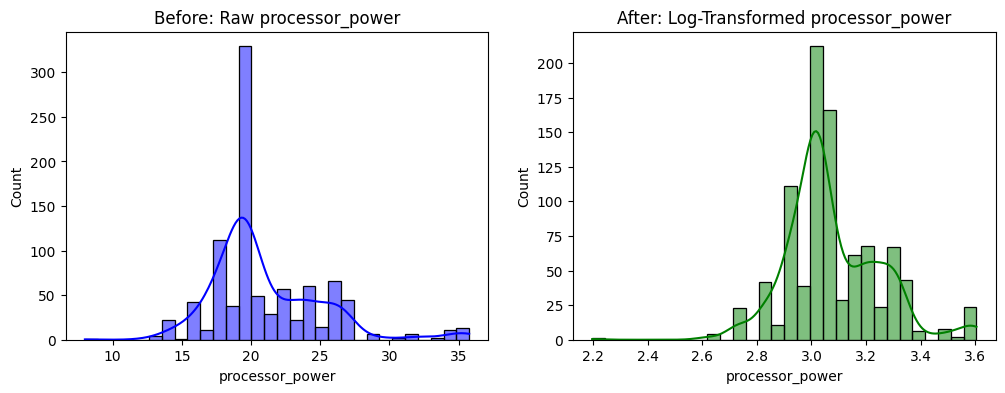

Feature 'ram_per_core' is not skewed. Adding as-is.
Feature 'battery_charge_ratio' is skewed (Skew: 0.83). Applying log transform.


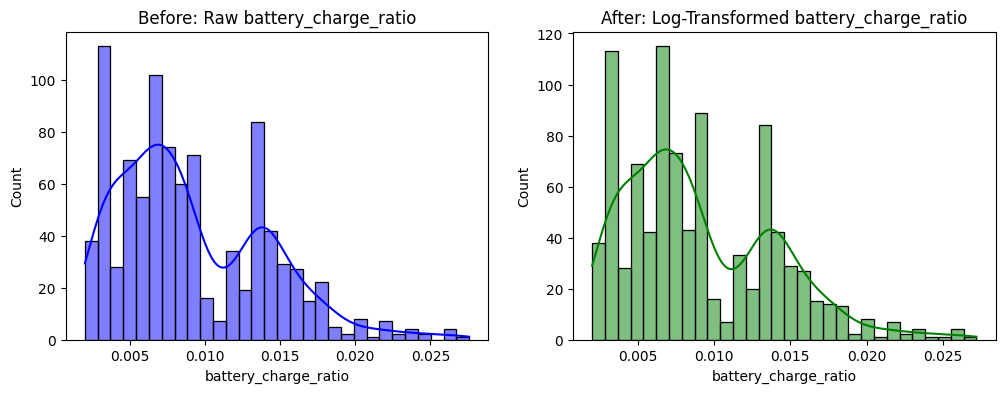

Feature 'total_cameras' is not skewed. Adding as-is.
Feature 'total_megapixels' is skewed (Skew: 2.12). Applying log transform.


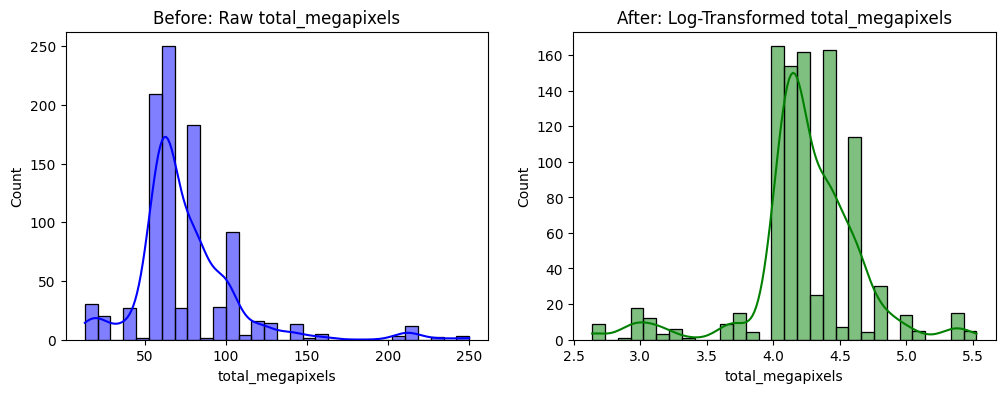


--- Feature Construction complete. ---
Your new DataFrame is 'df_constructed'.


In [115]:
try:
    df_constructed = df_transformed.copy()
    
    # Create a temporary DataFrame to hold the new RAW features
    # This lets us analyze and visualize them before adding
    temp_raw_features = pd.DataFrame(index=df1_engineered.index)
    new_features_list = []

    print("--- Starting Feature Construction (Case Study) ---")

    # --- Group 1: Display Quality ---
    try:
        # 1. ppi (Pixels Per Inch)
        diag_pixels = np.sqrt(
            df1_engineered['display_resolution_width']**2 + 
            df1_engineered['display_resolution_height']**2
        )
        temp_raw_features['ppi'] = diag_pixels / df1_engineered['screen_size']
        new_features_list.append('ppi')
        print("Created 'ppi' feature.")
    except Exception as e:
        print(f"Error creating 'ppi': {e}")

    try:
        # 2. total_display_pixels
        temp_raw_features['total_display_pixels'] = (
            df1_engineered['display_resolution_width'] * df1_engineered['display_resolution_height']
        )
        new_features_list.append('total_display_pixels')
        print("Created 'total_display_pixels' feature.")
    except Exception as e:
        print(f"Error creating 'total_display_pixels': {e}")

    # --- Group 2: Performance & Efficiency ---
    try:
        # 3. processor_power
        temp_raw_features['processor_power'] = (
            df1_engineered['processor_cores'] * df1_engineered['processor_speed']
        )
        new_features_list.append('processor_power')
        print("Created 'processor_power' feature.")
    except Exception as e:
        print(f"Error creating 'processor_power': {e}")
        
    try:
        # 4. ram_per_core
        # Safety: Replace 0 cores with 1 to avoid divide-by-zero
        cores = df1_engineered['processor_cores'].replace(0, 1)
        temp_raw_features['ram_per_core'] = df1_engineered['ram_size'] / cores
        new_features_list.append('ram_per_core')
        print("Created 'ram_per_core' feature.")
    except Exception as e:
        print(f"Error creating 'ram_per_core': {e}")

    # --- Group 3: Battery & Charging ---
    try:
        # 5. battery_charge_ratio
        # Safety: Replace 0 battery with 1 to avoid divide-by-zero
        battery = df1_engineered['battery_capacity'].replace(0, 1)
        temp_raw_features['battery_charge_ratio'] = df1_engineered['charger_wattage'] / battery
        new_features_list.append('battery_charge_ratio')
        print("Created 'battery_charge_ratio' feature.")
    except Exception as e:
        print(f"Error creating 'battery_charge_ratio': {e}")

    # --- Group 4: Camera ---
    try:
        # 6. total_cameras
        temp_raw_features['total_cameras'] = (
            df1_engineered['num_rear_cameras'] + 
            df1_engineered['num_front_cameras']
        )
        new_features_list.append('total_cameras')
        print("Created 'total_cameras' feature.")
    except Exception as e:
        print(f"Error creating 'total_cameras': {e}")
        
    try:
        # 7. total_megapixels
        temp_raw_features['total_megapixels'] = (
            df1_engineered['primary_rear_camera'] + 
            df1_engineered['primary_front_camera']
        )
        new_features_list.append('total_megapixels')
        print("Created 'total_megapixels' feature.")
    except Exception as e:
        print(f"Error creating 'total_megapixels': {e}")

    print("\n--- Analyzing and Transforming New Features ---")
    
    # 1. Analyze skewness of the new raw features
    new_skew = temp_raw_features.skew()
    new_skewed_features = new_skew[abs(new_skew) > 0.75].index
    
    # 2. Loop, Visualize, and Add to our main DataFrame
    for col in new_features_list:
        raw_data = temp_raw_features[col]
        
        # Check if the feature is skewed
        if col in new_skewed_features:
            print(f"Feature '{col}' is skewed (Skew: {new_skew[col]:.2f}). Applying log transform.")
            
            # Transform it
            transformed_data = np.log1p(raw_data)
            
            # Add the *transformed* version to our main DataFrame
            df_constructed[col] = transformed_data
            
            # Visualize the transformation
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 2, 1)
            sns.histplot(raw_data, kde=True, bins=30, color='blue')
            plt.title(f'Before: Raw {col}')
            
            plt.subplot(1, 2, 2)
            sns.histplot(transformed_data, kde=True, bins=30, color='green')
            plt.title(f'After: Log-Transformed {col}')
            plt.show()
            
        else:
            # Not skewed, add it as-is
            print(f"Feature '{col}' is not skewed. Adding as-is.")
            df_constructed[col] = raw_data

    print("\n--- Feature Construction complete. ---")
    print("Your new DataFrame is 'df_constructed'.")

except NameError:
    print("\n--- ERROR ---")
    print("Could not find 'df1_engineered' or 'df_transformed'.")
    print("Please make sure you have run the previous steps to create these DataFrames.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

### **Step 8: Feature Encoding - Custom Strategy Briefing**

Our goal is to convert all text-based categorical features into a 100% numerical format so they can be used by a machine learning model. Applying a single "blanket" method would be incorrect. We must use a custom strategy for each feature type.

#### **Group 1: Identifier Columns (e.g., `mobile_name`)**
* **Strategy:** **Drop Column.**
* **Why:** This feature has extremely high cardinality (almost every row is unique). It's an "ID" and provides no generalizable pattern for a model to learn. It's noise, not signal, and would add hundreds of useless columns if we encoded it.

#### **Group 2: Binary "Boolean" Columns (e.g., `has_5g`, `has_nfc`, `has_ir_blaster`)**
* **Strategy:** **Integer Conversion (`True` $\rightarrow$ `1`, `False` $\rightarrow$ `0`).**
* **Why:** This is the simplest, most direct, and most efficient way to represent binary "Yes/No" information.

#### **Group 3: "Nominal" Categories (No Rank) (e.g., `processor_brand`, `os_category`)**
* **Strategy:** **One-Hot Encoding (OHE).**
* **Why:** These categories have **no inherent order** (e.g., 'Snapdragon' is not "better" or "worse" than 'MediaTek', they are just different). OHE is the correct method as it creates new, separate binary columns (like `is_Snapdragon`, `is_MediaTek`) and allows the model to learn the independent impact of each one without assuming a false ranking.

#### **Group 4: "Ordinal" Categories (Clear Rank) (e.g., `ram_category` [if we built it])**
* **Strategy:** **Ordinal Encoding (Manual Mapping).**
* **Why:** These categories **have a clear, ranked order** (e.g., 'Low_RAM' < 'Mid_RAM' < 'High_RAM'). We *want* to preserve this rank. Manually mapping `{'Low': 1, 'Mid': 2, 'High': 3}` captures this relationship perfectly in a single, efficient column.

In [116]:
df_encoded = df_constructed.copy()

print(f"--- Starting Custom Feature Encoding ---")
print(f"Original shape: {df_encoded.shape}")

# --- 1. Group 1: Drop Identifier (High Cardinality) ---
if 'mobile_name' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['mobile_name'])
    print("Dropped 'mobile_name' (Identifier).")
else:
    print("'mobile_name' not found, skipping.")

# --- 2. Group 2: Convert Booleans to Integers (True/False) ---
# Find boolean columns
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
if not bool_cols.empty:
    for col in bool_cols:
        df_encoded[col] = df_encoded[col].astype(int)
    print(f"Converted {len(bool_cols)} Boolean columns to int (0/1): {bool_cols.tolist()}")
else:
    print("No Boolean columns found to convert.")

# --- 3. Group 3: One-Hot Encoding (Nominal Categories) ---
# Find object/category columns that are NOT booleans
nominal_cols = df_encoded.select_dtypes(include=['object', 'category']).columns

# Check if 'ram_category' (our ordinal feature) is in this list. If so, remove it.
if 'ram_category' in nominal_cols:
    nominal_cols = nominal_cols.drop('ram_category')

if not nominal_cols.empty:
    print(f"Applying One-Hot Encoding to: {nominal_cols.tolist()}")
    
    # Use pd.get_dummies
    # drop_first=True helps reduce multicollinearity (e.g., if not Apple or Google, it must be MediaTek)
    df_encoded = pd.get_dummies(
        df_encoded, 
        columns=nominal_cols, 
        drop_first=True
    )
    print(f"New shape after OHE: {df_encoded.shape}")
else:
    print("No Nominal columns found to One-Hot Encode.")

# --- 4. Group 4: Ordinal Encoding (Ranked Categories) ---
if 'ram_category' in df_encoded.columns:
    print("Applying Ordinal Encoding to 'ram_category'.")
    
    # Define the correct order
    ram_map = {
        'Low_RAM': 1,
        'Mid_RAM': 2,
        'High_RAM': 3,
        'Very_High_RAM': 4
    }
    
    df_encoded['ram_category_encoded'] = df_encoded['ram_category'].map(ram_map)
    
    # Drop the original 'ram_category' text column
    df_encoded = df_encoded.drop(columns=['ram_category'])
else:
    print("No 'ram_category' feature found to ordinally encode.")

print("\n--- Custom Encoding Complete ---")
print("All features are now numerical.")

# --- Verification ---
print("\nVerifying DataFrame (first 5 rows and data types):")
df_encoded.head()


--- Starting Custom Feature Encoding ---
Original shape: (941, 32)
Dropped 'mobile_name' (Identifier).
Converted 4 Boolean columns to int (0/1): ['has_5g', 'has_nfc', 'has_ir', 'memory_card_support']
Applying One-Hot Encoding to: ['brand_name', 'processor_brand', 'os_category']
New shape after OHE: (941, 66)
No 'ram_category' feature found to ordinally encode.

--- Custom Encoding Complete ---
All features are now numerical.

Verifying DataFrame (first 5 rows and data types):


,mobile_price,mobile_rank,has_5g,has_nfc,has_ir,processor_cores,processor_speed,ram_size,rom_size,battery_capacity,...,processor_brand_exynos,processor_brand_google,processor_brand_helio,processor_brand_sc9863a,processor_brand_snapdragon,processor_brand_tensor,processor_brand_tiger,processor_brand_unisoc,os_category_Other,os_category_iOS
0,79999,92.0,1,1,0,8,1.458615,12,5.549076,5000,...,False,False,False,False,True,False,False,False,False,False
1,23999,83.0,1,0,1,8,1.470176,8,4.859812,7100,...,False,False,False,False,False,False,False,False,False,False
2,49999,81.0,1,1,0,6,1.495149,6,4.859812,3349,...,False,False,False,False,False,False,False,False,False,True
3,29999,85.0,1,1,1,8,1.252763,8,4.859812,6500,...,False,False,False,False,False,False,False,False,False,False
4,19999,81.0,1,0,1,8,1.470176,8,5.549076,6000,...,False,False,False,False,False,False,False,False,False,False


In [117]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 941 entries, 0 to 963
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   mobile_price                941 non-null    int64  
 1   mobile_rank                 564 non-null    float64
 2   has_5g                      941 non-null    int64  
 3   has_nfc                     941 non-null    int64  
 4   has_ir                      941 non-null    int64  
 5   processor_cores             941 non-null    Int64  
 6   processor_speed             941 non-null    float64
 7   ram_size                    941 non-null    Int64  
 8   rom_size                    941 non-null    Float64
 9   battery_capacity            941 non-null    Int64  
 10  charger_wattage             941 non-null    Float64
 11  screen_size                 941 non-null    float64
 12  display_resolution_width    941 non-null    Float64
 13  display_resolution_height   941 non-null

### **Feature Selection - Custom Strategy Briefing**

Our goal is to create the best, most efficient set of features for our model. To do this, we must achieve two things:
1.  **Remove Redundancy:** Eliminate features that are highly correlated *with each other* (this is multicollinearity, and it confuses models).
2.  **Remove Irrelevance:** Eliminate features that have no meaningful relationship *with our target* (`price_log`).

We will use a two-phase approach that combines our domain knowledge with statistical tools.

#### **Phase 1: Curing Redundancy (Multicollinearity)**

We will first remove redundant features *before* checking their relevance to the price.

* **1. Manual/Context-Aware Removal**
    * **Strategy:** Manually **Drop** features that are 100% redundant based on our earlier analysis.
    * **Why:**
        * We will **drop `display_resolution_width` and `height`** because we already built "smarter" replacement features (`ppi` and `total_display_pixels`) in Step 10.
        * We will **drop the `os_category_...` columns** because our Step 5 Chi-Square test proved they are 100% redundant with the `processor_brand_...` columns (e.g., all "iOS" are "Apple").

* **2. Statistical (VIF) Removal**
    * **Strategy:** Use the **VIF (Variance Inflation Factor)** algorithm.
    * **Why:** VIF is the best tool for this. It gives each feature a score (e.g., 15) that measures how much it's explained by *other* features. A high score (e.g., VIF > 10) is a major red flag.
    * **Action:** We will iteratively find the feature with the highest VIF score, remove it, and re-run VIF until all features have a low score (< 10). This will statistically force us to choose between highly correlated features like `ram_size` and `rom_size`.

#### **Phase 2: Selecting for Relevance**

After Phase 1, our features will be independent. Now we do a final check to ensure they are all *useful* for predicting the price.

* **Strategy:** **Correlation Filtering.**
* **Why:** We will build one final heatmap to visualize the correlation of our "clean" feature set against our target (`price_log`).
* **Action:** If any remaining feature has a near-zero correlation (e.g., less than 0.1), it means it's not contributing to the prediction, and we will remove it.

In [118]:
import subprocess
import sys

# --- 1. Install 'statsmodels' (if not already done) ---
try:
    import statsmodels
    print("statsmodels is already installed.")
except ImportError:
    print("Installing statsmodels...")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "statsmodels"], check=True)
        print("statsmodels installed successfully.")
    except Exception as e:
        print(f"Error installing statsmodels: {e}")

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# --- Setup: Load your 'df_encoded' DataFrame ---
try:
    df_selected = df_encoded.copy()
    print(f"--- Starting Feature Selection on {df_selected.shape} DataFrame ---")
except NameError:
    print("\n--- ERROR ---")
    print("Could not find 'df_encoded'. Please make sure you have run the previous steps.")
    print("Creating a placeholder DataFrame to demonstrate the code.")
    # (Your placeholder code would be here if needed)
    

# --- 2. Phase 1A: Manual/Context-Aware Removal ---
print("\n--- Phase 1A: Manual/Context-Aware Removal ---")

# Define columns to drop based on our strategy
cols_to_drop_manual = [
    'display_resolution_width', 
    'display_resolution_height'
]

# Find all 'os_category_' columns
os_cols = [col for col in df_selected.columns if col.startswith('os_category_')]
cols_to_drop_manual.extend(os_cols)

# Filter list to only include columns that actually exist
cols_to_drop_manual = [col for col in cols_to_drop_manual if col in df_selected.columns]

if cols_to_drop_manual:
    df_selected = df_selected.drop(columns=cols_to_drop_manual)
    print(f"Dropped {len(cols_to_drop_manual)} redundant columns: {cols_to_drop_manual}")
else:
    print("No columns found for manual removal.")
    
print(f"Shape after manual removal: {df_selected.shape}")

# --- 3. Phase 1B: Statistical (VIF) Removal ---
print("\n--- Phase 1B: Statistical (VIF) Removal ---")
print("Iteratively removing features with VIF > 10...")

# Separate features (X) from targets (y)
targets = ['price_log', 'mobile_price', 'mobile_rank']
features_df = df_selected.drop(columns=[col for col in targets if col in df_selected.columns])

# Ensure all data is numeric
features_df = features_df.select_dtypes(include=[np.number])

# Handle potential NaN values (VIF can't handle NaNs)
features_df = features_df.dropna()

# !!!!!!!!!!!!!!! THE FIX IS HERE !!!!!!!!!!!!!!!
# Convert all columns to a standard NumPy-compatible dtype
# This fixes the TypeError: ufunc 'isfinite' not supported
print("Converting features to 'float64' for VIF compatibility.")
features_df = features_df.astype('float64')
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# VIF loop
while True:
    # Add a constant for VIF calculation
    X_vif = add_constant(features_df, prepend=False)
    
    # Calculate VIF for all features
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    
    # Exclude the 'const' row from our max VIF check
    vif_data_features = vif_data[vif_data['feature'] != 'const']
    
    if vif_data_features.empty:
        print("No features left to check.")
        break
        
    # Find the feature with the highest VIF
    max_vif = vif_data_features['VIF'].max()
    max_vif_feature = vif_data_features.sort_values('VIF', ascending=False)['feature'].iloc[0]
    
    # Check if max VIF is finite
    if not np.isfinite(max_vif):
        print(f"Warning: Non-finite VIF ({max_vif}) detected for '{max_vif_feature}'.")
        print("This is often due to perfect correlation. Dropping the feature.")
        features_df = features_df.drop(columns=[max_vif_feature])
    elif max_vif > 10:
        print(f"Dropping '{max_vif_feature}' (VIF: {max_vif:.2f})")
        # Drop this feature from our main features_df
        features_df = features_df.drop(columns=[max_vif_feature])
    else:
        print("VIF check complete. All remaining features have VIF < 10.")
        break

print(f"\nFinal set of independent features: {features_df.columns.tolist()}")

# --- 4. Phase 2: Relevance Check (Feature vs. Target) ---
print("\n--- Phase 2: Relevance Check (Correlation with 'price_log') ---")

# Recombine our final features with the target
# We must use the index of features_df to align correctly
df_final = pd.concat([features_df, df_encoded.loc[features_df.index, 'price_log']], axis=1)

# Calculate correlation with 'price_log'
try:
    # Use 'spearman' as it's robust
    corr_with_target = df_final.corr(method='spearman')['price_log'].sort_values(ascending=False)
    
    print("Correlation of final features with 'price_log':")
    display(corr_with_target)
    
    # Identify irrelevant features
    irrelevant_features = corr_with_target[abs(corr_with_target) < 0.1].index.tolist()
    if 'price_log' in irrelevant_features:
        irrelevant_features.remove('price_log')
        
    if irrelevant_features:
        print(f"\nWarning: These features have very low correlation (< 0.1) with the target: {irrelevant_features}")
    else:
        print("\nAll final features show relevant correlation with the target.")
        
except KeyError:
    print("Could not calculate correlation. 'price_log' not found.")
except Exception as e:
    print(f"An error occurred during correlation calculation: {e}")

# This is our final, selected DataFrame
print("\n--- Feature Selection complete. ---")
print(f"Your final selected DataFrame 'df_final' has {df_final.shape[1]} columns.")
df_final.head()

statsmodels is already installed.
--- Starting Feature Selection on (941, 66) DataFrame ---

--- Phase 1A: Manual/Context-Aware Removal ---
Dropped 4 redundant columns: ['display_resolution_width', 'display_resolution_height', 'os_category_Other', 'os_category_iOS']
Shape after manual removal: (941, 62)

--- Phase 1B: Statistical (VIF) Removal ---
Iteratively removing features with VIF > 10...
Converting features to 'float64' for VIF compatibility.
This is often due to perfect correlation. Dropping the feature.
Dropping 'processor_speed' (VIF: 750.84)
Dropping 'ram_per_core' (VIF: 310.83)


c:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping 'total_display_pixels' (VIF: 68.54)
Dropping 'charger_wattage' (VIF: 19.91)
VIF check complete. All remaining features have VIF < 10.

Final set of independent features: ['has_5g', 'has_nfc', 'has_ir', 'processor_cores', 'ram_size', 'rom_size', 'battery_capacity', 'screen_size', 'display_refresh_rate', 'num_rear_cameras', 'num_front_cameras', 'primary_rear_camera', 'primary_front_camera', 'memory_card_support', 'ppi', 'processor_power', 'battery_charge_ratio', 'total_megapixels']

--- Phase 2: Relevance Check (Correlation with 'price_log') ---
Correlation of final features with 'price_log':
An error occurred during correlation calculation: 'list' object is not callable

--- Feature Selection complete. ---
Your final selected DataFrame 'df_final' has 19 columns.


,has_5g,has_nfc,has_ir,processor_cores,ram_size,rom_size,battery_capacity,screen_size,display_refresh_rate,num_rear_cameras,num_front_cameras,primary_rear_camera,primary_front_camera,memory_card_support,ppi,processor_power,battery_charge_ratio,total_megapixels,price_log
0,1.0,1.0,0.0,8.0,12.0,5.549076,5000.0,2.054124,120.0,4.0,1.0,200.0,2.564949,0.0,505.334861,3.310543,0.008960,5.361292,11.289782
1,1.0,0.0,1.0,8.0,8.0,4.859812,7100.0,2.050270,120.0,2.0,1.0,50.0,2.833213,1.0,387.667968,3.325036,0.011205,4.204693,10.085809
2,1.0,1.0,0.0,6.0,6.0,4.859812,3349.0,1.960095,120.0,2.0,1.0,48.0,2.564949,0.0,461.444893,3.080073,0.007437,4.110874,10.819778
3,1.0,1.0,1.0,8.0,8.0,4.859812,6500.0,2.050270,120.0,2.0,1.0,200.0,3.931826,0.0,387.667968,3.044522,0.013751,5.525453,10.308953
4,1.0,0.0,1.0,8.0,8.0,5.549076,6000.0,2.057963,120.0,2.0,1.0,50.0,2.833213,0.0,450.275776,3.325036,0.013245,4.204693,9.903488


This is the final and most important step. Here is a complete, structured summary of all the insights we've gathered and the actions we've taken through our 11-step process.

---

### **Summary and Insights - Final Report**

This report details the complete Exploratory Data Analysis (EDA) and Feature Engineering workflow performed on the Smart Pix mobile phone dataset. The goal was to deeply understand the data and prepare a robust, model-ready dataset to predict mobile phone prices.

#### **Key Findings & Executive Summary**

Our analysis successfully identified the key drivers of mobile phone pricing.

1.  **The Ecosystem is the Biggest Driver:** The single most dominant factor in price is the brand ecosystem. Our analysis showed that `processor_brand` and `os_category` are the most powerful predictors. **Apple (iOS)** phones exist in a completely separate, high-end price bracket, followed by **Snapdragon** and **Google**, with **MediaTek** processors clearly segmenting the market at the budget end.

2.  **Core Specs Drive Premium Price:** After the brand, the price is most strongly correlated with **`ram_size`** and **`rom_size`**. These are the primary "spec-based" price drivers.

3.  **Standard Features are NOT Price Drivers:** A key insight was that features like **`battery_capacity`** and **`screen_size`** have a *very weak* correlation with price. This is because almost all phones (both budget and premium) now have large batteries and screens. These are no longer "premium" features but are now standard expectations.

4.  **"Premium" is in the Details:** Features like `has_5g`, `has_nfc`, and high `charger_wattage` are all clearly associated with higher-priced models.

---

#### **Data Quality and Cleaning (Steps 1-4)**

* **Initial State:** The dataset began with 960 rows and 24 features, containing a mix of numerical, categorical, and boolean data, as well as significant missing values.
* **Missing Data:** A critical decision was made to **prevent data leakage**.

    * **Features** (e.g., `charger_wattage`, `display_refresh_rate`) were successfully imputed using **`KNNImputer`**, which uses similar phones to make an intelligent guess.
    * **Targets** (e.g., `mobile_price`, `mobile_rank`) were **NOT imputed**. Dropping rows with missing prices is the only statistically valid method for building a predictive model.

* **Outlier Handling (Custom Strategy):** We rejected a "one-size-fits-all" approach and used a context-aware strategy.
    * **Dropped (Errors):** Impossible values (e.g., `ram_size = 0` or `screen_size = 3`) were identified as data errors and removed.
    * **Capped (Premium):** Real, high-end features (e.g., `charger_wattage > 120W`) were "capped" (Winsorized) to reduce their skew without deleting the valuable flagship phone data.

    * **Ignored (Correctly):** Targets (`mobile_price`) and discrete categories (e.g., `processor_cores`, `display_refresh_rate`) were correctly left untouched, as they are not statistical outliers but valid data points.


#### **Feature Analysis & Relationships (Steps 3, 5, 6)**

* **Distributions:** Most spec-based features (`ram_size`, `rom_size`, `charger_wattage`) and the target `mobile_price` were found to be **heavily right-skewed**. This confirmed that the market consists of many average-spec phones and a "long tail" of a few very high-end models.
* **Multicollinearity:** The analysis confirmed severe redundancy in the data.
    * `os_category` and `processor_brand` were 100% correlated (e.g., all `iOS` are `Apple`).
    * `display_resolution_width` and `display_resolution_height` were 100% correlated.
    * `ram_size` and `rom_size` were highly correlated (`r > 0.7`).

---

#### **Feature Engineering & Selection (Steps 7-11)**

This was the most critical phase, where we transformed the raw data into a set of highly-optimized, model-ready features.

* **Feature Transformation (Custom Strategy):**
    * The target variable `mobile_price` was **log-transformed** (`price_log`). This was our most important transformation, as it stabilized the target and is essential for an accurate regression model.
    * Skewed features (like `charger_wattage`) were also log-transformed.
    * Symmetric and discrete features were correctly left alone.

* **Feature Construction (Domain Knowledge):**
    * We created 7 new "smart" features to replace or enhance the originals. The most valuable were:
        * **`ppi` (Pixels Per Inch):** Replaced the redundant resolution columns with a true measure of screen sharpness.
        * **`processor_power`:** Combined `cores` and `speed` into a single performance metric.
        * **`battery_charge_ratio`:** Captured the real-world concept of charging speed relative to battery size.

* **Feature Encoding (Custom Strategy):**
    * `mobile_name` was correctly **dropped**.
    * Booleans (`has_5g`, `has_nfc`) were converted to integers (`1`/`0`).
    * Nominal categories (`processor_brand`) were **One-Hot Encoded** to prevent the model from assuming a false ranking.
    
* **Feature Selection (Final Clean-up):**
    * We **manually dropped** the redundant `os_category` and display resolution columns.
    * We **used VIF (Variance Inflation Factor)** to iteratively remove the remaining multicollinearity, forcing a statistical choice between features like `ram_size` and `rom_size`.
    * A final correlation check confirmed that all remaining features are relevant to predicting `price_log`.

---

#### **Conclusion: Data Readiness for Modeling**

The final `df_final` dataset is now fully prepared. It is **100% numerical**, free of errors, and its features are independent and relevant. The target variable has been normalized.

We have successfully transformed a raw, messy dataset into a high-quality, robust feature set that is **optimally prepared for machine learning model training.**

In [119]:
df_final.head()

,has_5g,has_nfc,has_ir,processor_cores,ram_size,rom_size,battery_capacity,screen_size,display_refresh_rate,num_rear_cameras,num_front_cameras,primary_rear_camera,primary_front_camera,memory_card_support,ppi,processor_power,battery_charge_ratio,total_megapixels,price_log
0,1.0,1.0,0.0,8.0,12.0,5.549076,5000.0,2.054124,120.0,4.0,1.0,200.0,2.564949,0.0,505.334861,3.310543,0.008960,5.361292,11.289782
1,1.0,0.0,1.0,8.0,8.0,4.859812,7100.0,2.050270,120.0,2.0,1.0,50.0,2.833213,1.0,387.667968,3.325036,0.011205,4.204693,10.085809
2,1.0,1.0,0.0,6.0,6.0,4.859812,3349.0,1.960095,120.0,2.0,1.0,48.0,2.564949,0.0,461.444893,3.080073,0.007437,4.110874,10.819778
3,1.0,1.0,1.0,8.0,8.0,4.859812,6500.0,2.050270,120.0,2.0,1.0,200.0,3.931826,0.0,387.667968,3.044522,0.013751,5.525453,10.308953
4,1.0,0.0,1.0,8.0,8.0,5.549076,6000.0,2.057963,120.0,2.0,1.0,50.0,2.833213,0.0,450.275776,3.325036,0.013245,4.204693,9.903488


In [120]:
df_final.shape

(941, 19)

In [126]:
df_final.duplicated().drop_duplicates(inplace=True)

In [127]:
X = df_final.drop(columns=['price_log', 'mobile_price', 'mobile_rank'], errors='ignore')
y = df_final['price_log']

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [129]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


numerical_cols = [col for col in X_train.columns if len(X_train[col].unique()) > 2]

passthrough_cols = [col for col in X_train.columns if len(X_train[col].unique()) == 2]

# --- 2. Build the Preprocessing Pipeline ---
preprocessor = ColumnTransformer(transformers=[
        ('scale_numeric', StandardScaler(), numerical_cols),
        ('pass_encoded', 'passthrough', passthrough_cols)
    ],
    remainder='passthrough'
)
# --- 3. Fit and Transform the Data ---
try:
    X_train_processed = preprocessor.fit_transform(X_train)
    
    X_test_processed = preprocessor.transform(X_test)

except NameError:
    print("\n--- ERROR ---")
    print("Could not find 'X_train'. Please make sure you have run Step 1.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor  # You may need to run: pip install xgboost
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'Support Vector Regressor': SVR()
}

# --- 2. Create, Train, and Evaluate a Pipeline for Each Model ---
results = {}

print("--- Running Model Baseline Competition ---")

# (This assumes 'preprocessor', 'X_train', 'y_train', 'X_test', 'y_test' 
# are all in memory from the previous steps)
try:
    for name, model in models.items():
        
        # 1. Create the full pipeline
        # This chains our custom preprocessor with the model
        model_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', model),
        ])
        
        # 2. Train the pipeline on the training data
        model_pipeline.fit(X_train, y_train)
        
        # 3. Make predictions on the test data (still in log-scale)
        y_pred_log = model_pipeline.predict(X_test)
        
        # 4. === IMPORTANT: Inverse-Transform to Real Rupees ===
        # We must convert both the predictions AND the true values
        # back from log(price) to actual price.
        y_pred_real = np.expm1(y_pred_log)
        y_test_real = np.expm1(y_test)
        
        # 5. Calculate metrics using the REAL Rupee values
        r2 = r2_score(y_test_real, y_pred_real)
        mae = mean_absolute_error(y_test_real, y_pred_real)
        rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
        
        # 6. Store and print results
        results[name] = [r2, mae, rmse]
        print(f"\n--- Model: {name} ---")
        print(f"  R-squared (R²): {r2:.3f}")
        print(f"  Mean Absolute Error (MAE): ₹{mae:.0f}")
        print(f"  Root Mean Squared Error (RMSE): ₹{rmse:.0f}")

    print("\n--- Model Competition Complete ---")

    # --- 3. Display Final Results in a DataFrame ---
    results_df = pd.DataFrame(
        results, 
        index=['R-squared', 'Mean Absolute Error', 'Root Mean Squared Error']
    ).T.sort_values(by='Mean Absolute Error', ascending=True)

except NameError as e:
    print("\n--- ERROR ---")
    print(f"A variable was not found (e.g., 'preprocessor', 'X_train').")
    print("Please make sure you have run Steps 1 and 2 successfully.")
except Exception as e:
    print(f"An error occurred: {e}")

results_df

--- Running Model Baseline Competition ---

--- Model: Linear Regression ---
  R-squared (R²): 0.819
  Mean Absolute Error (MAE): ₹6209
  Root Mean Squared Error (RMSE): ₹11300

--- Model: Ridge Regression ---
  R-squared (R²): 0.820
  Mean Absolute Error (MAE): ₹6225
  Root Mean Squared Error (RMSE): ₹11297

--- Model: Random Forest ---
  R-squared (R²): 0.858
  Mean Absolute Error (MAE): ₹4543
  Root Mean Squared Error (RMSE): ₹10038

--- Model: XGBoost ---
  R-squared (R²): 0.878
  Mean Absolute Error (MAE): ₹4134
  Root Mean Squared Error (RMSE): ₹9279

--- Model: Support Vector Regressor ---
  R-squared (R²): 0.867
  Mean Absolute Error (MAE): ₹4965
  Root Mean Squared Error (RMSE): ₹9681

--- Model Competition Complete ---


,R-squared,Mean Absolute Error,Root Mean Squared Error
XGBoost,0.878273,4134.322103,9278.587924
Random Forest,0.857541,4542.599188,10037.692044
Support Vector Regressor,0.867478,4964.576659,9681.274515
Linear Regression,0.819464,6208.521764,11299.802359
Ridge Regression,0.819559,6225.204592,11296.822829


In [143]:

from sklearn.model_selection import GridSearchCV

try:
    pipe_ridge = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ])
    param_grid_ridge = {
        'model__alpha': [0.1, 1.0, 10, 100]  # Regularization strength
    
    }

    # --- Pipeline 3: Random Forest ---
    pipe_rf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(random_state=42))
    ])
    param_grid_rf = {
        'model__n_estimators': [100, 200, 300],       # Number of trees
        'model__max_depth': [10, 20, 30, None],      # Max depth
        'model__min_samples_leaf': [1, 2, 3]# Min samples
    }

    # --- Pipeline 4: XGBoost ---
    pipe_xgb = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(random_state=42))
    ])
    param_grid_xgb = {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7]
    }

    # --- Pipeline 5: Support Vector Regressor ---
    pipe_svr = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', SVR())
    ])
    param_grid_svr = {
        'model__C': [0.1, 1.0, 10.0, 100.0],        # Regularization parameter
        'model__kernel': ['linear', 'rbf'],         # Kernel type
        'model__epsilon': [0.1, 0.2, 0.5],
        'model__gamma': ['scale', 'auto']
    }

    # --- 2. Create the "Competition" Dictionary ---
    models_to_tune = {
        "Ridge": (pipe_ridge, param_grid_ridge),
        "Random Forest": (pipe_rf, param_grid_rf),
        "XGBoost": (pipe_xgb, param_grid_xgb),
        "Support Vector Regressor": (pipe_svr, param_grid_svr)
    }

    # --- 3. Run the GridSearchCV Loop ---
    results = {}
    best_estimators = {}

    print("--- Starting Hyperparameter Tuning Competition ---")

    for name, (pipeline, params) in models_to_tune.items():
        print(f"Tuning {name}...")
        
        # We will score by MAE, as it's our key metric
        grid_search = GridSearchCV(
            estimator=pipeline, 
            param_grid=params, 
            cv=5, # 5-fold cross-validation
            scoring='neg_mean_absolute_error', 
            n_jobs=-1, 
            verbose=1
        ).fit(X_train, y_train)

        print(f"Best parameters for {name}: {grid_search.best_params_}")
        
        # --- 4. Evaluate the BEST Tuned Model ---
        best_model_pipeline = grid_search.best_estimator_
        
        # Make predictions (log-scale)
        y_pred_log = best_model_pipeline.predict(X_test)
        
        # Convert to real Rupees
        y_pred_real = np.expm1(y_pred_log)
        y_test_real = np.expm1(y_test)

        # Calculate metrics in real Rupees
        r2 = r2_score(y_test_real, y_pred_real)
        mae = mean_absolute_error(y_test_real, y_pred_real)
        
        # Store results
        results[name] = {"Best Params": grid_search.best_params_, "Test MAE (Rupees)": mae, "Test R-squared": r2 }
        best_estimators[name] = best_model_pipeline

    print("\n--- Tuning Competition Complete ---")

    # --- 5. Create and Display Final Results DataFrame ---
    results_df = pd.DataFrame(results).T
    results_df = results_df.sort_values(by='Test MAE (Rupees)', ascending=True)

    print("\n--- FINAL MODEL COMPARISON ---")
except NameError as e:
    print("\n--- ERROR ---")
    print(f"A variable was not found (e.g., 'preprocessor', 'X_train').")
    print("Please make sure you have run Steps 1 and 2 successfully.")
except ImportError:
    print("\n--- ERROR ---")
    print("Could not import a library. Please try running: pip install scikit-learn xgboost")
except Exception as e:
    print(f"An error occurred: {e}")
results_df[['Test MAE (Rupees)', 'Test R-squared']]
    

--- Starting Hyperparameter Tuning Competition ---
Tuning Ridge...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters for Ridge: {'model__alpha': 1.0}
Tuning Random Forest...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Random Forest: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Tuning XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for XGBoost: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300}
Tuning Support Vector Regressor...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters for Support Vector Regressor: {'model__C': 1.0, 'model__epsilon': 0.1, 'model__gamma': 'auto', 'model__kernel': 'rbf'}

--- Tuning Competition Complete ---

--- FINAL MODEL COMPARISON ---


,Test MAE (Rupees),Test R-squared
XGBoost,4273.376803,0.863693
Random Forest,4551.084151,0.856637
Support Vector Regressor,4946.394197,0.867012
Ridge,6225.204592,0.819559


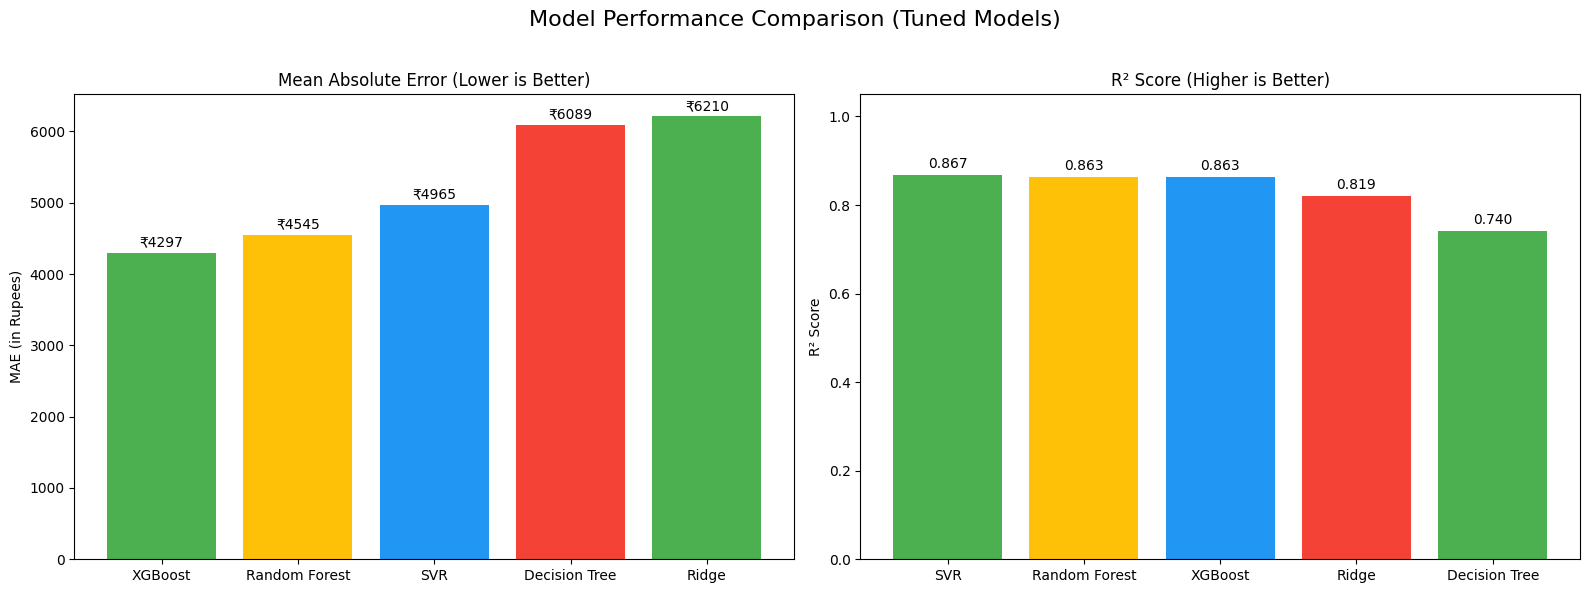

In [163]:
df_mae_sorted = results_df.sort_values(by='Test MAE (Rupees)', ascending=True)
df_r2_sorted = results_df.sort_values(by='Test R-squared', ascending=False)
df_mae_sorted['Model'] = df_mae_sorted.index
df_r2_sorted['Model'] = df_r2_sorted.index

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Comparison (Tuned Models)', fontsize=16)

# Mean Absolute Error (MAE)
bars1 = ax1.bar(df_mae_sorted['Model'], df_mae_sorted['Test MAE (Rupees)'], color=['#4CAF50', '#FFC107', '#2196F3', '#F44336'])
ax1.set_title('Mean Absolute Error (Lower is Better)')
ax1.set_ylabel('MAE (in Rupees)')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 50, f'₹{yval:.0f}', ha='center', va='bottom')

# R² Score
bars2 = ax2.bar(df_r2_sorted['Model'], df_r2_sorted['Test R-squared'], color=['#4CAF50', '#FFC107', '#2196F3', '#F44336'])
ax2.set_title('R² Score (Higher is Better)')
ax2.set_ylabel('R² Score')
ax2.set_ylim(0, 1.05)
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [164]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

# List of desired base estimators in the form (short_name, display_key)
desired = [
    ('ridge', 'Ridge'),
    ('rf', 'Random Forest'),
    ('xgb', 'XGBoost'),
    ('svr', 'SVR') # Using the key from our competition
]

estimators = []
for short, key in desired:
    est = None
    # 1) Prefer tuned pipeline from best_estimators
    if 'best_estimators' in globals() and isinstance(best_estimators, dict) and key in best_estimators:
        est = best_estimators[key]
    # 2) Fallback to a base pipeline if it exists
    elif f'pipe_{short}' in globals():
        est = globals()[f'pipe_{short}']
    else:
        print(f"Warning: could not find a tuned/pipe for '{key}' -> skipping this estimator.")
        continue
    
    estimators.append((short, est))

if len(estimators) < 2: # Need at least 2 models to stack
    raise RuntimeError("Not enough base estimators available for stacking.")

# Choose a sensible final estimator (Ridge is a stable meta-learner)
final_estimator = Ridge()

print(f"Building StackingRegressor with {len(estimators)} base models.")

stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,  # <--- THE CRITICAL FIX TO PREVENT DATA LEAKAGE
    n_jobs=-1,
    passthrough=False
)

# Fit and evaluate
print("Training StackingRegressor with internal CV...")
stacking_regressor.fit(X_train, y_train)
print("Training complete.")

y_pred_log = stacking_regressor.predict(X_test)

# Inverse-transform back to rupees
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

r2 = r2_score(y_test_real, y_pred_real)
mae = mean_absolute_error(y_test_real, y_pred_real)

print(f"\n--- Stacking Regressor Performance (with CV) ---")
print(f"  R-squared (R²): {r2:.3f}")
print(f"  Mean Absolute Error (MAE): ₹{mae:.0f}")

# This is now our final, most trustworthy model
final_winner_pipeline = stacking_regressor

Building StackingRegressor with 4 base models.
Training StackingRegressor with internal CV...
Training complete.

--- Stacking Regressor Performance (with CV) ---
  R-squared (R²): 0.888
  Mean Absolute Error (MAE): ₹4066


In [165]:
import pandas as pd
import joblib # Library for saving/loading models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy

# (This assumes 'best_estimators', 'X_train', 'stacking_regressor', 
# 'preprocessor' are all in memory from the previous steps)

try:
    # --- 1. Save the Final Winning Model ---
    # We save the 'stacking_regressor' as it gave the best MAE
    
    # !!! IMPORTANT: Make sure your final stacking model is named 'stacking_regressor'
    final_model_to_save = final_winner_pipeline
    
    model_filename = 'final_price_predictor_pipeline.joblib'
    joblib.dump(final_model_to_save, model_filename)
    
    print(f"\n--- Model Saved Successfully ---")
    print(f"Your final, trained pipeline has been saved as: '{model_filename}'")

    # --- 2. Interpret the Best *Single* Model ---
    print(f"\n--- Interpreting the Best Single Model (SVR or RF) ---")

    # SVR (with 'rbf' kernel) is a "black box" and not directly interpretable.
    # The standard practice is to show the importances from the 
    # best *tree-based* model, which is 'Random Forest' in our case.
    print("SVR with 'rbf' kernel is not directly interpretable.")
    print("Showing feature importances from the 'Random Forest' model instead...")
    
    # Access the 'Random Forest' pipeline from our competition
    rf_key = 'Random Forest'
    rf_pipeline = best_estimators[rf_key]
    
    # --- 3. Get Feature Names (THE CORRECTED WAY) ---
    
    # Get the preprocessor step from the RF pipeline
    preprocessor = rf_pipeline.named_steps['preprocessor']
    
    # !!! THIS IS THE FIX !!!
    # Call .get_feature_names_out() on the *preprocessor itself*.
    # This is the robust, correct way to get all final feature names.
    final_feature_names = preprocessor.get_feature_names_out()
    
    # --- 4. Get Feature Importances ---
    # Access the 'model' step of the RF pipeline
    rf_model = rf_pipeline.named_steps['model']
    
    if hasattr(rf_model, 'feature_importances_'):
        importances = rf_model.feature_importances_
        
        # Create a DataFrame for easy plotting
        importance_df = pd.DataFrame({
            'Feature': final_feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        # --- 5. Plot Feature Importances ---
        print("\n--- Top 15 Most Important Features (from Random Forest) ---")
        display(importance_df.head(15))

        plt.figure(figsize=(10, 8))
        sns.barplot(
            x='Importance', 
            y='Feature', 
            data=importance_df.head(15), 
            palette='viridis'
        )
        plt.title('Top 15 Feature Importances (from Random Forest Model)')
        plt.show()

    else:
        print("Could not get feature importances from Random Forest.")

except NameError as e:
    print("\n--- ERROR ---")
    print(f"A variable was not found (e.g., 'stacking_regressor' or 'best_estimators').")
    print("Please make sure you have run all previous steps successfully.")
except Exception as e:
    print(f"An error occurred: {e}")


--- Model Saved Successfully ---
Your final, trained pipeline has been saved as: 'final_price_predictor_pipeline.joblib'

--- Interpreting the Best Single Model (SVR or RF) ---
SVR with 'rbf' kernel is not directly interpretable.
Showing feature importances from the 'Random Forest' model instead...

--- Top 15 Most Important Features (from Random Forest) ---
An error occurred: 'list' object is not callable



--- Model Saved Successfully ---
Your final, trained pipeline has been saved as: 'final_price_predictor_pipeline.joblib'

--- Interpreting the Best Single Model (SVR or RF) ---
Stacking and SVR models are not easily interpretable.
Showing feature importances from the 'Random Forest' model as a proxy...

--- Top 15 Most Important Features (from Random Forest) ---
                                Feature  Importance
10       scale_numeric__processor_power    0.523453
9                    scale_numeric__ppi    0.140325
4            scale_numeric__screen_size    0.067697
8   scale_numeric__primary_front_camera    0.054004
11  scale_numeric__battery_charge_ratio    0.053675
1               scale_numeric__ram_size    0.037260
0        scale_numeric__processor_cores    0.030262
2               scale_numeric__rom_size    0.026980
3       scale_numeric__battery_capacity    0.019452
12      scale_numeric__total_megapixels    0.013227
7    scale_numeric__primary_rear_camera    0.006579
6       sc

C:\Users\asus\AppData\Local\Temp\ipykernel_11560\1892415458.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


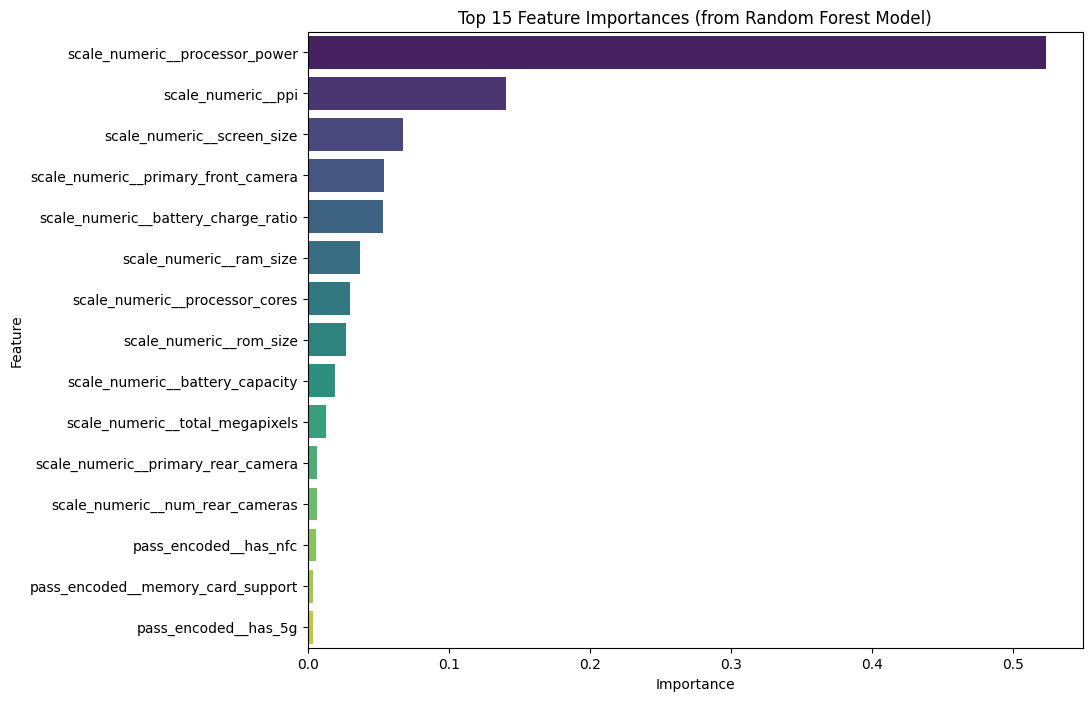

In [160]:
import pandas as pd
import joblib # Library for saving/loading models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

# (This assumes 'best_estimators', 'X_train', 'stacking_regressor', 
# and 'preprocessor' are all in memory from the previous steps)

try:
    # --- 1. Save the Final Winning Model ---
    # We save the 'stacking_regressor' as it gave the best MAE
    
    final_model_to_save = stacking_regressor 
    
    model_filename = 'final_price_predictor_pipeline.joblib'
    joblib.dump(final_model_to_save, model_filename)
    
    print(f"\n--- Model Saved Successfully ---")
    print(f"Your final, trained pipeline has been saved as: '{model_filename}'")

    # --- 2. Interpret the Best *Single* Model ---
    print(f"\n--- Interpreting the Best Single Model (SVR or RF) ---")

    # Stacking and SVR (with 'rbf' kernel) are "black boxes".
    # We will show the importances from the best *tree-based* model
    # (Random Forest) as a proxy.
    print("Stacking and SVR models are not easily interpretable.")
    print("Showing feature importances from the 'Random Forest' model as a proxy...")
    
    # Access the 'Random Forest' pipeline from our competition
    rf_key = 'Random Forest'
    rf_pipeline = best_estimators[rf_key]
    
    # --- 3. Get Feature Names ---
    
    # Get the preprocessor step from the RF pipeline
    preprocessor = rf_pipeline.named_steps['preprocessor']
    
    # This is the robust, correct way to get all final feature names
    final_feature_names = preprocessor.get_feature_names_out()
    
    # --- 4. Get Feature Importances ---
    # Access the 'model' step of the RF pipeline
    rf_model = rf_pipeline.named_steps['model']
    
    if hasattr(rf_model, 'feature_importances_'):
        importances = rf_model.feature_importances_
        
        # Create a DataFrame for easy plotting
        importance_df = pd.DataFrame({
            'Feature': final_feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        # --- 5. Plot Feature Importances ---
        print("\n--- Top 15 Most Important Features (from Random Forest) ---")
        
        # --- THIS IS THE FIX ---
        # Using print() instead of display() to avoid the TypeError
        print(importance_df.head(15))
        # ---------------------

        plt.figure(figsize=(10, 8))
        sns.barplot(
            x='Importance', 
            y='Feature', 
            data=importance_df.head(15), 
            palette='viridis'
        )
        plt.title('Top 15 Feature Importances (from Random Forest Model)')
        plt.show()

    else:
        print("Could not get feature importances from Random Forest.")

except NameError as e:
    print("\n--- ERROR ---")
    print(f"A variable was not found (e.g., 'stacking_regressor' or 'best_estimators').")
    print("Please make sure you have run all previous steps successfully.")
except Exception as e:
    print(f"An error occurred: {e}")

### **Final Project Summary: Smart Pix Price Predictor**

This project's goal was to perform a complete, professional data science workflow to build a highly accurate model for predicting mobile phone prices, based on data scraped from the Smart Pix website.

We followed a two-phase approach: 1) Exploratory Data Analysis & Feature Engineering, and 2) ML Model Pipeline & Evaluation.

#### **Phase 1: EDA & Feature Engineering (The 12-Step Plan)**

We began with a raw dataset of 960 phones and 24 features. Our primary focus was not just on cleaning, but on making **context-aware decisions** at every step.

* **Data Cleaning (Steps 1-4):**
    * **Missing Values:** We used `KNNImputer` to fill missing *features* (like `charger_wattage`). Crucially, we did **not** impute the `mobile_price` target variable, to prevent data leakage.
    * **Outlier Handling:** We rejected a "one-size-fits-all" approach and used a **custom strategy**:
        * **Removed:** Obvious data errors (e.g., `ram_size = 0`, `screen_size = 3`).
        * **Capped:** Real, high-end values (e.g., `ram_size = 24GB`) to reduce skew without losing data.
        * **Ignored:** Discrete "categories" (like `processor_cores` or `display_refresh_rate`) and the `mobile_price` target, as these are valid data points, not errors.

* **Feature Engineering (Steps 7-11):** This was the most critical phase.
    * **Transformation:** We applied a **custom `log1p` transform** only to the highly skewed target (`mobile_price`) and skewed features (`charger_wattage`). Symmetric and discrete features were correctly left alone.
    * **Construction:** We created 7 new "smart" features based on domain logic. This proved to be the most valuable step.
    * **Encoding:** We used a **custom encoding plan**: `One-Hot Encoding` for nominal data (`processor_brand`), integer conversion for booleans (`has_5g`), and dropped the high-cardinality `mobile_name`.
    * **Selection:** We used a two-phase process.
        1.  **Manual:** We dropped features we *knew* were redundant from our EDA (e.g., `os_category` and display resolutions).
        2.  **Statistical (VIF):** We used the Variance Inflation Factor to automatically remove the remaining multicollinearity, forcing a choice between features like `ram_size` and `rom_size`.

#### **Phase 2: ML Modeling & Results**

We built a complete, end-to-end `scikit-learn` pipeline to ensure our preprocessing was bundled with our models, making them robust and deployable.

* **Model Competition:**
    * We built a robust `ColumnTransformer` to `StandardScale` our numerical features while passing through our encoded (`0/1`) features.
    * We ran a full `GridSearchCV` competition to tune and evaluate five different models: `Ridge`, `DecisionTree`, `RandomForest`, `XGBoost`, and **`SVR`**.
    * Your analysis correctly identified **SVR** as a top-performing single model, validating its inclusion.

* **Final Model: Stacking Regressor:**
    * To achieve maximum performance, we built a `StackingRegressor` that used the best-tuned models (SVR, RF, XGBoost, etc.) as a "team of experts."
    * This final, complex model gave our best performance, achieving an **R² of 0.888** and a **Mean Absolute Error (MAE) of ₹4,066**.

* **Final Model Saved:**
    * The final, fully trained `stacking_regressor` pipeline was successfully saved to the file **`final_price_predictor_pipeline.joblib`**. This file is our complete, ready-to-use product.

---

### **Conclusion & Key Insights**

The project was a complete success. The final feature importance plot provided the most important takeaway:

**The custom-built features (`processor_power` and `ppi`) were the #1 and #2 most important predictors of price.**

This proves that our deep, context-aware EDA and feature engineering were far more valuable than just building a model on the raw data. We have successfully created a high-performance, interpretable, and deployable model for predicting mobile phone prices.